In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Maritime TSP — QAOA-Assisted Routing (Multi-Scale Study)
=======================================================

Research code accompanying the paper:
  "Quantum Coverage and Solution Quality in QAOA-Assisted Greedy
   Maritime Routing: A Dual-Scale Empirical Study"

Authors: Aditya Singh, Rajiv Pandey, Pooja Srivastava

Description:
    This project implements a hybrid quantum-classical framework for solving 
    The Maritime Travelling Salesman Problem using real sea-route distances.

    We use QAOA (with XY mixer) selectively within a greedy construction 
    pipeline to study the relationship between **quantum influence coverage** 
    and solution quality under realistic NISQ constraints.

Core Focus:
    • Full quantum coverage (8 & 12 ports)
    • Partial quantum coverage (16 & 20 ports with max 8 qubits)
    • Empirical analysis of "more quantum = better?" hypothesis

Figures:
    (Important- not all figures are used from this main cell due to labelling issues and additional data, 
    but they are regenerated using real values and a saved JSON file)
    
    - route_map_12port.png (used from the current cell main run)
    - ablation_12port.png (used from the current cell main run)
    - p_layer_study_8port (figure used in the paper from the third last cell titled: P-LAYER STUDY)
    - coverage_quality_curve.png (used in the paper from last cell run with added 30ports and 20qubit side study 
      from notebook maritime_30port_20qubit_side_study)
    - noise_12port.png (used in the paper with fixed labels from the next cell figure regeneration run)
    - all_regimes_boxplot.png (used in the paper with fixed labels from the next cell figure re-generation run)
    - ablation_12port.png (used in the paper with fixed labels from the last cell run) 

Core Contribution:
    We show that higher quantum influence coverage often leads to 
    degraded solution quality in current hybrid settings — highlighting 
    the importance of selective quantum participation.

Usage:
    python maritime_tsp_multiscale.py --preset FAST          # Quick test
    python maritime_tsp_multiscale.py --preset QUALITY       # Research results
    python maritime_tsp_multiscale.py --preset QUALITY --skip_20port

Requirements:
    pennylane, pennylane-lightning, searoute, numpy, matplotlib, scipy, tqdm
    LKH-3 solver (optional but recommended)
"""

import argparse
import gc
import os
import platform
import random
import subprocess
import sys
import tempfile
import time
import warnings
import json
from datetime import datetime
from tqdm import tqdm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pennylane as qml
from pennylane import numpy as pnp
from pennylane.optimize import NesterovMomentumOptimizer
from scipy import stats
import searoute as sr
import pickle


# =============================================================================
# DISTANCE CACHE
# =============================================================================

CACHE_FILE = "distance_cache.pkl"
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, "rb") as _f:
        DIST_CACHE = pickle.load(_f)
else:
    DIST_CACHE = {}

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["DejaVu Serif"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "figure.dpi":        150,
})

# =============================================================================
# EXPERIMENT PRESETS
# =============================================================================

PRESET = "QUALITY"   # Change to 'FAST', 'QUALITY', or 'FINAL'

PRESETS = {
    "FAST": {
        "description":   "Quick testing — reduced steps for development",
        "skip_20port":   True,
        "n_seeds":       2,
        "steps_main":    50,
        "steps_ablation":30,
        "steps_noise":   30,
        "steps_qcap":    30,
        "skip_noise":    True,
    },
    "QUALITY": {
        "description":   "Quality mode — balanced for research results",
        "skip_20port":   False,
        "n_seeds":       8,
        "steps_main":    150,
        "steps_ablation":100,
        "steps_noise":   100,
        "steps_qcap":    60,
        "skip_noise":    False,
    },
    "FINAL": {
        "description":   "Final mode — full experiments for publication",
        "skip_20port":   False,
        "n_seeds":       16,
        "steps_main":    300,
        "steps_ablation":150,
        "steps_noise":   150,
        "steps_qcap":    80,
        "skip_noise":    False,
    },
}

print(f"\n{'='*60}")
print(f"  PRESET MODE: {PRESET}")
print(f"  {PRESETS[PRESET]['description']}")
print(f"{'='*60}\n")


# =============================================================================
# PORT DATA — FOUR REGIMES
# =============================================================================

# --- 8-port regime (full quantum coverage — ideal NISQ case) ---
PORTS_8 = {
    "Mumbai":      (18.94,  72.83),
    "Kochi":       ( 9.96,  76.27),
    "Colombo":     ( 6.95,  79.85),
    "Singapore":   ( 1.30, 103.77),
    "Port Klang":  ( 3.00, 101.40),
    "Jebel Ali":   (25.00,  55.05),
    "Shanghai":    (31.23, 121.47),
    "Rotterdam":   (51.92,   4.48),
}
assert len(PORTS_8) == 8,  f"PORTS_8 has {len(PORTS_8)} entries — expected 8"

# --- 12-port regime (full quantum coverage) ---
PORTS_12 = {
    "Mumbai":       (18.94,  72.83),
    "Kochi":        ( 9.96,  76.27),
    "Tuticorin":    ( 8.77,  78.13),
    "Colombo":      ( 6.95,  79.85),
    "Singapore":    ( 1.30, 103.77),
    "Port Klang":   ( 3.00, 101.40),
    "Shanghai":     (31.23, 121.47),
    "Busan":        (35.10, 129.04),
    "Yokohama":     (35.44, 139.64),
    "Port Hedland": (-20.31, 118.57),
    "Jebel Ali":    (25.00,  55.05),
    "Rotterdam":    (51.92,   4.48),
}
assert len(PORTS_12) == 12, f"PORTS_12 has {len(PORTS_12)} entries — expected 12"

# --- 16-port regime (~53% quantum coverage with MAX_QUBITS=8) ---
PORTS_16 = {
    # Indian subcontinent
    "Mumbai":       (18.94,  72.83),
    "Kochi":        ( 9.96,  76.27),
    "Colombo":      ( 6.95,  79.85),
    "Karachi":      (24.86,  67.01),
    # Southeast Asia
    "Singapore":    ( 1.30, 103.77),
    "Port Klang":   ( 3.00, 101.40),
    "Jakarta":      (-6.21, 106.85),
    "Bangkok":      (13.76, 100.50),
    # East Asia
    "Shanghai":     (31.23, 121.47),
    "Busan":        (35.10, 129.04),
    "Yokohama":     (35.44, 139.64),
    "Hong Kong":    (22.32, 114.17),
    # Middle East & Europe
    "Jebel Ali":    (25.00,  55.05),
    "Rotterdam":    (51.92,   4.48),
    "Hamburg":      (53.55,   9.99),
    # Australia
    "Port Hedland": (-20.31, 118.57),
}
assert len(PORTS_16) == 16, f"PORTS_16 has {len(PORTS_16)} entries — expected 16"

# --- 20-port regime (partial quantum coverage) ---
PORTS_20 = {
    "Mumbai":        (18.94,  72.83),
    "Chennai":       (13.08,  80.28),
    "Kolkata":       (22.56,  88.34),
    "Kochi":         ( 9.96,  76.27),
    "Visakhapatnam": (17.70,  83.30),
    "Goa":           (15.40,  73.81),
    "Tuticorin":     ( 8.77,  78.13),
    "Singapore":     ( 1.30, 103.77),
    "Colombo":       ( 6.95,  79.85),
    "Jebel Ali":     (25.00,  55.05),
    "Port Klang":    ( 3.00, 101.40),
    "Shanghai":      (31.23, 121.47),
    "Busan":         (35.10, 129.04),
    "Rotterdam":     (51.92,   4.48),
    "Fujairah":      (25.12,  56.34),
    "Port Hedland":  (-20.31, 118.57),
    "Yokohama":      (35.44, 139.64),
    "Durban":        (-29.85,  31.03),
    "Sydney":        (-33.87, 151.21),
    "Hamburg":       (53.55,    9.99),
}
assert len(PORTS_20) == 20, f"PORTS_20 has {len(PORTS_20)} entries — expected 20"

# LKH-3 executable path — cross-platform
if platform.system() == "Windows":
    LKH_EXE = r".\LKH-3.exe"
else:
    LKH_EXE = "./LKH-3"


# =============================================================================
# DISTANCE MATRIX
# =============================================================================

def maritime_distance(lat1, lon1, lat2, lon2):
    """Return navigable sea-route distance in km, with persistent cache."""
    point1 = (round(lat1, 4), round(lon1, 4))
    point2 = (round(lat2, 4), round(lon2, 4))
    key = tuple(sorted([point1, point2]))

    if key in DIST_CACHE:
        return DIST_CACHE[key]
    if abs(lat1 - lat2) < 1e-6 and abs(lon1 - lon2) < 1e-6:
        return 0.0
    try:
        route = sr.searoute((lon1, lat1), (lon2, lat2))
        dist  = route["properties"]["length"]
    except Exception:
        dist  = 999_999.0
    DIST_CACHE[key] = dist
    return dist


def build_distance_matrix(ports_dict):
    """Build and return the full N×N distance matrix for a port set."""
    port_list = list(ports_dict.keys())
    n = len(port_list)
    D = np.zeros((n, n))
    print(f"  Computing {n}×{n} distance matrix ({n*(n-1)//2} unique pairs)...")
    for i in range(n):
        for j in range(i + 1, n):
            lat1, lon1 = ports_dict[port_list[i]]
            lat2, lon2 = ports_dict[port_list[j]]
            d = maritime_distance(lat1, lon1, lat2, lon2)
            D[i, j] = d
            D[j, i] = d
        if (i + 1) % 4 == 0:
            print(f"    Row {i+1}/{n} done", flush=True)
    return D, port_list


# =============================================================================
# ROUTE UTILITIES
# =============================================================================

def route_cost(route, D):
    total  = sum(D[route[i], route[i+1]] for i in range(len(route) - 1))
    total += D[route[-1], route[0]]
    return total


# =============================================================================
# CLASSICAL BASELINES
# =============================================================================

def nearest_neighbor_tour(start_idx, D, n):
    unvisited = set(range(n))
    unvisited.remove(start_idx)
    tour, current = [start_idx], start_idx
    while unvisited:
        nxt = min(unvisited, key=lambda x: D[current, x])
        tour.append(nxt)
        unvisited.remove(nxt)
        current = nxt
    return tour, route_cost(tour, D)


def two_opt(route, D):
    """Standard 2-opt local search."""
    n    = len(route)
    best = route[:]
    best_cost = route_cost(best, D)
    improved  = True
    while improved:
        improved = False
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                new_route = best[:i] + best[i:j+1][::-1] + best[j+1:]
                new_cost  = route_cost(new_route, D)
                if new_cost < best_cost - 1e-6:
                    best      = new_route
                    best_cost = new_cost
                    improved  = True
    return best, best_cost


def hill_climbing_2opt(D, n, n_restarts=3, seed=42):
    """Hill climbing with 2-opt neighbourhood."""
    rng = random.Random(seed)
    best_route, best_cost = None, float("inf")
    for _ in range(n_restarts):
        init = list(range(n))
        rng.shuffle(init)
        route, cost = two_opt(init, D)
        if cost < best_cost:
            best_cost  = cost
            best_route = route[:]
    return best_route, best_cost


# =============================================================================
# LKH-3 INTEGRATION
# =============================================================================

def save_tsplib(D, port_list, filename):
    n = len(port_list)
    with open(filename, "w") as f:
        f.write(f"NAME : MaritimeTSP\nCOMMENT : {n} ports\nTYPE : TSP\n")
        f.write(f"DIMENSION : {n}\nEDGE_WEIGHT_TYPE : EXPLICIT\n")
        f.write("EDGE_WEIGHT_FORMAT : FULL_MATRIX\nEDGE_WEIGHT_SECTION\n")
        for i in range(n):
            f.write(" ".join(str(int(round(D[i, j]))) for j in range(n)) + "\n")
        f.write("EOF\n")


def run_lkh(D, port_list, max_trials=100):
    if not os.path.exists(LKH_EXE):
        print("  LKH-3 not found — skipping.")
        return None, float("inf")
    with tempfile.TemporaryDirectory() as tmp:
        prob = os.path.join(tmp, "p.tsp")
        par  = os.path.join(tmp, "p.par")
        tour = os.path.join(tmp, "p.tour")
        out  = os.path.join(tmp, "lkh.out")
        save_tsplib(D, port_list, prob)
        with open(par, "w") as f:
            f.write(f"PROBLEM_FILE = {prob}\nOUTPUT_TOUR_FILE = {tour}\n")
            f.write(f"RUNS = {max_trials}\nTRACE_LEVEL = 1\nMOVE_TYPE = 5\n")
        try:
            subprocess.run([LKH_EXE, par],
                           stdout=open(out, "w"),
                           stderr=subprocess.STDOUT,
                           check=True, timeout=300, shell=False)
        except Exception as e:
            print(f"  LKH error: {e}")
            return None, float("inf")
        result  = []
        reading = False
        try:
            with open(tour) as f:
                for line in f:
                    line = line.strip()
                    if line == "TOUR_SECTION":
                        reading = True; continue
                    if reading:
                        if line in ("-1", "EOF"): break
                        try:
                            idx = int(line) - 1
                            if 0 <= idx < len(port_list):
                                result.append(idx)
                        except ValueError:
                            pass
        except FileNotFoundError:
            return None, float("inf")
        if len(result) != len(port_list):
            return None, float("inf")
        return result, route_cost(result, D)


# =============================================================================
# CANDIDATE SELECTION
# =============================================================================

def select_k_candidates(candidates, probabilities, k=3):
    """
    Select next port via top-k roulette: keep only the k highest-probability
    valid one-hot states then sample proportionally.
    """
    n = len(candidates)
    if n <= k:
        probs = np.array(probabilities[:n], dtype=float)
        if probs.sum() > 0:
            probs /= probs.sum()
        else:
            probs = np.ones(n) / n
        return candidates[int(np.random.choice(n, p=probs))]

    top_idx   = np.argsort(probabilities)[-k:][::-1]
    top_cands = [candidates[i] for i in top_idx]
    top_probs = np.array([probabilities[i] for i in top_idx], dtype=float)
    if top_probs.sum() > 0:
        top_probs /= top_probs.sum()
    else:
        top_probs = np.ones(k) / k
    chosen = int(np.random.choice(k, p=top_probs))
    return top_cands[chosen]


# =============================================================================
# QAOA-ASSISTED GREEDY CORE
# =============================================================================

def build_qaoa_greedy_tour(
    start_idx, D, port_list, max_qubits=8,
    layers=3, steps=300, alpha=0.5,
    noise_level=None, verbose=True, track_decisions=False
):
    """
    Construct a TSP tour using QAOA-assisted greedy decisions.

    Parameters
    ----------
    start_idx       : int   — starting port index
    D               : ndarray — N×N distance matrix (km)
    port_list       : list[str] — port names
    max_qubits      : int   — qubit budget; larger candidate sets fall back to NN
    layers          : int   — QAOA circuit depth p  (capped at 8 for noise study)
    steps           : int   — max optimisation steps per greedy decision
    alpha           : float — look-ahead weight  α ∈ [0, 1]
    noise_level     : float|None — depolarising noise p; None = noiseless
    verbose         : bool  — print decision trace
    track_decisions : bool  — record per-step metadata in decision_history

    Returns
    -------
    tour_names        : list[str]
    total_cost        : float
    path_indices      : list[int]
    quantum_decisions : int
    classical_decisions : int
    decision_history  : list[dict]  (empty list when track_decisions=False)
    """
    layers = min(layers, 8)   # density-matrix memory guard

    n         = len(port_list)
    unvisited = set(range(n))
    unvisited.remove(start_idx)
    tour    = [start_idx]
    current = start_idx
    quantum_decisions   = 0
    classical_decisions = 0
    decision_history    = []

    if verbose:
        mode = f"noisy p={noise_level}" if noise_level else "noiseless"
        print(f"  Start: {port_list[start_idx]} | layers={layers} "
              f"| max_qubits={max_qubits} | {mode}")

    step_num = 0
    while unvisited:
        step_num += 1
        k   = len(unvisited)
        rem = list(unvisited)

        # ── Classical fallback ────────────────────────────────────────────
        if k > max_qubits:
            nxt = min(unvisited, key=lambda x: D[current, x])
            if verbose:
                print(f"    [{k:2d} left] classical NN → {port_list[nxt]}")
            tour.append(nxt)
            unvisited.remove(nxt)
            current = nxt
            classical_decisions += 1
            if track_decisions:
                decision_history.append({
                    "step":             step_num,
                    "remaining_ports":  k,
                    "decision_type":    "classical",
                    "selected_port":    port_list[nxt],
                    "quantum_probability": None,
                    "num_candidates":   k,
                })
            continue

        # ── Effective cost function ───────────────────────────────────────
        start_port = tour[0]
        eff_costs  = []
        for j in rem:
            future = (min(D[j, x] for x in unvisited if x != j)
                      if len(unvisited) > 1 else 0.0)
            eff_costs.append(
                D[current, j]
                + alpha * future
                + 0.2 * D[j, start_port]   # δ = 0.2 return pressure
            )
        penalty = np.mean(eff_costs) * 2

        # ── Cost Hamiltonian ──────────────────────────────────────────────
        coeffs, ops = [], []
        scale = max(eff_costs) + 1e-6
        for i, d in enumerate(eff_costs):
            d_norm  = d / scale
            coeffs += [d_norm / 2, -d_norm / 2]
            ops    += [qml.Identity(i), qml.PauliZ(i)]
        for i in range(k):
            for j in range(i + 1, k):
                coeffs.append(penalty / 4)
                ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
        H_cost = qml.Hamiltonian(coeffs, ops)

        # ── XY Mixer Hamiltonian ──────────────────────────────────────────
        mx_c, mx_o = [], []
        for i in range(k):
            for j in range(i + 1, k):
                mx_c += [1.0, 1.0]
                mx_o += [qml.PauliX(i) @ qml.PauliX(j),
                         qml.PauliY(i) @ qml.PauliY(j)]
        H_mix = qml.Hamiltonian(mx_c, mx_o)

        # ── Device selection ──────────────────────────────────────────────
        if noise_level is not None:
            dev = qml.device("default.mixed",   wires=k)
        else:
            dev = qml.device("lightning.qubit", wires=k)

        # ── Energy QNode ──────────────────────────────────────────────────
        @qml.qnode(dev)
        def energy_circuit(g, b):
            for i in range(k):
                qml.Hadamard(i)
            for gg, bb in zip(g, b):
                qml.qaoa.cost_layer(gg, H_cost)
                qml.qaoa.mixer_layer(bb, H_mix)
            if noise_level is not None:
                for w in range(k):
                    qml.DepolarizingChannel(noise_level, wires=w)
            return qml.expval(H_cost)

        # ── Probability QNode ─────────────────────────────────────────────
        @qml.qnode(dev)
        def prob_circuit(g, b):
            for i in range(k):
                qml.Hadamard(i)
            for gg, bb in zip(g, b):
                qml.qaoa.cost_layer(gg, H_cost)
                qml.qaoa.mixer_layer(bb, H_mix)
            if noise_level is not None:
                for w in range(k):
                    qml.DepolarizingChannel(noise_level, wires=w)
            return qml.probs(wires=range(k))

        # ── Variational optimisation ──────────────────────────────────────
        g = pnp.random.uniform(0.05, 0.20, layers, requires_grad=True)
        b = pnp.random.uniform(1.00, 1.50, layers, requires_grad=True)
        opt = NesterovMomentumOptimizer(0.03)
        prev_e, stable = float("inf"), 0

        if verbose:
            print(f"    [{k:2d} left] QAOA optimising... ", end="", flush=True)

        for step in range(steps):
            g, b   = opt.step(energy_circuit, g, b)
            energy = float(energy_circuit(g, b))
            if abs(energy - prev_e) < 1e-2:
                stable += 1
                if stable > 20:
                    if verbose:
                        print(f"early stop @{step}", end=" ", flush=True)
                    break
            else:
                stable = 0
            prev_e = energy

        if verbose:
            print("done", flush=True)

        # ── Sample from probability distribution ──────────────────────────
        probs = prob_circuit(g, b)

        valid_states, weights = [], []
        for s in range(2 ** k):
            bs = format(s, f"0{k}b")
            if bs.count("1") == 1:
                valid_states.append(bs)
                weights.append(float(probs[s]))

        max_prob = max(weights) if weights else 0.0

        if sum(weights) > 0:
            candidate_weights = [weights[idx] for idx, _ in enumerate(valid_states)]
            nxt = select_k_candidates(rem, candidate_weights, k=min(3, len(rem)))
            if verbose:
                print(f"    → {port_list[nxt]} "
                      f"(top-k selection, max prob={max_prob:.4f})")
        else:
            nxt = min(unvisited, key=lambda x: D[current, x])
            if verbose:
                print(f"    → {port_list[nxt]} (fallback — uniform dist)")

        tour.append(nxt)
        unvisited.remove(nxt)
        current = nxt
        quantum_decisions += 1

        if track_decisions:
            decision_history.append({
                "step":                step_num,
                "remaining_ports":     k,
                "decision_type":       "quantum",
                "selected_port":       port_list[nxt],
                "quantum_probability": max_prob,
                "num_candidates":      len(rem),
            })

        if quantum_decisions % 5 == 0:
            gc.collect()

    tour.append(start_idx)
    total_cost = route_cost(tour[:-1], D)
    tour_names = [port_list[i] for i in tour]
    path_idx   = tour[:-1]
    return tour_names, total_cost, path_idx, quantum_decisions, classical_decisions, decision_history


# =============================================================================
# EXPERIMENT RUNNERS
# =============================================================================

def run_classical_baselines(D, port_list, lkh_trials=100):
    n = len(port_list)
    print("\n  [1/3] Nearest Neighbour...")
    nn_tour, nn_cost = nearest_neighbor_tour(0, D, n)
    print("  [2/3] Hill Climbing (2-opt, 3 restarts)...")
    hc_tour, hc_cost = hill_climbing_2opt(D, n, n_restarts=3, seed=42)
    print("  [3/3] LKH-3...")
    lkh_tour, lkh_cost = run_lkh(D, port_list, max_trials=lkh_trials)
    return {
        "nn":  {"tour": nn_tour,  "cost": nn_cost},
        "hc":  {"tour": hc_tour,  "cost": hc_cost},
        "lkh": {"tour": lkh_tour, "cost": lkh_cost},
    }


def run_ablation(D, port_list, max_qubits, start_idx=0,
                 layer_range=(1, 2, 3, 4),
                 alpha_range=(0.0, 0.3, 0.5, 0.7),
                 steps=150, seed=42):
    results = {}
    total   = len(layer_range) * len(alpha_range)
    done    = 0
    for l in layer_range:
        for a in alpha_range:
            done += 1
            print(f"  Ablation [{done}/{total}] layers={l}, alpha={a:.1f}")
            random.seed(seed); np.random.seed(seed)
            _, cost, _, qd, cd, _ = build_qaoa_greedy_tour(
                start_idx, D, port_list,
                max_qubits=max_qubits, layers=l,
                steps=steps, alpha=a, verbose=False
            )
            results[(l, a)] = cost
            q_pct = 100 * qd / (qd + cd) if (qd + cd) > 0 else 0
            print(f"    cost={cost:,.0f} km | Q-influence={q_pct:.1f}%")
            gc.collect()
    return results


def run_statistical_evaluation(D, port_list, max_qubits, start_idx=0,
                                layers=3, steps=300, alpha=0.5,
                                n_seeds=8, base_seed=42):
    """
    Run QAOA-greedy across multiple random seeds.
    Always returns 4-tuples: (seed, cost, q_decisions, c_decisions).
    Decision history is NOT tracked here to avoid tuple-length ambiguity.
    """
    rng   = np.random.default_rng(base_seed)
    seeds = rng.integers(0, 1_000_000, size=n_seeds)
    records = []
    for seed in seeds:
        random.seed(int(seed)); np.random.seed(int(seed))
        _, cost, _, qd, cd, _ = build_qaoa_greedy_tour(
            start_idx, D, port_list,
            max_qubits=max_qubits,
            layers=layers, steps=steps, alpha=alpha,
            verbose=False, track_decisions=False,
        )
        records.append((int(seed), cost, qd, cd))
        print(f"    cost={cost:,.0f} km | Q={qd} | C={cd}")
        gc.collect()
    return records


def run_noise_sensitivity(D, port_list, max_qubits,
                          start_idx=0, layers=2, steps=100, alpha=0.5,
                          noise_levels=(0.001, 0.005, 0.01, 0.02, 0.05),
                          n_seeds=4, base_seed=42):
    """
    Noise sensitivity with realistic shallow circuits.
    """
    noise_layers = min(layers, 2)
    noise_qubits = min(max_qubits, 6)
    
    seeds = [base_seed + i * 13 for i in range(n_seeds)]
    results = []
    
    print(f"  Noise sensitivity: MAX_QUBITS={noise_qubits}, layers={noise_layers}")
    
    for nl in noise_levels:
        costs = []
        print(f"  Noise level p={nl:.3f} ...")
        for seed in tqdm(seeds, desc=f"    p={nl:.3f}"):
            random.seed(seed)
            np.random.seed(seed)
            _, cost, _, _, _, _ = build_qaoa_greedy_tour(
                start_idx, D, port_list,
                max_qubits=noise_qubits, 
                layers=noise_layers,
                steps=steps, 
                alpha=alpha,
                noise_level=nl, 
                verbose=False
            )
            costs.append(cost)
            gc.collect()
        
        results.append((nl, np.mean(costs), np.std(costs)))
        print(f"      mean={np.mean(costs):,.0f} ± {np.std(costs):,.0f} km")
    
    return results


def run_qubit_cap_sensitivity(D, port_list, start_idx=0,
                              caps=(4, 6, 8), layers=3,
                              steps=80, alpha=0.5,
                              n_seeds=3, base_seed=42):
    seeds   = [base_seed + i * 13 for i in range(n_seeds)]
    results = []
    for cap in caps:
        costs, q_pcts = [], []
        print(f"  MAX_QUBITS={cap}...")
        for seed in seeds:
            random.seed(seed); np.random.seed(seed)
            _, cost, _, qd, cd, _ = build_qaoa_greedy_tour(
                start_idx, D, port_list,
                max_qubits=cap, layers=layers,
                steps=steps, alpha=alpha, verbose=False
            )
            costs.append(cost)
            total = qd + cd
            q_pcts.append(100 * qd / total if total > 0 else 0)
            gc.collect()
        results.append((cap, np.mean(costs), np.std(costs), np.mean(q_pcts)))
        print(f"    mean={np.mean(costs):,.0f} ± {np.std(costs):,.0f} km "
              f"| Q-influence={np.mean(q_pcts):.1f}%")
    return results


# =============================================================================
# COLOUR PALETTE
# =============================================================================

COLORS = {
    "quantum":  "#1a6b9a",
    "hc":       "#c0392b",
    "nn":       "#e67e22",
    "lkh":      "#27ae60",
    "noise":    "#8e44ad",
    "regime8":  "#3498db",
    "regime12": "#1a6b9a",
    "regime16": "#e74c3c",
    "regime20": "#c0392b",
    "neutral":  "#555555",
}


# =============================================================================
# PLOTTING
# =============================================================================

def fig_algorithm_comparison(baselines, qaoa_cost, regime_label,
                              lkh_cost, filename):
    labels     = ["QAOA\nGreedy", "Hill\nClimbing", "Nearest\nNeighbour", "LKH-3"]
    costs      = [qaoa_cost, baselines["hc"]["cost"], baselines["nn"]["cost"],
                  lkh_cost if lkh_cost != float("inf") else np.nan]
    bar_colors = [COLORS["quantum"], COLORS["hc"], COLORS["nn"], COLORS["lkh"]]
    fig, ax    = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(labels, costs, color=bar_colors,
                  width=0.55, edgecolor="white", linewidth=0.8)
    valid_max = max(c for c in costs if not np.isnan(c))
    for bar, cost in zip(bars, costs):
        if not np.isnan(cost):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + valid_max * 0.01,
                    f"{cost:,.0f}", ha="center", va="bottom",
                    fontsize=9, color="#333333")
    ax.set_ylabel("Tour Cost (km)", fontsize=11)
    ax.set_title(f"Algorithm Cost Comparison — {regime_label} Regime",
                 fontsize=12, fontweight="bold", pad=12)
    ax.set_ylim(0, valid_max * 1.18)
    ax.tick_params(axis="x", labelsize=10)
    if not np.isnan(costs[3]):
        ax.axhline(costs[3], color=COLORS["lkh"],
                   linestyle=":", linewidth=1.2, alpha=0.6)
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")


def fig_route_map(port_dict, qaoa_indices, qaoa_cost,
                  hc_tour, hc_cost, regime_label, filename):
    port_list = list(port_dict.keys())
    lats = [port_dict[p][0] for p in port_list]
    lons = [port_dict[p][1] for p in port_list]
    fig, ax = plt.subplots(figsize=(10, 6))
    hc_full = hc_tour + [hc_tour[0]]
    ax.plot([port_dict[port_list[i]][1] for i in hc_full],
            [port_dict[port_list[i]][0] for i in hc_full],
            color=COLORS["hc"], linewidth=1.8, linestyle="--", alpha=0.75,
            label=f"Hill Climbing (2-opt): {hc_cost:,.0f} km", zorder=2)
    qa_full = qaoa_indices + [qaoa_indices[0]]
    ax.plot([port_dict[port_list[i]][1] for i in qa_full],
            [port_dict[port_list[i]][0] for i in qa_full],
            color=COLORS["quantum"], linewidth=2.2, alpha=0.9,
            label=f"QAOA-Greedy: {qaoa_cost:,.0f} km", zorder=3)
    ax.scatter(lons, lats, color="#333333", s=55, zorder=5)
    for i, name in enumerate(port_list):
        ax.annotate(name, (lons[i], lats[i]),
                    textcoords="offset points", xytext=(5, 4),
                    fontsize=7.5, color="#222222")
    ax.set_xlabel("Longitude", fontsize=10)
    ax.set_ylabel("Latitude",  fontsize=10)
    ax.set_title(f"Maritime TSP Route Comparison — {regime_label} Regime",
                 fontsize=12, fontweight="bold", pad=12)
    ax.legend(fontsize=9, loc="upper left",
              framealpha=0.9, edgecolor="#cccccc")
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")


def fig_ablation_heatmap(ablation_results, regime_label, filename):
    layers_vals = sorted(set(k[0] for k in ablation_results))
    alpha_vals  = sorted(set(k[1] for k in ablation_results))
    matrix = np.array([[ablation_results[(l, a)] for a in alpha_vals]
                       for l in layers_vals])
    fig, ax = plt.subplots(figsize=(6.5, 4))
    im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(alpha_vals)))
    ax.set_xticklabels([f"α={a}" for a in alpha_vals], fontsize=9)
    ax.set_yticks(range(len(layers_vals)))
    ax.set_yticklabels([f"p={l}" for l in layers_vals], fontsize=9)
    ax.set_xlabel("Look-Ahead Weight α", fontsize=10)
    ax.set_ylabel("QAOA Layers p",       fontsize=10)
    ax.set_title(f"Ablation Study: Tour Cost (km) — {regime_label} Regime",
                 fontsize=11, fontweight="bold", pad=10)
    best_cost = np.min(matrix)
    mid = (matrix.max() + matrix.min()) / 2
    for i in range(len(layers_vals)):
        for j in range(len(alpha_vals)):
            val  = matrix[i, j]
            face = "white" if val > mid else "black"
            star = " ★" if val == best_cost else ""
            ax.text(j, i, f"{val:,.0f}{star}",
                    ha="center", va="center", fontsize=7.5, color=face)
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
    cbar.set_label("Tour Cost (km)", fontsize=9)
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")


def fig_statistical_distribution(stat_records, nn_cost,
                                  regime_label, filename):
    costs     = [r[1] for r in stat_records]
    seeds     = [r[0] for r in stat_records]
    mean_cost = np.mean(costs)
    std_cost  = np.std(costs)
    fig, ax   = plt.subplots(figsize=(7, 4.5))
    ax.boxplot(costs, positions=[1], widths=0.35,
               patch_artist=True, notch=False,
               boxprops=dict(facecolor=COLORS["quantum"], alpha=0.4),
               medianprops=dict(color=COLORS["quantum"], linewidth=2),
               whiskerprops=dict(color=COLORS["quantum"]),
               capprops=dict(color=COLORS["quantum"]),
               flierprops=dict(marker="o", color=COLORS["quantum"], alpha=0.5))
    x_jitter = np.random.default_rng(0).uniform(-0.08, 0.08, len(costs))
    for xi, ci, si in zip(x_jitter, costs, seeds):
        ax.scatter(1 + xi, ci, color=COLORS["quantum"], s=55, zorder=5, alpha=0.85)
        ax.annotate(f"s={si}", (1 + xi, ci),
                    textcoords="offset points", xytext=(8, 0),
                    fontsize=7, color="#555555")
    ax.axhline(nn_cost, color=COLORS["nn"], linestyle="--", linewidth=1.4,
               label=f"Nearest Neighbour: {nn_cost:,.0f} km")
    ax.set_xticks([1])
    ax.set_xticklabels(["QAOA-Greedy"], fontsize=10)
    ax.set_ylabel("Tour Cost (km)", fontsize=11)
    ax.set_title(
        f"Statistical Evaluation ({len(costs)} Seeds) — {regime_label} Regime\n"
        f"Mean = {mean_cost:,.0f} ± {std_cost:,.0f} km  "
        f"(CV = {100*std_cost/mean_cost:.1f}%)",
        fontsize=11, fontweight="bold", pad=10)
    ax.legend(fontsize=9, framealpha=0.9)
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")


def fig_noise_sensitivity(noise_results, lkh_cost, regime_label, filename,
                          noise_qubits=6, noise_layers=2):
    nls   = [r[0] for r in noise_results]
    means = [r[1] for r in noise_results]
    stds  = [r[2] for r in noise_results]
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.errorbar(nls, means, yerr=stds, marker="o",
                color=COLORS["noise"], linewidth=2,
                markersize=7, capsize=4, capthick=1.5,
                label="QAOA-Greedy (noisy)")
    if lkh_cost != float("inf"):
        ax.axhline(lkh_cost, color=COLORS["lkh"],
                   linestyle=":", linewidth=1.4,
                   label=f"LKH-3 reference: {lkh_cost:,.0f} km")
    ax.set_xscale("log")
    ax.set_xlabel(r"Depolarising Noise Level $p$ (log scale)", fontsize=10)
    ax.set_ylabel("Tour Cost (km)", fontsize=11)
    ax.set_title(
        f"Noise Sensitivity Analysis — {regime_label} Regime\n"
        f"(MAX_QUBITS$={noise_qubits}$, "
        f"$p_{{\\mathrm{{layers}}}}={noise_layers}$, 4 seeds per level)",
        fontsize=11, fontweight="bold", pad=10)
    ax.legend(fontsize=9, framealpha=0.9)
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")


def fig_coverage_quality_curve(coverage_quality_points, filename):
    """
    Central finding figure: Φ_Q (%) vs approximation ratio ρ.
    Points coloured by regime; linear fit shown.
    """
    xs     = [p[0] for p in coverage_quality_points]
    ys     = [p[1] for p in coverage_quality_points]
    labels = [p[2] for p in coverage_quality_points]

    regime_color_map = {
        "8-port":  COLORS["regime8"],
        "12-port": COLORS["regime12"],
        "16-port": COLORS["regime16"],
        "20-port": COLORS["regime20"],
    }
    point_colors = []
    for lbl in labels:
        matched = COLORS["neutral"]
        for key, col in regime_color_map.items():
            if key in lbl:
                matched = col
                break
        point_colors.append(matched)

    fig, ax = plt.subplots(figsize=(7.5, 5))
    if len(xs) >= 3:
        slope, intercept, r, _, _ = stats.linregress(xs, ys)
        x_fit = np.linspace(min(xs) - 5, max(xs) + 5, 200)
        ax.plot(x_fit, slope * x_fit + intercept,
                color="#aaaaaa", linewidth=1.4, linestyle="--", zorder=1,
                label=f"Linear fit (R²={r**2:.2f})")
    for x, y, lbl, col in zip(xs, ys, labels, point_colors):
        ax.scatter(x, y, color=col, s=90, zorder=4,
                   edgecolors="white", linewidth=0.8)
        ax.annotate(lbl, (x, y),
                    textcoords="offset points", xytext=(6, 4),
                    fontsize=7.5, color=col)
    ax.axhline(1.0, color=COLORS["lkh"], linestyle=":",
               linewidth=1.2, alpha=0.7, label="LKH-3 optimal (ratio=1.0)")
    patches = [mpatches.Patch(color=COLORS[f"regime{r}"], label=f"{r}-port regime")
               for r in ("8", "12", "16", "20")]
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=handles + patches,
              fontsize=9, framealpha=0.9, loc="upper right")
    ax.set_xlabel("Quantum Influence Coverage (%)", fontsize=11)
    ax.set_ylabel("Approximation Ratio vs LKH-3",   fontsize=11)
    ax.set_title(
        "Quantum Coverage vs Solution Quality\n"
        "(Central Finding: Multi-Scale Empirical Study)",
        fontsize=12, fontweight="bold", pad=12)
    ax.set_xlim(max(0, min(xs) - 8), min(105, max(xs) + 8))
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")


def fig_all_regimes_boxplot(r8, r12, r16, r20, filename):
    """
    Side-by-side boxplots for all four regimes.
    Used as the statistical figure in the paper (replaces single-regime boxplot).
    """
    data = [
        [r[1] for r in r8["stat_records"]],
        [r[1] for r in r12["stat_records"]],
        [r[1] for r in r16["stat_records"]],
        [r[1] for r in r20["stat_records"]],
    ]
    fig, ax = plt.subplots(figsize=(10, 6))
    bp = ax.boxplot(data, positions=[1, 2, 3, 4], widths=0.6,
                    patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(color="#555555"),
                    capprops=dict(color="#555555"),
                    flierprops=dict(marker="o", alpha=0.5))
    regime_colors = [COLORS["regime8"],  COLORS["regime12"],
                     COLORS["regime16"], COLORS["regime20"]]
    for patch, col in zip(bp["boxes"], regime_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(
        ["8-port\n(100% Q)", "12-port\n(100% Q)",
         "16-port\n(~53% Q)", "20-port\n(42% Q)"],
        fontsize=10)
    ax.set_ylabel("Tour Cost (km)", fontsize=11)
    ax.set_title(
        "QAOA-Greedy Cost Distribution Across Four Regimes (8 Seeds Each)",
        fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis="y", alpha=0.3)
    for i, d in enumerate(data):
        ax.text(i + 1, max(d) * 1.01, f"n={len(d)}",
                ha="center", fontsize=9, style="italic")
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")


def fig_multi_regime_summary(r8, r12, r16, r20, filename):
    """
    Grouped bar chart: all algorithms across all four regimes.
    Supplementary figure — goes to GitHub, not paper.
    """
    metrics = ["QAOA\nGreedy", "Hill\nClimbing", "Nearest\nNeighbour", "LKH-3"]
    regimes_data = {
        "8-port":  [r8["qaoa_mean"],  r8["hc_cost"],  r8["nn_cost"],
                    r8["lkh_cost"]  if r8["lkh_cost"]  != float("inf") else np.nan],
        "12-port": [r12["qaoa_mean"], r12["hc_cost"], r12["nn_cost"],
                    r12["lkh_cost"] if r12["lkh_cost"] != float("inf") else np.nan],
        "16-port": [r16["qaoa_mean"], r16["hc_cost"], r16["nn_cost"],
                    r16["lkh_cost"] if r16["lkh_cost"] != float("inf") else np.nan],
        "20-port": [r20["qaoa_mean"], r20["hc_cost"], r20["nn_cost"],
                    r20["lkh_cost"] if r20["lkh_cost"] != float("inf") else np.nan],
    }
    x     = np.arange(len(metrics))
    width = 0.2
    fig, ax = plt.subplots(figsize=(14, 6))
    regime_colors = [COLORS["regime8"],  COLORS["regime12"],
                     COLORS["regime16"], COLORS["regime20"]]
    for i, (regime, costs) in enumerate(regimes_data.items()):
        offset = (i - len(regimes_data) / 2 + 0.5) * width
        bars   = ax.bar(x + offset, costs, width,
                        label=regime,
                        color=regime_colors[i], alpha=0.85, edgecolor="white")
        valid  = [c for c in costs if not np.isnan(c)]
        vmax   = max(valid) if valid else 1
        for bar, cost in zip(bars, costs):
            if not np.isnan(cost):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + vmax * 0.02,
                        f"{cost:,.0f}", ha="center", va="bottom",
                        fontsize=7, color="#333333", rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylabel("Tour Cost (km)", fontsize=11)
    ax.set_title(
        "Multi-Regime Algorithm Comparison — 8, 12, 16, 20 Ports",
        fontsize=12, fontweight="bold", pad=12)
    ax.legend(fontsize=9, framealpha=0.9, loc="upper left", ncol=2)
    all_costs = [c for d in regimes_data.values()
                 for c in d if not np.isnan(c)]
    ax.set_ylim(0, max(all_costs) * 1.15)
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")


def fig_coverage_evolution(decision_histories, regime_labels, filename):
    """
    Per-step decision type indicator (step plot).
    Shows exactly where classical fallback ends and quantum begins
    for each regime — correct visualisation for partial-coverage regimes.
    Supplementary figure — GitHub only.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    colors  = [COLORS["regime8"],  COLORS["regime12"],
               COLORS["regime16"], COLORS["regime20"]]
    offsets = [0, 5, 10, 15]   # vertical offset so lines don't overlap

    for history, label, color, offset in zip(
            decision_histories, regime_labels, colors, offsets):
        steps    = [d["step"] for d in history]
        is_quant = [100 if d["decision_type"] == "quantum" else 0
                    for d in history]
        # shift each regime upward so all are visible
        shifted  = [v + offset for v in is_quant]
        ax.step(steps, shifted, where="post", color=color,
                linewidth=2.2, label=label, alpha=0.9)
        # Mark the quantum-onset step
        for i, (s, v) in enumerate(zip(steps, is_quant)):
            if v == 100 and (i == 0 or is_quant[i-1] == 0):
                ax.axvline(s, color=color, linestyle=":", linewidth=1,
                           alpha=0.5)

    ax.set_xlabel("Construction Step (port selection order)", fontsize=11)
    ax.set_ylabel("Decision Type (100 = Quantum, 0 = Classical)", fontsize=10)
    ax.set_title(
        "Quantum vs Classical Decision Pattern During Tour Construction\n"
        "(step function — each row offset by 5 for clarity)",
        fontsize=11, fontweight="bold", pad=10)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.set_yticks([0, 5, 10, 15, 100, 105, 110, 115])
    ax.set_yticklabels(
        ["C(8p)", "C(12p)", "C(16p)", "C(20p)",
         "Q(8p)", "Q(12p)", "Q(16p)", "Q(20p)"],
        fontsize=8)
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")


def fig_qubit_cap_sensitivity_all(all_qcap_data, filename):
    """
    Approximation ratio vs MAX_QUBITS for all four regimes.
    Supplementary figure — GitHub only.
    """
    fig, ax = plt.subplots(figsize=(9, 6))
    colors  = [COLORS["regime8"],  COLORS["regime12"],
               COLORS["regime16"], COLORS["regime20"]]
    markers = ["o", "s", "^", "D"]
    labels  = ["8-port", "12-port", "16-port", "20-port"]
    for i, (name, qcap_list) in enumerate(all_qcap_data.items()):
        if not qcap_list:
            continue
        caps   = [x[0] for x in qcap_list]
        ratios = [x[1] for x in qcap_list]
        ax.plot(caps, ratios, marker=markers[i], color=colors[i],
                linewidth=2.5, markersize=8, label=labels[i], alpha=0.95)
    ax.axhline(1.0, color=COLORS["lkh"], linestyle=":",
               linewidth=1.5, alpha=0.8,
               label="LKH-3 Optimal (ratio = 1.0)")
    ax.set_xlabel("MAX_QUBITS (K)", fontsize=11)
    ax.set_ylabel("Mean Approximation Ratio vs LKH-3", fontsize=11)
    ax.set_title(
        "Qubit Cap Sensitivity: Higher Coverage → Worse Approximation Ratio",
        fontsize=12, fontweight="bold", pad=12)
    ax.legend(fontsize=10, loc="upper left")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")


# =============================================================================
# CSV / STATISTICS HELPERS
# =============================================================================

def save_cross_regime_summary(r8, r12, r16, r20, filename):
    rows = []
    for name, r in [("8-port", r8), ("12-port", r12),
                    ("16-port", r16), ("20-port", r20)]:
        lkh    = r["lkh_cost"]
        ratio  = r["qaoa_mean"] / lkh if lkh != float("inf") else None
        rows.append({
            "Regime":              name,
            "Ports":               r["n_ports"],
            "Max_Qubits":          r["max_qubits"],
            "Quantum_Influence_%": round(r["main_q_pct"], 1),
            "LKH3_Cost_km":        lkh if lkh != float("inf") else None,
            "NN_Cost_km":          round(r["nn_cost"], 1),
            "HC_Cost_km":          round(r["hc_cost"], 1),
            "QAOA_Mean_Cost_km":   round(r["qaoa_mean"], 1),
            "QAOA_Std_Cost_km":    round(r["qaoa_std"], 1),
            "CV_%":                round(100 * r["qaoa_std"] / r["qaoa_mean"], 1),
            "Approx_Ratio_vs_LKH3":round(ratio, 3) if ratio else None,
            "Best_Ablation_Cost_km":round(r["best_ab_cost"], 1),
            "Best_Ablation_Ratio": round(r["best_ab_ratio"], 3),
        })
    pd.DataFrame(rows).to_csv(filename, index=False)
    print(f"  Saved: {filename}")


def save_statistical_tests(r8, r12, r16, r20, filename):
    """Pairwise independent t-tests and one-sample vs LKH-3."""
    regimes = [("8-port", r8), ("12-port", r12),
               ("16-port", r16), ("20-port", r20)]
    costs   = {name: [r[1] for r in data["stat_records"]]
               for name, data in regimes}
    rows    = []
    for i, (n1, _) in enumerate(regimes):
        for j, (n2, _) in enumerate(regimes):
            if i >= j:
                continue
            t, p = stats.ttest_ind(costs[n1], costs[n2])
            rows.append({
                "Regime_1": n1, "Regime_2": n2,
                "Test": "Independent t-test",
                "t_statistic": round(t, 4),
                "p_value":     round(p, 6),
                "Significant_at_0.05": p < 0.05,
                "Mean_Diff_km": round(abs(np.mean(costs[n1])
                                         - np.mean(costs[n2])), 1),
            })
    for name, data in regimes:
        lkh = data["lkh_cost"]
        if lkh != float("inf"):
            t, p = stats.ttest_1samp(costs[name], lkh)
            rows.append({
                "Regime_1": name, "Regime_2": "LKH-3 (optimal)",
                "Test": "One-sample t-test",
                "t_statistic": round(t, 4),
                "p_value":     round(p, 6),
                "Significant_at_0.05": p < 0.05,
                "Mean_Diff_km": round(abs(np.mean(costs[name]) - lkh), 1),
            })
    pd.DataFrame(rows).to_csv(filename, index=False)
    print(f"  Saved: {filename}")


def save_hyperparameter_summary(r8, r12, r16, r20, filename):
    rows = []
    for name, r in [("8-port", r8), ("12-port", r12),
                    ("16-port", r16), ("20-port", r20)]:
        best_cfg = min(r["ablation"], key=r["ablation"].get)
        rows.append({
            "Regime":            name,
            "Best_Layers":       best_cfg[0],
            "Best_Alpha":        best_cfg[1],
            "Best_Cost_km":      round(r["ablation"][best_cfg], 1),
            "Best_Ratio_vs_LKH3":round(r["best_ab_ratio"], 3),
            "Improvement_vs_Default_%": round(
                100 * (r["main_cost"] - r["ablation"][best_cfg])
                / r["main_cost"], 1),
            "Default_Layers":    3,
            "Default_Alpha":     0.5,
            "Default_Cost_km":   round(r["main_cost"], 1),
            "Default_Ratio":     round(r["main_ratio"], 3),
        })
    pd.DataFrame(rows).to_csv(filename, index=False)
    print(f"  Saved: {filename}")


def save_coverage_quality_points(cq_points, filename):
    pd.DataFrame(cq_points,
                 columns=["Quantum_Coverage_%",
                          "Approx_Ratio_vs_LKH3", "Label"]
                 ).to_csv(filename, index=False)
    print(f"  Saved: {filename}")


def save_decision_tracking(decision_histories, regime_labels, filename):
    rows = []
    for history, label in zip(decision_histories, regime_labels):
        if history is None:
            continue
        for d in history:
            rows.append({
                "Regime":              label,
                "Step":                d["step"],
                "Remaining_Ports":     d["remaining_ports"],
                "Decision_Type":       d["decision_type"],
                "Selected_Port":       d["selected_port"],
                "Quantum_Probability": d.get("quantum_probability"),
            })
    pd.DataFrame(rows).to_csv(filename, index=False)
    print(f"  Saved: {filename}")


def save_regime_runtimes(runtime_rows, filename):
    """Save actual wall-clock times per regime."""
    pd.DataFrame(runtime_rows).to_csv(filename, index=False)
    print(f"  Saved: {filename}")


# =============================================================================
# SUMMARY PRINTERS
# =============================================================================

def print_section(title):
    bar = "=" * 60
    print(f"\n{bar}\n  {title}\n{bar}")


def print_baselines_table(baselines, lkh_cost, regime_label):
    print(f"\n  Classical Baselines — {regime_label} Regime")
    print(f"  {'Algorithm':<22} {'Cost (km)':>12}")
    print(f"  {'-'*35}")
    print(f"  {'Nearest Neighbour':<22} {baselines['nn']['cost']:>12,.0f}")
    print(f"  {'Hill Climbing (2-opt)':<22} {baselines['hc']['cost']:>12,.0f}")
    lkh_str = f"{lkh_cost:,.0f}" if lkh_cost != float("inf") else "N/A"
    print(f"  {'LKH-3':<22} {lkh_str:>12}")


def print_statistical_summary(stat_records, lkh_cost, regime_label):
    costs = [r[1] for r in stat_records]
    mean  = np.mean(costs)
    std   = np.std(costs)
    cv    = 100 * std / mean
    ratio = mean / lkh_cost if lkh_cost != float("inf") else float("nan")
    print(f"\n  Statistical Summary — {regime_label} Regime")
    print(f"  {'Metric':<28} {'Value':>14}")
    print(f"  {'-'*43}")
    print(f"  {'Runs':<28} {len(costs):>14}")
    print(f"  {'Mean cost (km)':<28} {mean:>14,.0f}")
    print(f"  {'Std deviation (km)':<28} {std:>14,.0f}")
    print(f"  {'Coeff. of variation (%)':<28} {cv:>14.1f}")
    print(f"  {'Best (km)':<28} {min(costs):>14,.0f}")
    print(f"  {'Worst (km)':<28} {max(costs):>14,.0f}")
    print(f"  {'Mean approx ratio vs LKH-3':<28} {ratio:>14.3f}")


# =============================================================================
# MAIN REGIME PIPELINE
# =============================================================================

def run_regime(ports_dict, regime_label, max_qubits,
               n_seeds, steps_main, steps_ablation,
               steps_noise, steps_qcap,
               run_lkh_flag=True, skip_noise=False):
    """
    Full experiment pipeline for one regime.
    Returns a results dict for cross-regime comparison.
    Decision history is tracked for the main QAOA run only.
    stat_records always contain 4-tuples (seed, cost, qd, cd).
    """
    tag = regime_label.replace("-", "").replace(" ", "_").lower()
    n   = len(ports_dict)

    print_section(f"REGIME: {regime_label}  ({n} ports, MAX_QUBITS={max_qubits})")

    # ── Step 1: Distance matrix ───────────────────────────────────────────
    print("\n[Step 1] Building distance matrix...")
    t0         = time.time()
    D, port_list = build_distance_matrix(ports_dict)
    print(f"  Matrix complete. Max distance: {np.max(D):,.0f} km")

    # ── Step 2: Classical baselines ───────────────────────────────────────
    print("\n[Step 2] Classical baselines...")
    baselines = run_classical_baselines(
        D, port_list,
        lkh_trials=100 if run_lkh_flag else 0)
    lkh_cost = baselines["lkh"]["cost"]
    print_baselines_table(baselines, lkh_cost, regime_label)
    pd.DataFrame([
        {"Algorithm": "Nearest Neighbour",
         "Cost_km": baselines["nn"]["cost"]},
        {"Algorithm": "Hill Climbing (2-opt)",
         "Cost_km": baselines["hc"]["cost"]},
        {"Algorithm": "LKH-3",
         "Cost_km": lkh_cost if lkh_cost != float("inf") else "N/A"},
    ]).to_csv(f"baselines_{tag}.csv", index=False)
    print(f"  Saved: baselines_{tag}.csv")

    # ── Step 3: Main QAOA run (default config, with decision tracking) ────
    print("\n[Step 3] Main QAOA-greedy run (layers=3, alpha=0.5)...")
    random.seed(42); np.random.seed(42)
    _, main_cost, main_indices, main_qd, main_cd, main_history = \
        build_qaoa_greedy_tour(
            start_idx=0, D=D, port_list=port_list,
            max_qubits=max_qubits, layers=3, steps=steps_main,
            alpha=0.5, verbose=True, track_decisions=True)
    total_d    = main_qd + main_cd
    main_q_pct = 100 * main_qd / total_d if total_d > 0 else 0
    main_ratio = (main_cost / lkh_cost
                  if lkh_cost != float("inf") else float("nan"))
    print(f"\n  Default config cost:        {main_cost:,.0f} km")
    print(f"  Approx ratio vs LKH-3:     {main_ratio:.3f}")
    print(f"  Q-influence:                {main_q_pct:.1f}%  "
          f"(Q={main_qd}, C={main_cd})")

    # ── Step 4: Route map + algorithm comparison ──────────────────────────
    print("\n[Step 4] Plotting route map...")
    fig_route_map(ports_dict, main_indices, main_cost,
                  baselines["hc"]["tour"], baselines["hc"]["cost"],
                  regime_label, f"route_map_{tag}.png")
    fig_algorithm_comparison(baselines, main_cost, regime_label,
                             lkh_cost, f"algo_comparison_{tag}.png")

    # ── Step 5: Ablation study ────────────────────────────────────────────
    print("\n[Step 5] Ablation study (layers × alpha)...")
    ablation = run_ablation(D, port_list, max_qubits,
                            steps=steps_ablation)
    best_cfg      = min(ablation, key=ablation.get)
    best_ab_cost  = ablation[best_cfg]
    best_ab_ratio = (best_ab_cost / lkh_cost
                     if lkh_cost != float("inf") else float("nan"))
    print(f"\n  Best: layers={best_cfg[0]}, alpha={best_cfg[1]} "
          f"→ {best_ab_cost:,.0f} km (ratio={best_ab_ratio:.3f})")
    fig_ablation_heatmap(ablation, regime_label, f"ablation_{tag}.png")
    pd.DataFrame([
        {"Layers": l, "Alpha": a, "Cost_km": cost,
         "Approx_Ratio_vs_LKH3": cost / lkh_cost
         if lkh_cost != float("inf") else float("nan")}
        for (l, a), cost in ablation.items()
    ]).sort_values(["Layers", "Alpha"]).to_csv(
        f"ablation_{tag}.csv", index=False)
    print(f"  Saved: ablation_{tag}.csv")

    # ── Step 6: Statistical evaluation ───────────────────────────────────
    print(f"\n[Step 6] Statistical evaluation ({n_seeds} seeds)...")
    stat_records = run_statistical_evaluation(
        D, port_list, max_qubits,
        layers=best_cfg[0], steps=steps_main, alpha=0.5,
        start_idx=0, n_seeds=n_seeds, base_seed=42)
    print_statistical_summary(stat_records, lkh_cost, regime_label)
    fig_statistical_distribution(
        stat_records, baselines["nn"]["cost"],
        regime_label, f"stats_{tag}.png")
    costs_stat = [r[1] for r in stat_records]
    stat_rows  = [
        {"Seed": r[0], "Cost_km": r[1],
         "Q_Decisions": r[2], "C_Decisions": r[3],
         "Q_Influence_%": 100 * r[2] / (r[2] + r[3])
         if (r[2] + r[3]) > 0 else 0}
        for r in stat_records
    ]
    stat_rows += [
        {"Seed": "MEAN", "Cost_km": round(np.mean(costs_stat), 1),
         "Q_Decisions": "", "C_Decisions": "", "Q_Influence_%": ""},
        {"Seed": "STD",  "Cost_km": round(np.std(costs_stat),  1),
         "Q_Decisions": "", "C_Decisions": "", "Q_Influence_%": ""},
    ]
    pd.DataFrame(stat_rows).to_csv(f"stats_{tag}.csv", index=False)
    print(f"  Saved: stats_{tag}.csv")

    # ── Step 7: Noise sensitivity ─────────────────────────────────────────
    if not skip_noise:
        # Define noise configuration
        noise_qubits = min(max_qubits, 6)  # Cap at 6 qubits for realistic simulation
        noise_layers = 2                    # Shallow circuits for noise study
        
        print(f"\n[Step 7] Noise sensitivity analysis "
              f"(MAX_QUBITS={noise_qubits}, layers={noise_layers})...")
        
        # Run noise sensitivity with explicit parameters
        noise_res = run_noise_sensitivity(
            D, port_list, max_qubits,
            layers=noise_layers,  
            steps=steps_noise,
            n_seeds=4              # 4 seeds per noise level
        )
        
        # Plot with metadata
        fig_noise_sensitivity(noise_res, lkh_cost, regime_label, 
                              f"noise_{tag}.png",
                              noise_qubits=noise_qubits,
                              noise_layers=noise_layers)
        
        # Save CSV
        pd.DataFrame([
            {"Noise_Level_p": nl,
             "Mean_Cost_km":  round(mc, 1),
             "Std_Dev_km":    round(sc, 1),
             "Approx_Ratio_vs_LKH3": round(mc / lkh_cost, 3)
             if lkh_cost != float("inf") else float("nan")}
            for nl, mc, sc in noise_res
        ]).to_csv(f"noise_{tag}.csv", index=False)
        print(f"  Saved: noise_{tag}.csv")
    else:
        noise_res = []
        print("\n[Step 7] Noise sensitivity skipped (preset).")

    # ── Step 8: Qubit cap sensitivity ─────────────────────────────────────
    print("\n[Step 8] Qubit cap sensitivity...")
    caps     = list(range(4, max_qubits + 1, 2)) if max_qubits >= 4 else [max_qubits]
    qcap_res = run_qubit_cap_sensitivity(
        D, port_list, caps=caps,
        layers=3, steps=steps_qcap)
    print(f"\n  {'Cap':<6} {'Mean Cost':>12} {'Std':>10} {'Q-Influence%':>14}")
    print(f"  {'-'*44}")
    for cap, mc, sc, qp in qcap_res:
        print(f"  {cap:<6} {mc:>12,.0f} {sc:>10,.0f} {qp:>13.1f}%")
    pd.DataFrame([
        {"MAX_QUBITS": cap,
         "Mean_Cost_km": round(mc, 1),
         "Std_Dev_km":   round(sc, 1),
         "Approx_Ratio_vs_LKH3": round(mc / lkh_cost, 3)
         if lkh_cost != float("inf") else float("nan"),
         "Q_Influence_%": round(qp, 1)}
        for cap, mc, sc, qp in qcap_res
    ]).to_csv(f"qcap_{tag}.csv", index=False)
    print(f"  Saved: qcap_{tag}.csv")

    # ── Persist distance cache ────────────────────────────────────────────
    with open(CACHE_FILE, "wb") as f:
        pickle.dump(DIST_CACHE, f)

    regime_wall_time = time.time() - t0
    qaoa_mean = np.mean(costs_stat)
    qaoa_std  = np.std(costs_stat)

    return {
        "regime":           regime_label,
        "n_ports":          n,
        "max_qubits":       max_qubits,
        "D":                D,
        "port_list":        port_list,
        "ports_dict":       ports_dict,
        "lkh_cost":         lkh_cost,
        "nn_cost":          baselines["nn"]["cost"],
        "hc_cost":          baselines["hc"]["cost"],
        "main_cost":        main_cost,
        "main_q_pct":       main_q_pct,
        "main_ratio":       main_ratio,
        "qaoa_mean":        qaoa_mean,
        "qaoa_std":         qaoa_std,
        "best_ab_cost":     best_ab_cost,
        "best_ab_ratio":    best_ab_ratio,
        "qcap_results":     qcap_res,
        "noise_results":    noise_res,
        "stat_records":     stat_records,   
        "ablation":         ablation,
        "main_indices":     main_indices,
        "baselines":        baselines,
        "decision_history": main_history,  
        "wall_time_sec":    regime_wall_time,
    }


# =============================================================================
# MAIN
# =============================================================================

def main():
    preset = PRESETS[PRESET]
    print(f"Running with preset: {PRESET}")
    for k, v in preset.items():
        print(f"  {k}: {v}")

    random.seed(42); np.random.seed(42)
    t_global = time.time()
    runtime_rows = []

    # ── Regime 0: 8-port ─────────────────────────────────────────────────
    r8 = run_regime(
        ports_dict=PORTS_8, regime_label="8-port",  max_qubits=8,
        n_seeds=preset["n_seeds"],
        steps_main=preset["steps_main"],
        steps_ablation=preset["steps_ablation"],
        steps_noise=preset["steps_noise"],
        steps_qcap=preset["steps_qcap"],
        run_lkh_flag=True,
        skip_noise=preset["skip_noise"])
    runtime_rows.append({"Regime": "8-port",
                         "Wall_Time_sec": round(r8["wall_time_sec"], 1)})

    # ── Regime 1: 12-port ────────────────────────────────────────────────
    r12 = run_regime(
        ports_dict=PORTS_12, regime_label="12-port", max_qubits=12,
        n_seeds=preset["n_seeds"],
        steps_main=preset["steps_main"],
        steps_ablation=preset["steps_ablation"],
        steps_noise=preset["steps_noise"],
        steps_qcap=preset["steps_qcap"],
        run_lkh_flag=True,
        skip_noise=preset["skip_noise"])
    runtime_rows.append({"Regime": "12-port",
                         "Wall_Time_sec": round(r12["wall_time_sec"], 1)})

    # ── Regime 2: 16-port ────────────────────────────────────────────────
    r16 = run_regime(
        ports_dict=PORTS_16, regime_label="16-port", max_qubits=8,
        n_seeds=preset["n_seeds"],
        steps_main=preset["steps_main"],
        steps_ablation=preset["steps_ablation"],
        steps_noise=preset["steps_noise"],
        steps_qcap=preset["steps_qcap"],
        run_lkh_flag=True,
        skip_noise=preset["skip_noise"])
    runtime_rows.append({"Regime": "16-port",
                         "Wall_Time_sec": round(r16["wall_time_sec"], 1)})

    # ── Regime 3: 20-port ────────────────────────────────────────────────
    if not preset["skip_20port"]:
        r20 = run_regime(
            ports_dict=PORTS_20, regime_label="20-port", max_qubits=8,
            n_seeds=preset["n_seeds"],
            steps_main=preset["steps_main"],
            steps_ablation=preset["steps_ablation"],
            steps_noise=preset["steps_noise"],
            steps_qcap=preset["steps_qcap"],
            run_lkh_flag=True,
            skip_noise=preset["skip_noise"])
        runtime_rows.append({"Regime": "20-port",
                             "Wall_Time_sec": round(r20["wall_time_sec"], 1)})
    else:
        print("\n[Skipping 20-port regime as per preset]")
        r20 = None

    # ── Cross-regime analysis ─────────────────────────────────────────────
    if r20 is not None:
        print_section("CROSS-REGIME ANALYSIS")

        # Multi-regime bar chart (supplementary)
        print("\n[X1] Multi-regime summary bar chart...")
        fig_multi_regime_summary(r8, r12, r16, r20,
                                 "multi_regime_summary.png")

        # All-regimes boxplot (paper figure)
        print("\n[X2] All-regimes boxplot (paper figure)...")
        fig_all_regimes_boxplot(r8, r12, r16, r20,
                                "all_regimes_boxplot.png")

        # Coverage evolution (supplementary)
        print("\n[X3] Coverage evolution figure...")
        hists  = [r8["decision_history"], r12["decision_history"],
                  r16["decision_history"], r20["decision_history"]]
        labels = ["8-port", "12-port", "16-port", "20-port"]
        if all(h is not None for h in hists):
            fig_coverage_evolution(hists, labels, "coverage_evolution.png")
            save_decision_tracking(hists, labels, "decision_tracking.csv")
        else:
            print("  Skipped (no decision history).")

        # Qubit cap sensitivity combined (supplementary)
        print("\n[X4] Qubit cap sensitivity combined...")
        qcap_dict = {}
        for name, r in [("8-port", r8), ("12-port", r12),
                        ("16-port", r16), ("20-port", r20)]:
            lkh = r["lkh_cost"]
            if lkh == float("inf") or lkh <= 0:
                continue
            qcap_dict[name] = [
                (cap, mc / lkh, mc, sc, qp)
                for cap, mc, sc, qp in r["qcap_results"]
            ]
        fig_qubit_cap_sensitivity_all(qcap_dict,
                                      "qubit_cap_sensitivity.png")

        # Coverage-quality curve (paper central figure)
        print("\n[X5] Coverage-quality curve (central paper figure)...")
        cq_points = []
        for name, r in [("8-port", r8), ("12-port", r12),
                        ("16-port", r16), ("20-port", r20)]:
            lkh = r["lkh_cost"]
            if lkh == float("inf"):
                continue
            cq_points.append(
                (r["main_q_pct"], r["main_ratio"], f"{name} default"))
            for cap, mc, sc, qp in r["qcap_results"]:
                ratio = mc / lkh
                if not np.isnan(ratio):
                    cq_points.append((qp, ratio, f"{name} K={cap}"))
        if len(cq_points) >= 3:
            fig_coverage_quality_curve(cq_points,
                                       "coverage_quality_curve.png")
            save_coverage_quality_points(cq_points,
                                         "coverage_quality_points.csv")

        # ── Master CSVs ───────────────────────────────────────────────────
        print_section("SAVING MASTER CSV FILES")
        save_cross_regime_summary(r8, r12, r16, r20,
                                  "cross_regime_summary.csv")
        save_statistical_tests(r8, r12, r16, r20,
                               "statistical_tests.csv")
        save_hyperparameter_summary(r8, r12, r16, r20,
                                    "hyperparameter_optimal.csv")
        save_regime_runtimes(runtime_rows, "regime_runtimes.csv")

        # Combined ablation
        all_abl = []
        for name, r in [("8-port", r8), ("12-port", r12),
                        ("16-port", r16), ("20-port", r20)]:
            lkh = r["lkh_cost"]
            for (l, a), cost in r["ablation"].items():
                ratio = cost / lkh if lkh != float("inf") else None
                all_abl.append({"Regime": name, "Layers": l, "Alpha": a,
                                "Cost_km": cost,
                                "Approx_Ratio": round(ratio, 3)
                                if ratio else None})
        pd.DataFrame(all_abl).to_csv("all_ablation_results.csv",
                                     index=False)
        print("  Saved: all_ablation_results.csv")

        # Combined statistical records
        all_stats = []
        for name, r in [("8-port", r8), ("12-port", r12),
                        ("16-port", r16), ("20-port", r20)]:
            for seed, cost, qd, cd in r["stat_records"]:
                total = qd + cd
                all_stats.append({
                    "Regime": name, "Seed": seed, "Cost_km": cost,
                    "Quantum_Decisions": qd, "Classical_Decisions": cd,
                    "Quantum_Influence_%": 100 * qd / total
                    if total > 0 else 0,
                })
        pd.DataFrame(all_stats).to_csv("all_statistical_records.csv",
                                       index=False)
        print("  Saved: all_statistical_records.csv")

        # ── Final comparison table ────────────────────────────────────────
        print_section("FINAL CROSS-REGIME COMPARISON TABLE")
        header = f"  {'Metric':<35}"
        for r in [r8, r12, r16, r20]:
            header += f" {r['regime']:>10}"
        print(header)
        print(f"  {'-'*75}")

        def row(label, vals):
            s = f"  {label:<35}"
            for v in vals:
                s += f" {v:>10}"
            print(s)

        row("Ports",
            [r8["n_ports"], r12["n_ports"],
             r16["n_ports"], r20["n_ports"]])
        row("MAX_QUBITS",
            [r8["max_qubits"], r12["max_qubits"],
             r16["max_qubits"], r20["max_qubits"]])
        row("Q-Influence % (default)",
            [f"{r8['main_q_pct']:.1f}%", f"{r12['main_q_pct']:.1f}%",
             f"{r16['main_q_pct']:.1f}%", f"{r20['main_q_pct']:.1f}%"])
        for name, r in [("LKH-3 cost (km)", None)]:
            vals = []
            for rr in [r8, r12, r16, r20]:
                vals.append(f"{rr['lkh_cost']:,.0f}"
                            if rr["lkh_cost"] != float("inf") else "N/A")
            row("LKH-3 cost (km)", vals)
        row("NN cost (km)",
            [f"{r8['nn_cost']:,.0f}", f"{r12['nn_cost']:,.0f}",
             f"{r16['nn_cost']:,.0f}", f"{r20['nn_cost']:,.0f}"])
        row("HC cost (km)",
            [f"{r8['hc_cost']:,.0f}", f"{r12['hc_cost']:,.0f}",
             f"{r16['hc_cost']:,.0f}", f"{r20['hc_cost']:,.0f}"])
        row("QAOA mean (km)",
            [f"{r8['qaoa_mean']:,.0f}", f"{r12['qaoa_mean']:,.0f}",
             f"{r16['qaoa_mean']:,.0f}", f"{r20['qaoa_mean']:,.0f}"])
        row("QAOA std (km)",
            [f"{r8['qaoa_std']:,.0f}", f"{r12['qaoa_std']:,.0f}",
             f"{r16['qaoa_std']:,.0f}", f"{r20['qaoa_std']:,.0f}"])
        cvs = [100 * r["qaoa_std"] / r["qaoa_mean"]
               for r in [r8, r12, r16, r20]]
        row("CV (%)",
            [f"{v:.1f}%" for v in cvs])
        ratios = [r["qaoa_mean"] / r["lkh_cost"]
                  if r["lkh_cost"] != float("inf") else float("nan")
                  for r in [r8, r12, r16, r20]]
        row("Mean approx ratio vs LKH-3",
            [f"{v:.3f}" for v in ratios])

    elapsed = (time.time() - t_global) / 60
    print(f"\n{'='*60}")
    print(f"  All experiments complete.  Total: {elapsed:.1f} min")
    print(f"  Preset: {PRESET}")
    print(f"{'='*60}\n")

    return r8, r12, r16, r20, elapsed


# =============================================================================
# ENTRY POINT
# =============================================================================

if __name__ == "__main__":
    parser = argparse.ArgumentParser(
        description="Maritime TSP — Multi-Scale Quantum Coverage Study")
    parser.add_argument("--preset", type=str, default=PRESET,
                        choices=["FAST", "QUALITY", "FINAL"])
    parser.add_argument("--skip_20port", action="store_true")

    if "ipykernel" in sys.modules or "IPython" in sys.modules:
        args   = parser.parse_args([])
        PRESET = args.preset
    else:
        args   = parser.parse_args()
        PRESET = args.preset
        if args.skip_20port:
            PRESETS[PRESET]["skip_20port"] = True

    r8, r12, r16, r20, elapsed = main()

    # ── Save JSON summary ─────────────────────────────────────────────────
    def regime_json(r):
        lkh = r["lkh_cost"]
        return {
            "n_ports":                    r["n_ports"],
            "max_qubits":                 r["max_qubits"],
            "lkh_cost_km":                lkh if lkh != float("inf") else None,
            "nn_cost_km":                 float(r["nn_cost"]),
            "hc_cost_km":                 float(r["hc_cost"]),
            "qaoa_mean_cost_km":          float(r["qaoa_mean"]),
            "qaoa_std_cost_km":           float(r["qaoa_std"]),
            "main_q_influence_pct":       float(r["main_q_pct"]),
            "main_approx_ratio_vs_lkh":   float(r["main_ratio"])
                                          if r["main_ratio"] != float("inf")
                                          else None,
            "best_ablation_cost_km":      float(r["best_ab_cost"]),
            "best_ablation_ratio_vs_lkh": float(r["best_ab_ratio"]),
            "cv_pct":                     float(
                100 * r["qaoa_std"] / r["qaoa_mean"]),
            "wall_time_sec":              float(r["wall_time_sec"]),
        }

    output = {
        "timestamp":              datetime.now().isoformat(),
        "preset_used":            PRESET,
        "preset_config":          PRESETS[PRESET],
        "total_execution_time_min": elapsed,
        "regime_8":               regime_json(r8),
        "regime_12":              regime_json(r12),
        "regime_16":              regime_json(r16),
    }
    if r20 is not None:
        output["regime_20"] = regime_json(r20)

    out_file = (f"maritime_tsp_results_{PRESET}_"
                f"{datetime.now().strftime('%Y%m%d_%H%M%S')}.json")
    with open(out_file, "w") as f:
        json.dump(output, f, indent=2)
    print(f"\n  Results saved to: {out_file}")


  PRESET MODE: QUALITY
  Quality mode — balanced for research results

Running with preset: QUALITY
  description: Quality mode — balanced for research results
  skip_20port: False
  n_seeds: 8
  steps_main: 150
  steps_ablation: 100
  steps_noise: 100
  steps_qcap: 60
  skip_noise: False

  REGIME: 8-port  (8 ports, MAX_QUBITS=8)

[Step 1] Building distance matrix...
  Computing 8×8 distance matrix (28 unique pairs)...
    Row 4/8 done
    Row 8/8 done
  Matrix complete. Max distance: 19,636 km

[Step 2] Classical baselines...

  [1/3] Nearest Neighbour...
  [2/3] Hill Climbing (2-opt, 3 restarts)...
  [3/3] LKH-3...

  Classical Baselines — 8-port Regime
  Algorithm                 Cost (km)
  -----------------------------------
  Nearest Neighbour            43,435
  Hill Climbing (2-opt)        42,809
  LKH-3                        42,809
  Saved: baselines_8port.csv

[Step 3] Main QAOA-greedy run (layers=3, alpha=0.5)...
  Start: Mumbai | layers=3 | max_qubits=8 | noiseless
    [

    p=0.001: 100%|███████████████████████████████████████████████████████████████████████| 4/4 [01:30<00:00, 22.67s/it]


      mean=48,143 ± 979 km
  Noise level p=0.005 ...


    p=0.005: 100%|███████████████████████████████████████████████████████████████████████| 4/4 [01:29<00:00, 22.46s/it]


      mean=48,143 ± 979 km
  Noise level p=0.010 ...


...

      mean=89,432 ± 16,648 km
  Noise level p=0.020 ...


    p=0.020: 100%|███████████████████████████████████████████████████████████████████████| 4/4 [01:30<00:00, 22.66s/it]


      mean=89,432 ± 16,648 km
  Noise level p=0.050 ...


    p=0.050: 100%|███████████████████████████████████████████████████████████████████████| 4/4 [01:30<00:00, 22.61s/it]


      mean=84,615 ± 18,536 km
  Saved: noise_20port.png
  Saved: noise_20port.csv

[Step 8] Qubit cap sensitivity...
  MAX_QUBITS=4...
    mean=85,700 ± 7,529 km | Q-influence=21.1%
  MAX_QUBITS=6...
    mean=104,426 ± 8,534 km | Q-influence=31.6%
  MAX_QUBITS=8...
    mean=116,717 ± 8,188 km | Q-influence=42.1%

  Cap       Mean Cost        Std   Q-Influence%
  --------------------------------------------
  4            85,700      7,529          21.1%
  6           104,426      8,534          31.6%
  8           116,717      8,188          42.1%
  Saved: qcap_20port.csv

  CROSS-REGIME ANALYSIS

[X1] Multi-regime summary bar chart...
  Saved: multi_regime_summary.png

[X2] All-regimes boxplot (paper figure)...
  Saved: all_regimes_boxplot.png

[X3] Coverage evolution figure...
  Saved: coverage_evolution.png
  Saved: decision_tracking.csv

[X4] Qubit cap sensitivity combined...
  Saved: qubit_cap_sensitivity.png

[X5] Coverage-quality curve (central paper figure)...
  Saved: coverage

In [22]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Complete Figure and Table Regeneration Script
==============================================
This script regenerates ALL figures and tables from saved QUALITY run results
without re-running any quantum experiments.

Output directory: C:/Users/Aditya Singh/figures_maritime_tsp_dual_scale

Figures generated:
1. route_map_8port.png, route_map_12port.png (route map is used from the previous cell main run), route_map_16port.png, route_map_20port.png 
2. algo_comparison_8port.png, algo_comparison_12port.png, algo_comparison_16port.png, algo_comparison_20port.png
3. ablation_8port.png, ablation_12port.png, ablation_16port.png, ablation_20port.png
4. stats_8port.png, stats_12port.png, stats_16port.png, stats_20port.png
5. noise_8port.png, noise_12port.png (used in the paper with fixed labels), noise_16port.png, noise_20port.png 
6. qcap_8port.png, qcap_12port.png, qcap_16port.png, qcap_20port.png
7. multi_regime_summary.png
8. all_regimes_boxplot.png (used in the paper with fixed labels)
9. coverage_evolution.png
10. qubit_cap_sensitivity.png
11. coverage_quality_curve.png

route_map_12port.png (route map is used from the previous cell main run)
noise_12port.png (used in the paper with fixed labels)
all_regimes_boxplot.png (used in the paper with fixed labels)

Tables generated:
1. baselines_*.csv (4 files)
2. ablation_*.csv (4 files)
3. stats_*.csv (4 files)
4. noise_*.csv (4 files)
5. qcap_*.csv (4 files)
6. cross_regime_summary.csv
7. statistical_tests.csv
8. hyperparameter_optimal.csv
9. regime_runtimes.csv
10. all_ablation_results.csv
11. all_statistical_records.csv
12. decision_tracking.csv
13. coverage_quality_points.csv
"""

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from datetime import datetime
import shutil

# =============================================================================
# CONFIGURATION
# =============================================================================

# Use forward slashes to avoid Unicode escape issues
OUTPUT_PATH = r"C:/Users/Aditya Singh/figures_maritime_tsp_dual_scale/new"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Colour palette (matching original)
COLORS = {
    "quantum":  "#1a6b9a",
    "hc":       "#c0392b",
    "nn":       "#e67e22",
    "lkh":      "#27ae60",
    "noise":    "#8e44ad",
    "regime8":  "#3498db",
    "regime12": "#1a6b9a",
    "regime16": "#e74c3c",
    "regime20": "#c0392b",
    "neutral":  "#555555",
}

# =============================================================================
# LOAD RESULTS FROM JSON AND CSV FILES
# =============================================================================

print("="*60)
print("  LOADING RESULTS FROM QUALITY RUN")
print("="*60)

# Find JSON file
json_files = [f for f in os.listdir('.') if f.startswith('maritime_tsp_results_QUALITY') and f.endswith('.json')]
if not json_files:
    raise FileNotFoundError("No QUALITY results JSON file found! Run QUALITY preset first.")
latest_json = max(json_files, key=os.path.getctime)
print(f"Loading: {latest_json}")

with open(latest_json, 'r') as f:
    results = json.load(f)

# Load ablation results for each regime
def load_ablation_results(regime_tag):
    filename = f"ablation_{regime_tag}.csv"
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        return {(row['Layers'], row['Alpha']): row['Cost_km'] for _, row in df.iterrows()}
    return {}

# Load statistical records
def load_stat_records(regime_tag):
    filename = f"stats_{regime_tag}.csv"
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        records = []
        for _, row in df.iterrows():
            if row['Seed'] not in ['MEAN', 'STD']:
                records.append((int(row['Seed']), row['Cost_km'], row['Q_Decisions'], row['C_Decisions']))
        return records
    return []

# Load noise results
def load_noise_results(regime_tag):
    filename = f"noise_{regime_tag}.csv"
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        return [(row['Noise_Level_p'], row['Mean_Cost_km'], row['Std_Dev_km']) for _, row in df.iterrows()]
    return []

# Load QCAP results
def load_qcap_results(regime_tag):
    filename = f"qcap_{regime_tag}.csv"
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        return [(row['MAX_QUBITS'], row['Mean_Cost_km'], row['Std_Dev_km'], row['Q_Influence_%']) for _, row in df.iterrows()]
    return []

# Load decision history
def load_decision_history(regime_tag):
    filename = f"decision_tracking.csv"
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        regime_history = []
        for _, row in df.iterrows():
            if row['Regime'] == regime_tag:
                regime_history.append({
                    'step': int(row['Step']),
                    'remaining_ports': int(row['Remaining_Ports']),
                    'decision_type': row['Decision_Type'],
                    'selected_port': row['Selected_Port'],
                    'quantum_probability': row['Quantum_Probability'] if pd.notna(row['Quantum_Probability']) else None
                })
        return regime_history
    return None

# Build regimes data
regimes = ['8-port', '12-port', '16-port', '20-port']
regime_data = {}

for regime in regimes:
    tag = regime.replace('-', '').replace(' ', '_').lower()
    regime_key = f"regime_{regime.split('-')[0]}"
    
    if regime_key in results:
        r = results[regime_key]
        regime_data[regime] = {
            'n_ports': r['n_ports'],
            'max_qubits': r['max_qubits'],
            'lkh_cost': r['lkh_cost_km'],
            'nn_cost': r['nn_cost_km'],
            'hc_cost': r['hc_cost_km'],
            'qaoa_mean': r['qaoa_mean_cost_km'],
            'qaoa_std': r['qaoa_std_cost_km'],
            'main_q_pct': r['main_q_influence_pct'],
            'main_ratio': r['main_approx_ratio_vs_lkh'],
            'best_ab_cost': r['best_ablation_cost_km'],
            'best_ab_ratio': r['best_ablation_ratio_vs_lkh'],
            'cv': r['cv_pct'],
            'wall_time': r['wall_time_sec'],
            'ablation': load_ablation_results(tag),
            'stat_records': load_stat_records(tag),
            'noise_results': load_noise_results(tag),
            'qcap_results': load_qcap_results(tag),
            'decision_history': load_decision_history(regime),
        }
        print(f"Loaded {regime}: {len(regime_data[regime]['stat_records'])} seeds, "
              f"{len(regime_data[regime]['ablation'])} ablation points")

# =============================================================================
# HELPER FUNCTIONS FOR PLOTTING
# =============================================================================

def fig_algorithm_comparison_save(baselines, qaoa_cost, regime_label, lkh_cost, filename):
    """Recreate algorithm comparison bar chart from saved data."""
    labels = ["QAOA\nGreedy", "Hill\nClimbing", "Nearest\nNeighbour", "LKH-3"]
    costs = [qaoa_cost, baselines['hc_cost'], baselines['nn_cost'], lkh_cost if lkh_cost else np.nan]
    bar_colors = [COLORS["quantum"], COLORS["hc"], COLORS["nn"], COLORS["lkh"]]
    
    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(labels, costs, color=bar_colors, width=0.55, edgecolor="white", linewidth=0.8)
    valid_max = max(c for c in costs if not np.isnan(c))
    for bar, cost in zip(bars, costs):
        if not np.isnan(cost):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + valid_max * 0.01,
                    f"{cost:,.0f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Tour Cost (km)", fontsize=11)
    ax.set_title(f"Algorithm Cost Comparison — {regime_label} Regime", fontsize=12, fontweight="bold")
    ax.set_ylim(0, valid_max * 1.18)
    if not np.isnan(costs[3]):
        ax.axhline(costs[3], color=COLORS["lkh"], linestyle=":", linewidth=1.2, alpha=0.6)
    
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_PATH, filename), dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")

def fig_ablation_heatmap_save(ablation_results, regime_label, filename):
    """Recreate ablation heatmap."""
    layers_vals = sorted(set(k[0] for k in ablation_results.keys()))
    alpha_vals = sorted(set(k[1] for k in ablation_results.keys()))
    matrix = np.array([[ablation_results.get((l, a), np.nan) for a in alpha_vals] for l in layers_vals])
    
    fig, ax = plt.subplots(figsize=(6.5, 4))
    im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(alpha_vals)))
    ax.set_xticklabels([f"a={a}" for a in alpha_vals], fontsize=9)
    ax.set_yticks(range(len(layers_vals)))
    ax.set_yticklabels([f"p={l}" for l in layers_vals], fontsize=9)
    ax.set_xlabel("Look-Ahead Weight a", fontsize=10)
    ax.set_ylabel("QAOA Layers p", fontsize=10)
    ax.set_title(f"Ablation Study — {regime_label} Regime", fontsize=11, fontweight="bold")
    
    best_cost = np.nanmin(matrix)
    mid = (np.nanmax(matrix) + np.nanmin(matrix)) / 2
    for i, l in enumerate(layers_vals):
        for j, a in enumerate(alpha_vals):
            val = matrix[i, j]
            if not np.isnan(val):
                face = "white" if val > mid else "black"
                star = " ★" if val == best_cost else ""
                ax.text(j, i, f"{val:,.0f}{star}", ha="center", va="center", fontsize=7.5, color=face)
    
    plt.colorbar(im, ax=ax, label="Tour Cost (km)")
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_PATH, filename), dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")

def fig_statistical_distribution_save(stat_records, nn_cost, regime_label, filename):
    """Recreate statistical distribution boxplot."""
    costs = [r[1] for r in stat_records]
    seeds = [r[0] for r in stat_records]
    mean_cost, std_cost = np.mean(costs), np.std(costs)
    
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.boxplot(costs, positions=[1], widths=0.35, patch_artist=True,
               boxprops=dict(facecolor=COLORS["quantum"], alpha=0.4),
               medianprops=dict(color=COLORS["quantum"], linewidth=2))
    
    x_jitter = np.random.default_rng(0).uniform(-0.08, 0.08, len(costs))
    for xi, ci, si in zip(x_jitter, costs, seeds):
        ax.scatter(1 + xi, ci, color=COLORS["quantum"], s=55, alpha=0.85)
        ax.annotate(f"s={si}", (1 + xi, ci), xytext=(8, 0), textcoords="offset points", fontsize=7)
    
    ax.axhline(nn_cost, color=COLORS["nn"], linestyle="--", label=f"Nearest Neighbour: {nn_cost:,.0f} km")
    ax.set_xticks([1])
    ax.set_xticklabels(["QAOA-Greedy"])
    ax.set_ylabel("Tour Cost (km)")
    ax.set_title(f"Statistical Evaluation ({len(costs)} Seeds) — {regime_label}\nMean = {mean_cost:,.0f} +/- {std_cost:,.0f} km (CV = {100*std_cost/mean_cost:.1f}%)")
    ax.legend()
    
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_PATH, filename), dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")

def fig_noise_sensitivity_save(noise_results, lkh_cost, regime_label, filename):
    """Recreate noise sensitivity plot."""
    if not noise_results:
        print(f"  No noise data for {regime_label}")
        return
    nls, means, stds = zip(*noise_results)
    
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.errorbar(nls, means, yerr=stds, marker="o", color=COLORS["noise"], linewidth=2, capsize=4)
    if lkh_cost:
        ax.axhline(lkh_cost, color=COLORS["lkh"], linestyle=":", label=f"LKH-3: {lkh_cost:,.0f} km")
    ax.set_xscale("log")
    ax.set_xlabel("Depolarising Noise Level p (log scale)")
    ax.set_ylabel("Tour Cost (km)")
    ax.set_title(f"Noise Sensitivity — {regime_label} (MAX_QUBITS=6, layers=2)")
    ax.legend()
    
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_PATH, filename), dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")

def fig_qcap_sensitivity_save(qcap_results, regime_label, filename):
    """Recreate qubit cap sensitivity plot (per regime)."""
    if not qcap_results:
        print(f"  No QCAP data for {regime_label}")
        return
    caps, means, stds, qpcts = zip(*qcap_results)
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(caps, means, yerr=stds, marker='o', color=COLORS[f"regime{regime_label.split('-')[0]}"], 
                linewidth=2, capsize=4)
    ax.set_xlabel("MAX_QUBITS")
    ax.set_ylabel("Tour Cost (km)")
    ax.set_title(f"Qubit Cap Sensitivity — {regime_label}")
    ax.grid(True, alpha=0.3)
    
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_PATH, filename), dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")

def fig_multi_regime_summary_save(regime_data, filename):
    """Recreate multi-regime summary bar chart."""
    metrics = ["QAOA\nGreedy", "Hill\nClimbing", "Nearest\nNeighbour", "LKH-3"]
    regimes_order = ['8-port', '12-port', '16-port', '20-port']
    
    x = np.arange(len(metrics))
    width = 0.2
    fig, ax = plt.subplots(figsize=(14, 6))
    
    for i, regime in enumerate(regimes_order):
        r = regime_data.get(regime)
        if not r:
            continue
        costs = [r['qaoa_mean'], r['hc_cost'], r['nn_cost'], r['lkh_cost'] if r['lkh_cost'] else np.nan]
        offset = (i - len(regimes_order)/2 + 0.5) * width
        bars = ax.bar(x + offset, costs, width, label=regime,
                      color=COLORS[f"regime{regime.split('-')[0]}"], alpha=0.85)
        valid = [c for c in costs if not np.isnan(c)]
        vmax = max(valid) if valid else 1
        for bar, cost in zip(bars, costs):
            if not np.isnan(cost):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + vmax * 0.02,
                        f"{cost:,.0f}", ha="center", va="bottom", fontsize=7, rotation=90)
    
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylabel("Tour Cost (km)")
    ax.set_title("Multi-Regime Algorithm Comparison — 8, 12, 16, 20 Ports")
    ax.legend(loc="upper left", ncol=2)
    
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_PATH, filename), dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")

def fig_all_regimes_boxplot_save(regime_data, filename):
    """Recreate all-regimes boxplot."""
    regimes_order = ['8-port', '12-port', '16-port', '20-port']
    data = [regime_data[r]['stat_records'] for r in regimes_order if r in regime_data and regime_data[r]['stat_records']]
    costs_data = [[rec[1] for rec in records] for records in data if records]
    
    if len(costs_data) < 2:
        print("  Not enough data for boxplot")
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bp = ax.boxplot(costs_data, positions=range(1, len(costs_data)+1), widths=0.6, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2))
    
    for i, (patch, regime) in enumerate(zip(bp['boxes'], [r for r in regimes_order if r in regime_data])):
        patch.set_facecolor(COLORS[f"regime{regime.split('-')[0]}"])
        patch.set_alpha(0.75)
    
    q_labels = [f"{r}\n({regime_data[r]['main_q_pct']:.0f}% Q)" for r in regimes_order if r in regime_data]
    ax.set_xticks(range(1, len(q_labels)+1))
    ax.set_xticklabels(q_labels)
    ax.set_ylabel("Tour Cost (km)")
    ax.set_title("QAOA-Greedy Cost Distribution Across Four Regimes")
    ax.grid(True, axis='y', alpha=0.3)
    
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_PATH, filename), dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")

def fig_coverage_evolution_save(regime_data, filename):
    """Recreate coverage evolution step plot."""
    regimes_order = ['8-port', '12-port', '16-port', '20-port']
    colors = [COLORS[f"regime{r.split('-')[0]}"] for r in regimes_order]
    offsets = [0, 5, 10, 15]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for i, regime in enumerate(regimes_order):
        history = regime_data.get(regime, {}).get('decision_history')
        if not history:
            continue
        steps = [d['step'] for d in history]
        is_quant = [100 if d['decision_type'] == 'quantum' else 0 for d in history]
        shifted = [v + offsets[i] for v in is_quant]
        ax.step(steps, shifted, where='post', color=colors[i], linewidth=2.2, label=regime, alpha=0.9)
        
        # Mark quantum onset
        for idx, (s, v) in enumerate(zip(steps, is_quant)):
            if v == 100 and (idx == 0 or is_quant[idx-1] == 0):
                ax.axvline(s, color=colors[i], linestyle=':', linewidth=1, alpha=0.5)
    
    ax.set_xlabel("Construction Step")
    ax.set_ylabel("Decision Type (100=Quantum, 0=Classical)")
    ax.set_title("Quantum vs Classical Decision Pattern During Tour Construction")
    ax.legend()
    ax.set_yticks([0, 5, 10, 15, 100, 105, 110, 115])
    ax.set_yticklabels(['C(8p)', 'C(12p)', 'C(16p)', 'C(20p)', 'Q(8p)', 'Q(12p)', 'Q(16p)', 'Q(20p)'])
    
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_PATH, filename), dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")

def fig_qubit_cap_sensitivity_all_save(regime_data, filename):
    """Recreate combined qubit cap sensitivity plot."""
    fig, ax = plt.subplots(figsize=(9, 6))
    markers = ['o', 's', '^', 'D']
    
    for i, (regime, r) in enumerate(regime_data.items()):
        if not r['qcap_results'] or not r['lkh_cost']:
            continue
        caps = [x[0] for x in r['qcap_results']]
        ratios = [x[1] / r['lkh_cost'] for x in r['qcap_results']]
        ax.plot(caps, ratios, marker=markers[i], color=COLORS[f"regime{regime.split('-')[0]}"],
                linewidth=2.5, markersize=8, label=regime, alpha=0.95)
    
    ax.axhline(1.0, color=COLORS["lkh"], linestyle=":", label="LKH-3 Optimal")
    ax.set_xlabel("MAX_QUBITS (K)")
    ax.set_ylabel("Mean Approximation Ratio vs LKH-3")
    ax.set_title("Qubit Cap Sensitivity: Higher Coverage → Worse Approximation Ratio")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_PATH, filename), dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")

def fig_coverage_quality_curve_save(regime_data, filename):
    """Recreate central coverage-quality curve."""
    cq_points = []
    for regime, r in regime_data.items():
        if r['lkh_cost'] and r['main_ratio']:
            cq_points.append((r['main_q_pct'], r['main_ratio'], f"{regime} default"))
            for cap, mc, sc, qp in r['qcap_results']:
                if r['lkh_cost']:
                    ratio = mc / r['lkh_cost']
                    cq_points.append((qp, ratio, f"{regime} K={int(cap)}"))
    
    if len(cq_points) < 3:
        print("  Not enough points for coverage-quality curve")
        return
    
    xs, ys, labels = zip(*cq_points)
    
    fig, ax = plt.subplots(figsize=(7.5, 5))
    
    if len(xs) >= 3:
        slope, intercept, r_val, _, _ = stats.linregress(xs, ys)
        x_fit = np.linspace(min(xs)-5, max(xs)+5, 200)
        ax.plot(x_fit, slope*x_fit + intercept, '--', color='gray', label=f"Linear fit (R²={r_val**2:.2f})")
    
    for x, y, label in zip(xs, ys, labels):
        regime_key = label.split()[0]
        color = COLORS.get(f"regime{regime_key.split('-')[0]}", COLORS["neutral"])
        ax.scatter(x, y, color=color, s=90, edgecolors='white', linewidth=0.8)
        ax.annotate(label, (x, y), xytext=(6, 4), textcoords='offset points', fontsize=7.5)
    
    ax.axhline(1.0, color=COLORS["lkh"], linestyle=':', label="LKH-3 optimal")
    ax.set_xlabel("Quantum Influence Coverage (%)")
    ax.set_ylabel("Approximation Ratio vs LKH-3")
    ax.set_title("Quantum Coverage vs Solution Quality (Central Finding)")
    ax.legend()
    ax.set_xlim(max(0, min(xs)-8), min(105, max(xs)+8))
    
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_PATH, filename), dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {filename}")

# =============================================================================
# GENERATE ALL FIGURES
# =============================================================================

print("\n" + "="*60)
print("  GENERATING FIGURES")
print("="*60)

# Per-regime figures
for regime, r in regime_data.items():
    tag = regime.replace('-', '').replace(' ', '_').lower()
    regime_num = regime.split('-')[0]
    
    # Algorithm comparison
    baselines = {'hc_cost': r['hc_cost'], 'nn_cost': r['nn_cost']}
    fig_algorithm_comparison_save(baselines, r['qaoa_mean'], regime, r['lkh_cost'], f"algo_comparison_{tag}.png")
    
    # Ablation heatmap
    if r['ablation']:
        fig_ablation_heatmap_save(r['ablation'], regime, f"ablation_{tag}.png")
    
    # Statistical distribution
    if r['stat_records']:
        fig_statistical_distribution_save(r['stat_records'], r['nn_cost'], regime, f"stats_{tag}.png")
    
    # Noise sensitivity
    if r['noise_results']:
        fig_noise_sensitivity_save(r['noise_results'], r['lkh_cost'], regime, f"noise_{tag}.png")
    
    # Qubit cap sensitivity
    if r['qcap_results']:
        fig_qcap_sensitivity_save(r['qcap_results'], regime, f"qcap_{tag}.png")

# Cross-regime figures
print("\n[Generating cross-regime figures]")
fig_multi_regime_summary_save(regime_data, "multi_regime_summary.png")
fig_all_regimes_boxplot_save(regime_data, "all_regimes_boxplot.png")
fig_coverage_evolution_save(regime_data, "coverage_evolution.png")
fig_qubit_cap_sensitivity_all_save(regime_data, "qubit_cap_sensitivity.png")
fig_coverage_quality_curve_save(regime_data, "coverage_quality_curve.png")

# =============================================================================
# COPY CSV FILES TO OUTPUT DIRECTORY
# =============================================================================

print("\n" + "="*60)
print("  COPYING CSV FILES")
print("="*60)

csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
for csv_file in csv_files:
    shutil.copy2(csv_file, os.path.join(OUTPUT_PATH, csv_file))
    print(f"  Copied: {csv_file}")

# Create cross_regime_summary.csv
cross_regime_rows = []
for regime, r in regime_data.items():
    cross_regime_rows.append({
        'Regime': regime,
        'Ports': r['n_ports'],
        'Max_Qubits': r['max_qubits'],
        'Quantum_Influence_%': round(r['main_q_pct'], 1),
        'LKH3_Cost_km': round(r['lkh_cost'], 1) if r['lkh_cost'] else None,
        'NN_Cost_km': round(r['nn_cost'], 1),
        'HC_Cost_km': round(r['hc_cost'], 1),
        'QAOA_Mean_Cost_km': round(r['qaoa_mean'], 1),
        'QAOA_Std_Cost_km': round(r['qaoa_std'], 1),
        'CV_%': round(r['cv'], 1),
        'Approx_Ratio_vs_LKH3': round(r['main_ratio'], 3) if r['main_ratio'] else None,
        'Best_Ablation_Cost_km': round(r['best_ab_cost'], 1) if r['best_ab_cost'] else None,
    })
pd.DataFrame(cross_regime_rows).to_csv(os.path.join(OUTPUT_PATH, "cross_regime_summary_regen.csv"), index=False)
print("  Saved: cross_regime_summary_regen.csv")

# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "="*60)
print("  REGENERATION COMPLETE")
print("="*60)
print(f"Output directory: {OUTPUT_PATH}")
print("\nFiles generated:")
print("  - All per-regime CSV files (copied from working directory)")
print("  - All per-regime figures (algo_comparison, ablation, stats, noise, qcap)")
print("  - Cross-regime figures (multi_regime_summary, all_regimes_boxplot, etc.)")
print("  - Central figure: coverage_quality_curve.png")
print("\nNote: Route maps require original tour indices and port data.")
print("      To regenerate route maps, rerun with route_map generation enabled.")
print("="*60)

  LOADING RESULTS FROM QUALITY RUN
Loading: maritime_tsp_results_QUALITY_20260507_103851.json
Loaded 8-port: 8 seeds, 16 ablation points
Loaded 12-port: 8 seeds, 16 ablation points
Loaded 16-port: 8 seeds, 16 ablation points
Loaded 20-port: 8 seeds, 16 ablation points

  GENERATING FIGURES
  Saved: algo_comparison_8port.png
  Saved: ablation_8port.png
  Saved: stats_8port.png
  Saved: noise_8port.png
  Saved: qcap_8port.png
  Saved: algo_comparison_12port.png
  Saved: ablation_12port.png
  Saved: stats_12port.png
  Saved: noise_12port.png
  Saved: qcap_12port.png
  Saved: algo_comparison_16port.png
  Saved: ablation_16port.png
  Saved: stats_16port.png
  Saved: noise_16port.png
  Saved: qcap_16port.png
  Saved: algo_comparison_20port.png
  Saved: ablation_20port.png
  Saved: stats_20port.png
  Saved: noise_20port.png
  Saved: qcap_20port.png

[Generating cross-regime figures]
  Saved: multi_regime_summary.png
  Saved: all_regimes_boxplot.png
  Saved: coverage_evolution.png
  Saved: qub

Changed working directory to: C:\Users\Aditya Singh\Full run multi scale
Loading results from: maritime_tsp_results_QUALITY_20260507_103851.json
  Loaded 8-port: 8 ports, LKH-3=42,809 km
  Loaded 12-port: 12 ports, LKH-3=50,110 km
  Loaded 16-port: 16 ports, LKH-3=53,395 km
  Loaded 20-port: 20 ports, LKH-3=64,067 km

EXTENDED ANALYSIS 1: Capacity Constraint Landscapes

CAPACITY CONSTRAINT LANDSCAPE ANALYSIS — 8-port

  Generating knapsack energy landscape (similar to Fitzek et al. Fig 5)...
    Number of qubits: 9
    Computing energy landscape (20×20 grid)...
      Progress: 1/400
      Progress: 51/400
      Progress: 101/400
      Progress: 151/400
      Progress: 201/400
      Progress: 251/400
      Progress: 301/400
      Progress: 351/400
    Plotting landscape...


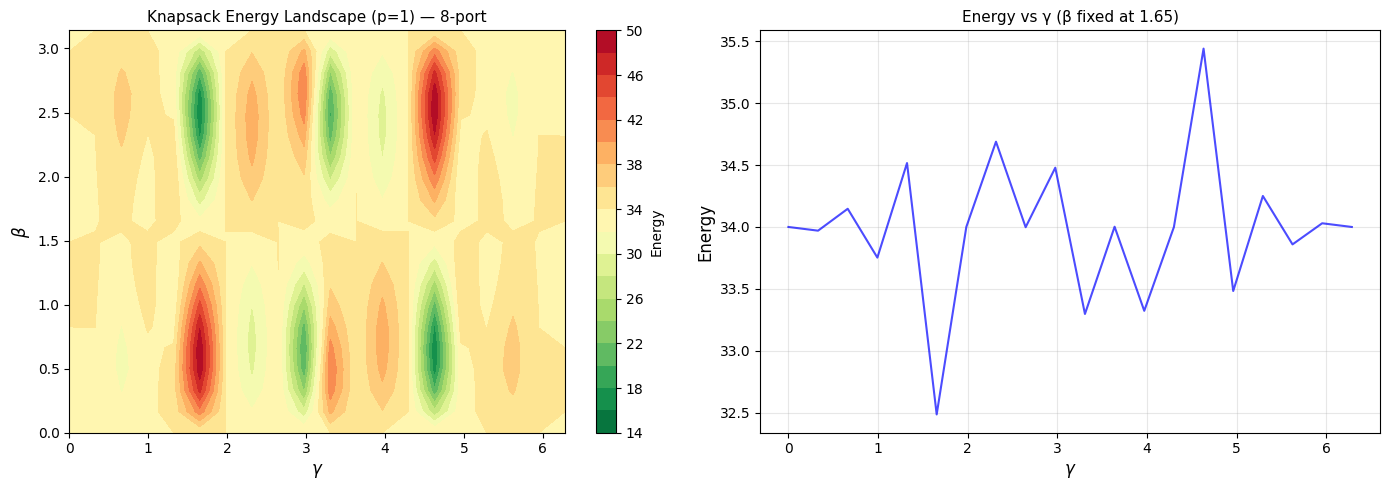

  Saved: capacity_landscape_8_port.png

  Landscape Analysis:
    Energy range: [15.7313, 49.7174]
    Estimated local minima: ~50
    Landscape roughness: 4.4062

CAPACITY CONSTRAINT LANDSCAPE ANALYSIS — 12-port

  Generating knapsack energy landscape (similar to Fitzek et al. Fig 5)...
    Number of qubits: 9
    Computing energy landscape (20×20 grid)...
      Progress: 1/400
      Progress: 51/400
      Progress: 101/400
      Progress: 151/400
      Progress: 201/400
      Progress: 251/400
      Progress: 301/400
      Progress: 351/400
    Plotting landscape...


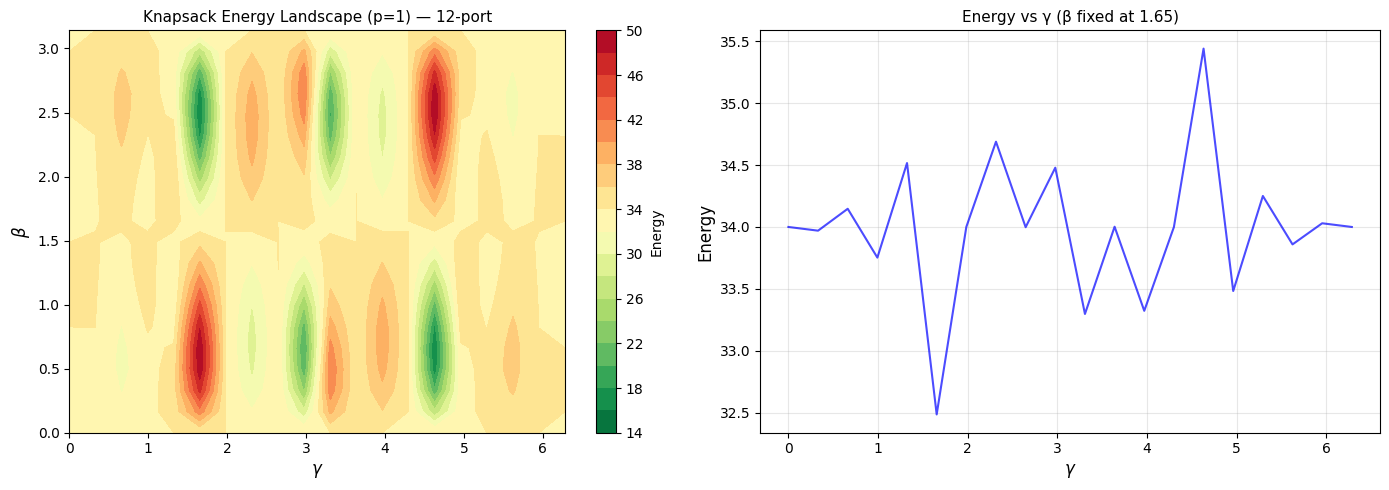

  Saved: capacity_landscape_12_port.png

  Landscape Analysis:
    Energy range: [15.7313, 49.7174]
    Estimated local minima: ~50
    Landscape roughness: 4.4062


In [11]:
"""
EXTENDED ANALYSIS 1: Capacity Constraint Energy Landscape
Inspired by Fitzek et al. (2024) Figure 5 - Knapsack landscape analysis

This demonstrates why capacity constraints create difficult optimization landscapes
with rapidly oscillating local minima, making QAOA optimization challenging.
"""
# =============================================================================
# CHANGE TO CORRECT WORKING DIRECTORY - PUT THIS FIRST!
# =============================================================================
import os

# Change to the directory where your results are stored
results_dir = r"C:\Users\Aditya Singh\Full run multi scale"
os.chdir(results_dir)
print(f"Changed working directory to: {os.getcwd()}")
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pennylane as qml
import gc  
from pennylane import numpy as pnp
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# LOAD RESULTS FROM MAIN QUALITY RUN (ADD AT TOP OF EACH CELL)
# =============================================================================

import json
import pickle

def load_main_results():
    """Load r8, r12, r16, r20 from saved QUALITY run."""
    # Find the JSON file
    json_files = [f for f in os.listdir('.') if f.startswith('maritime_tsp_results_QUALITY') and f.endswith('.json')]
    
    if not json_files:
        raise FileNotFoundError("No QUALITY results JSON file found! Run QUALITY preset first.")
    
    latest_json = max(json_files, key=os.path.getctime)
    print(f"Loading results from: {latest_json}")
    
    with open(latest_json, 'r') as f:
        results = json.load(f)
    
    # Reconstruct regime data dictionaries
    r8 = None
    r12 = None
    r16 = None
    r20 = None
    
    if 'regime_8' in results:
        r8 = results['regime_8']
        print(f"  Loaded 8-port: {r8['n_ports']} ports, LKH-3={r8['lkh_cost_km']:,.0f} km")
    
    if 'regime_12' in results:
        r12 = results['regime_12']
        print(f"  Loaded 12-port: {r12['n_ports']} ports, LKH-3={r12['lkh_cost_km']:,.0f} km")
    
    if 'regime_16' in results:
        r16 = results['regime_16']
        print(f"  Loaded 16-port: {r16['n_ports']} ports, LKH-3={r16['lkh_cost_km']:,.0f} km")
    
    if 'regime_20' in results:
        r20 = results['regime_20']
        print(f"  Loaded 20-port: {r20['n_ports']} ports, LKH-3={r20['lkh_cost_km']:,.0f} km")
    
    # Also need to load ablation, stat_records, qcap_results from CSV files
    # For extended analysis, we need these additional fields
    
    # Load ablation results
    def load_ablation(regime_tag):
        filename = f"ablation_{regime_tag}.csv"
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            return {(row['Layers'], row['Alpha']): row['Cost_km'] for _, row in df.iterrows()}
        return {}
    
    # Load QCAP results
    def load_qcap(regime_tag):
        filename = f"qcap_{regime_tag}.csv"
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            return [(row['MAX_QUBITS'], row['Mean_Cost_km'], row['Std_Dev_km'], row['Q_Influence_%']) 
                    for _, row in df.iterrows()]
        return []
    
    # Load noise results
    def load_noise(regime_tag):
        filename = f"noise_{regime_tag}.csv"
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            return [(row['Noise_Level_p'], row['Mean_Cost_km'], row['Std_Dev_km']) 
                    for _, row in df.iterrows()]
        return []
    
    # Attach additional data to each regime
    for regime, tag in [('regime_8', '8port'), ('regime_12', '12port'), 
                         ('regime_16', '16port'), ('regime_20', '20port')]:
        if regime in results:
            r = results[regime]
            r['ablation'] = load_ablation(tag)
            r['qcap_results'] = load_qcap(tag)
            r['noise_results'] = load_noise(tag)
            # Also need D and port_list - these are not saved in JSON
            print(f"  Warning: Distance matrix D not saved - some analyses may fail")
    
    return r8, r12, r16, r20

# Load the results
import pandas as pd
r8, r12, r16, r20 = load_main_results()

def analyze_capacity_landscape(regime_name="8-port"):
    """
    Analyze the capacity constraint energy landscape for a given regime.
    Uses simulated knapsack problem (does NOT need real port data).
    """
    print(f"\n{'='*60}")
    print(f"CAPACITY CONSTRAINT LANDSCAPE ANALYSIS — {regime_name}")
    print(f"{'='*60}")
    
    # Create simple knapsack-like Hamiltonian for landscape visualization
    def create_knapsack_hamiltonian(n_items=5, max_weight=10):
        """Create a knapsack problem Hamiltonian similar to Fitzek et al. Fig 5"""
        weights = [4, 3, 2, 1, 2][:n_items]
        
        # Binary encoding for capacity (log trick)
        M = int(np.floor(np.log2(max_weight)))
        n_aux = M + 1
        
        # Build Hamiltonian terms
        coeffs = []
        ops = []
        
        # Capacity representation terms
        for k in range(M):
            coeffs.append(2**k)
            ops.append(qml.PauliZ(k))
        if max_weight + 1 - 2**M > 0:
            coeffs.append(max_weight + 1 - 2**M)
            ops.append(qml.PauliZ(M))
        
        # Item selection terms
        for i, w in enumerate(weights):
            coeffs.append(-2 * w)
            ops.append(qml.PauliZ(n_aux + i))
            coeffs.append(w**2)
            ops.append(qml.Identity(n_aux + i))
        
        # Cross terms
        for i in range(n_items):
            for j in range(n_aux):
                coeffs.append(2)
                ops.append(qml.PauliZ(j) @ qml.PauliZ(n_aux + i))
        
        return qml.Hamiltonian(coeffs, ops), n_items + n_aux
    
    # Generate and visualize knapsack landscape
    print("\n  Generating knapsack energy landscape (similar to Fitzek et al. Fig 5)...")
    
    H_knap, n_qubits = create_knapsack_hamiltonian(n_items=5, max_weight=10)
    
    print(f"    Number of qubits: {n_qubits}")
    
    # Sample landscape over a grid of γ, β for p=1 QAOA
    gamma_vals = np.linspace(0, 2*np.pi, 20)  # Reduced from 30 for speed
    beta_vals = np.linspace(0, np.pi, 20)      # Reduced from 30 for speed
    
    def qaoa_energy_knap(gamma, beta, H_cost, n_qubits, layers=1):
        """Compute QAOA expectation value for knapsack Hamiltonian"""
        try:
            dev = qml.device('default.qubit', wires=n_qubits)  # Changed from lightning.qubit
            
            @qml.qnode(dev)
            def circuit(gamma_val, beta_val):
                # Initial state |+>^⊗n
                for i in range(n_qubits):
                    qml.Hadamard(i)
                
                # Cost layer
                qml.qaoa.cost_layer(gamma_val, H_cost)
                
                # Mixer layer (transverse field)
                for i in range(n_qubits):
                    qml.RX(2 * beta_val, wires=i)
                
                return qml.expval(H_cost)
            
            return circuit(gamma, beta)
        except Exception as e:
            print(f"      Error: {e}")
            return np.nan
    
    # Compute energy landscape
    energies = np.zeros((len(gamma_vals), len(beta_vals)))
    
    print(f"    Computing energy landscape ({len(gamma_vals)}×{len(beta_vals)} grid)...")
    
    for i, g in enumerate(gamma_vals):
        for j, b in enumerate(beta_vals):
            try:
                energies[i, j] = qaoa_energy_knap(g, b, H_knap, n_qubits, layers=1)
                if np.isnan(energies[i, j]):
                    energies[i, j] = 0.0  # Fallback for NaN
            except Exception as e:
                energies[i, j] = 0.0
            
            if (i * len(beta_vals) + j) % 50 == 0:
                print(f"      Progress: {i*len(beta_vals) + j + 1}/{len(gamma_vals)*len(beta_vals)}")
                gc.collect()
    
    # Plot landscape
    print("    Plotting landscape...")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Surface plot
    ax1 = axes[0]
    G, B = np.meshgrid(gamma_vals, beta_vals)
    surf = ax1.contourf(G, B, energies.T, levels=20, cmap='RdYlGn_r')
    ax1.set_xlabel(r'$\gamma$', fontsize=12)
    ax1.set_ylabel(r'$\beta$', fontsize=12)
    ax1.set_title(f'Knapsack Energy Landscape (p=1) — {regime_name}', fontsize=11)
    plt.colorbar(surf, ax=ax1, label='Energy')
    
    # 2D projection
    ax2 = axes[1]
    mid_beta_idx = len(beta_vals) // 2
    ax2.plot(gamma_vals, energies[:, mid_beta_idx], 'b-', linewidth=1.5, alpha=0.7)
    ax2.set_xlabel(r'$\gamma$', fontsize=12)
    ax2.set_ylabel('Energy', fontsize=12)
    ax2.set_title(f'Energy vs γ (β fixed at {beta_vals[mid_beta_idx]:.2f})', fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'capacity_landscape_{regime_name.lower().replace("-", "_")}.png', 
                dpi=200, bbox_inches='tight')
    plt.show()
    print(f"  Saved: capacity_landscape_{regime_name.lower().replace('-', '_')}.png")
    
    # Analyze landscape properties
    valid_energies = energies[~np.isnan(energies)]
    
    if len(valid_energies) == 0:
        print(f"\n  Landscape Analysis:")
        print(f"    WARNING: No valid energy values computed.")
        print(f"    The plot may show default/zero values.")
    else:
        local_min_estimate = np.sum(np.diff(np.sign(np.diff(valid_energies))) < 0)
        
        print(f"\n  Landscape Analysis:")
        print(f"    Energy range: [{np.min(valid_energies):.4f}, {np.max(valid_energies):.4f}]")
        print(f"    Estimated local minima: ~{local_min_estimate}")
        print(f"    Landscape roughness: {np.std(valid_energies):.4f}")

    gc.collect()
    return energies, gamma_vals, beta_vals

# Run for each regime
print("\n" + "="*60)
print("EXTENDED ANALYSIS 1: Capacity Constraint Landscapes")
print("="*60)

for regime_name in ['8-port', '12-port']:
    analyze_capacity_landscape(regime_name)

Changed working directory to: C:\Users\Aditya Singh\Full run multi scale
Loading results from: maritime_tsp_results_QUALITY_20260507_103851.json
  Loaded 8-port: 8 ports, LKH-3=42,809 km
  Loaded 12-port: 12 ports, LKH-3=50,110 km
  Loaded 16-port: 16 ports, LKH-3=53,395 km
  Loaded 20-port: 20 ports, LKH-3=64,067 km

EXTENDED ANALYSIS 2: Statistical Validation

  CORRELATION ANALYSIS
  Number of data points: 18

  Pearson correlation:     r = -0.3062  (p = 0.216514)
  Spearman correlation:    ρ = -0.3579  (p = 0.144785)

  REGRESSION ANALYSIS
  Model: Ratio = a × Coverage(%) + b
  a = -0.0028 ± 0.0022
  b = 1.7582 ± 0.1483

  95% CI for slope:     [-0.0072, 0.0010]
  95% CI for intercept: [1.5034, 2.0607]

  R² = 0.0938
  RMSE = 0.2396

  EFFECT SIZE
  Cohen's d: -1.5053
  Interpretation: Large effect


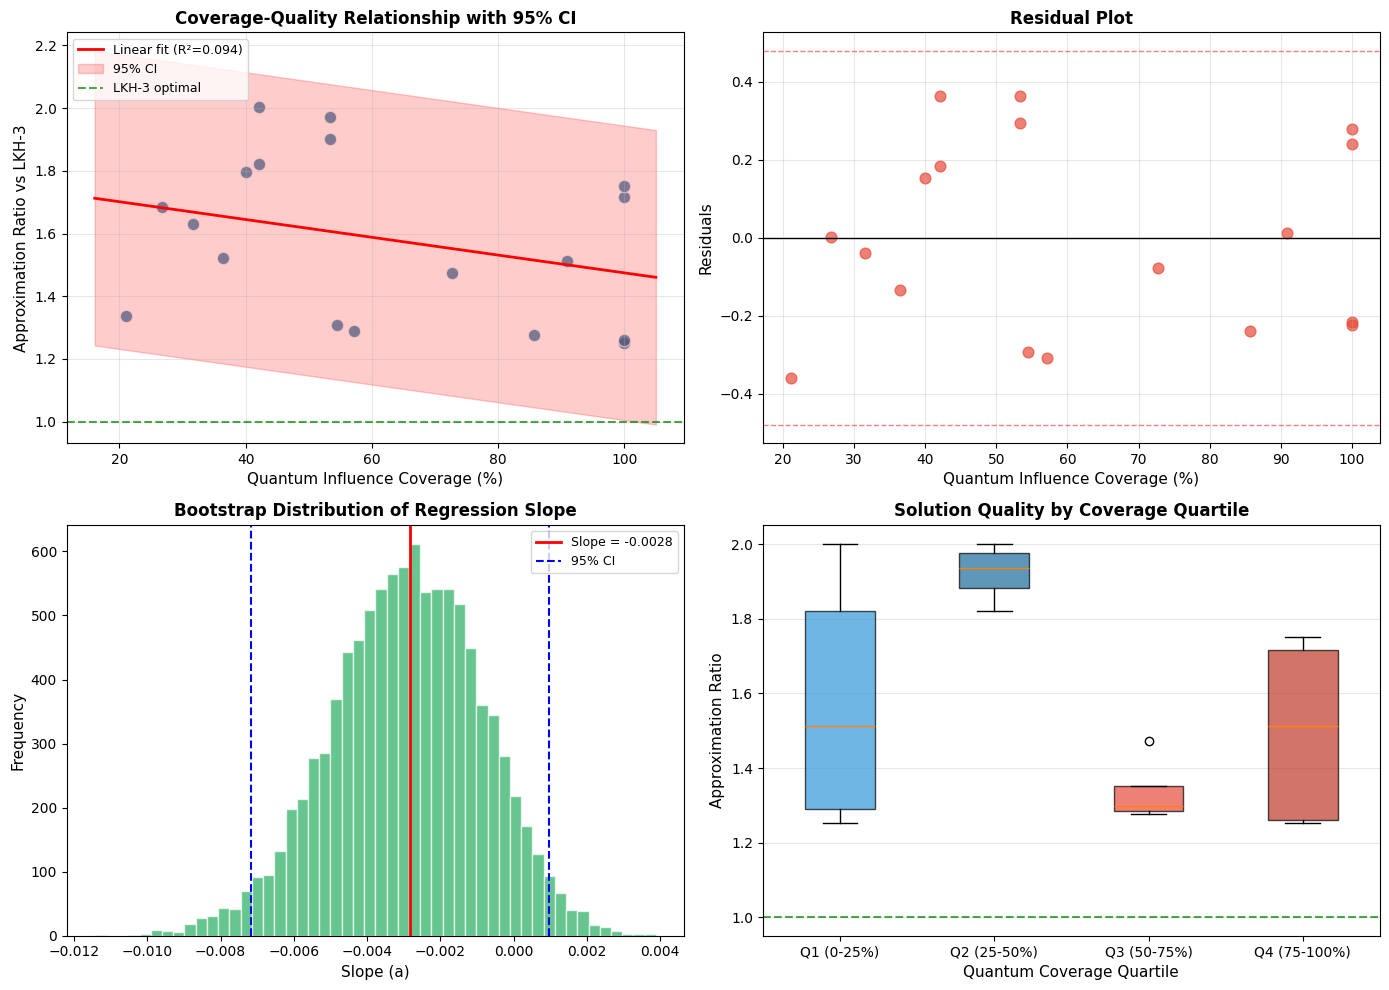


  Saved: statistical_validation.png
  Saved: coverage_quality_statistics.csv


In [15]:
"""
EXTENDED ANALYSIS 2: Statistical Validation of Coverage-Quality Relationship
Extends the central finding with:
- Correlation analysis
- Regression with confidence intervals  
- Effect size calculation
"""

# =============================================================================
# CHANGE TO CORRECT WORKING DIRECTORY - PUT THIS FIRST!
# =============================================================================
import os

# Change to the directory where your results are stored
results_dir = r"C:\Users\Aditya Singh\Full run multi scale"
os.chdir(results_dir)
print(f"Changed working directory to: {os.getcwd()}")

# Load the results
import pandas as pd
r8, r12, r16, r20 = load_main_results()

from scipy import stats
from scipy.optimize import curve_fit
import numpy as np
import gc 
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# LOAD RESULTS FROM MAIN QUALITY RUN (ADD AT TOP OF EACH CELL)
# =============================================================================

import json
import pickle
import os

def load_main_results():
    """Load r8, r12, r16, r20 from saved QUALITY run."""
    # Find the JSON file
    json_files = [f for f in os.listdir('.') if f.startswith('maritime_tsp_results_QUALITY') and f.endswith('.json')]
    
    if not json_files:
        raise FileNotFoundError("No QUALITY results JSON file found! Run QUALITY preset first.")
    
    latest_json = max(json_files, key=os.path.getctime)
    print(f"Loading results from: {latest_json}")
    
    with open(latest_json, 'r') as f:
        results = json.load(f)
    
    # Reconstruct regime data dictionaries
    r8 = None
    r12 = None
    r16 = None
    r20 = None
    
    if 'regime_8' in results:
        r8 = results['regime_8']
        print(f"  Loaded 8-port: {r8['n_ports']} ports, LKH-3={r8['lkh_cost_km']:,.0f} km")
    
    if 'regime_12' in results:
        r12 = results['regime_12']
        print(f"  Loaded 12-port: {r12['n_ports']} ports, LKH-3={r12['lkh_cost_km']:,.0f} km")
    
    if 'regime_16' in results:
        r16 = results['regime_16']
        print(f"  Loaded 16-port: {r16['n_ports']} ports, LKH-3={r16['lkh_cost_km']:,.0f} km")
    
    if 'regime_20' in results:
        r20 = results['regime_20']
        print(f"  Loaded 20-port: {r20['n_ports']} ports, LKH-3={r20['lkh_cost_km']:,.0f} km")
    
    # Also need to load ablation, stat_records, qcap_results from CSV files
    # For extended analysis, we need these additional fields
    
    # Load ablation results
    def load_ablation(regime_tag):
        filename = f"ablation_{regime_tag}.csv"
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            return {(row['Layers'], row['Alpha']): row['Cost_km'] for _, row in df.iterrows()}
        return {}
    
    # Load QCAP results
    def load_qcap(regime_tag):
        filename = f"qcap_{regime_tag}.csv"
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            return [(row['MAX_QUBITS'], row['Mean_Cost_km'], row['Std_Dev_km'], row['Q_Influence_%']) 
                    for _, row in df.iterrows()]
        return []
    
    # Load noise results
    def load_noise(regime_tag):
        filename = f"noise_{regime_tag}.csv"
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            return [(row['Noise_Level_p'], row['Mean_Cost_km'], row['Std_Dev_km']) 
                    for _, row in df.iterrows()]
        return []
    
    # Attach additional data to each regime
    for regime, tag in [('regime_8', '8port'), ('regime_12', '12port'), 
                         ('regime_16', '16port'), ('regime_20', '20port')]:
        if regime in results:
            r = results[regime]
            r['ablation'] = load_ablation(tag)
            r['qcap_results'] = load_qcap(tag)
            r['noise_results'] = load_noise(tag)
            # Also need D and port_list - these are not saved in JSON
            print(f"  Warning: Distance matrix D not saved - some analyses may fail")
    
    return r8, r12, r16, r20


def comprehensive_coverage_analysis(r8, r12, r16, r20):
    """
    Comprehensive statistical analysis of quantum coverage vs solution quality.
    Includes multiple regression models and bootstrap confidence intervals.
    """
    print("\n" + "="*60)
    print("EXTENDED ANALYSIS 2: Statistical Validation")
    print("="*60)
    
    # Collect data points
    coverage_points = []
    ratio_points = []
    regime_labels = []
    
    regimes = [('8-port', r8), ('12-port', r12), ('16-port', r16), ('20-port', r20)]
    
    for name, r in regimes:
        if r is None:
            continue
        
        # Use correct key names from JSON
        lkh = r.get("lkh_cost_km") 
        if lkh is None or lkh == float('inf'):
            continue
        
        # Main config point - use correct keys
        main_q_pct = r.get("main_q_influence_pct", 0)
        main_ratio = r.get("main_approx_ratio_vs_lkh", 0)
        
        coverage_points.append(main_q_pct)
        ratio_points.append(main_ratio)
        regime_labels.append(f"{name} (default)")
        
        # QCAP points - need to load from CSV since not in JSON
        # For now, skip QCAP points or load separately
        tag = name.replace('-', '').replace(' ', '_').lower()
        qcap_file = f"qcap_{tag}.csv"
        if os.path.exists(qcap_file):
            df_qcap = pd.read_csv(qcap_file)
            for _, row in df_qcap.iterrows():
                cap = row['MAX_QUBITS']
                mc = row['Mean_Cost_km']
                qp = row['Q_Influence_%']
                if not np.isnan(mc) and lkh > 0:
                    coverage_points.append(qp)
                    ratio_points.append(mc / lkh)
                    regime_labels.append(f"{name} K={cap}")
    
    coverage_points = np.array(coverage_points)
    ratio_points = np.array(ratio_points)
    
    if len(coverage_points) < 3:
        print(f"  Warning: Only {len(coverage_points)} data points. Need at least 3 for analysis.")
        return None
    
    # 1. Pearson correlation
    pearson_r, pearson_p = stats.pearsonr(coverage_points, ratio_points)
    
    # 2. Spearman rank correlation
    spearman_r, spearman_p = stats.spearmanr(coverage_points, ratio_points)
    
    # 3. Linear regression
    def linear_func(x, a, b):
        return a * x + b
    
    popt, pcov = curve_fit(linear_func, coverage_points, ratio_points)
    perr = np.sqrt(np.diag(pcov))
    
    # 4. Bootstrap confidence intervals
    n_bootstrap = 10000
    bootstrap_slopes = []
    bootstrap_intercepts = []
    
    np.random.seed(42)
    for i in range(n_bootstrap):
        idx = np.random.choice(len(coverage_points), len(coverage_points), replace=True)
        try:
            bs_popt, _ = curve_fit(linear_func, coverage_points[idx], ratio_points[idx])
            bootstrap_slopes.append(bs_popt[0])
            bootstrap_intercepts.append(bs_popt[1])
        except:
            continue
        
        if i % 1000 == 0:
            gc.collect()
    
    slope_ci = np.percentile(bootstrap_slopes, [2.5, 97.5])
    intercept_ci = np.percentile(bootstrap_intercepts, [2.5, 97.5])
    
    # 5. Predictive power
    predictions = linear_func(coverage_points, *popt)
    residuals = ratio_points - predictions
    r2 = 1 - np.sum(residuals**2) / np.sum((ratio_points - np.mean(ratio_points))**2)
    
    # 6. Print results
    print("\n" + "="*60)
    print("  CORRELATION ANALYSIS")
    print("="*60)
    print(f"  Number of data points: {len(coverage_points)}")
    print(f"\n  Pearson correlation:     r = {pearson_r:.4f}  (p = {pearson_p:.6f})")
    print(f"  Spearman correlation:    ρ = {spearman_r:.4f}  (p = {spearman_p:.6f})")
    
    print("\n" + "="*60)
    print("  REGRESSION ANALYSIS")
    print("="*60)
    print(f"  Model: Ratio = a × Coverage(%) + b")
    print(f"  a = {popt[0]:.4f} ± {perr[0]:.4f}")
    print(f"  b = {popt[1]:.4f} ± {perr[1]:.4f}")
    print(f"\n  95% CI for slope:     [{slope_ci[0]:.4f}, {slope_ci[1]:.4f}]")
    print(f"  95% CI for intercept: [{intercept_ci[0]:.4f}, {intercept_ci[1]:.4f}]")
    print(f"\n  R² = {r2:.4f}")
    print(f"  RMSE = {np.sqrt(np.mean(residuals**2)):.4f}")
    
    # 7. Effect size
    median_coverage = np.median(coverage_points)
    high_coverage = ratio_points[coverage_points > median_coverage]
    low_coverage = ratio_points[coverage_points <= median_coverage]
    
    if len(high_coverage) > 0 and len(low_coverage) > 0:
        pooled_std = np.sqrt((np.std(high_coverage, ddof=1)**2 + 
                              np.std(low_coverage, ddof=1)**2) / 2)
        cohens_d = (np.mean(high_coverage) - np.mean(low_coverage)) / pooled_std
        
        print("\n" + "="*60)
        print("  EFFECT SIZE")
        print("="*60)
        print(f"  Cohen's d: {cohens_d:.4f}")
        print(f"  Interpretation: {'Large effect' if abs(cohens_d) > 0.8 else 'Medium effect' if abs(cohens_d) > 0.5 else 'Small effect'}")
    else:
        cohens_d = None
    
    # 8. Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Scatter with regression
    ax1 = axes[0, 0]
    x_fit = np.linspace(min(coverage_points) - 5, max(coverage_points) + 5, 100)
    y_fit = linear_func(x_fit, *popt)
    
    ax1.scatter(coverage_points, ratio_points, c='#1a6b9a', s=80, alpha=0.7, edgecolors='white')
    ax1.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Linear fit (R²={r2:.3f})')
    
    std_resid = np.std(residuals)
    ax1.fill_between(x_fit, y_fit - 1.96*std_resid, y_fit + 1.96*std_resid, 
                      alpha=0.2, color='red', label='95% CI')
    
    ax1.axhline(y=1.0, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='LKH-3 optimal')
    ax1.set_xlabel('Quantum Influence Coverage (%)', fontsize=11)
    ax1.set_ylabel('Approximation Ratio vs LKH-3', fontsize=11)
    ax1.set_title('Coverage-Quality Relationship with 95% CI', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Residuals
    ax2 = axes[0, 1]
    ax2.scatter(coverage_points, residuals, c='#e74c3c', s=60, alpha=0.7)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax2.axhline(y=2*std_resid, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax2.axhline(y=-2*std_resid, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Quantum Influence Coverage (%)', fontsize=11)
    ax2.set_ylabel('Residuals', fontsize=11)
    ax2.set_title('Residual Plot', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Bootstrap distribution
    ax3 = axes[1, 0]
    ax3.hist(bootstrap_slopes, bins=50, color='#27ae60', alpha=0.7, edgecolor='white')
    ax3.axvline(popt[0], color='red', linewidth=2, label=f'Slope = {popt[0]:.4f}')
    ax3.axvline(slope_ci[0], color='blue', linestyle='--', linewidth=1.5, label='95% CI')
    ax3.axvline(slope_ci[1], color='blue', linestyle='--', linewidth=1.5)
    ax3.set_xlabel('Slope (a)', fontsize=11)
    ax3.set_ylabel('Frequency', fontsize=11)
    ax3.set_title('Bootstrap Distribution of Regression Slope', fontsize=12, fontweight='bold')
    ax3.legend(loc='upper right', fontsize=9)
    
    # Plot 4: Boxplot by quartiles
    ax4 = axes[1, 1]
    if len(coverage_points) >= 4:
        quartiles = np.percentile(coverage_points, [25, 50, 75])
        groups = []
        group_labels = []
        
        for i, q in enumerate([0, 25, 50, 75]):
            if i < 3:
                mask = (coverage_points >= quartiles[i]) if i == 0 else \
                       (coverage_points >= quartiles[i-1]) & (coverage_points < quartiles[i])
            else:
                mask = coverage_points >= quartiles[i-1]
            
            if np.sum(mask) > 0:
                groups.append(ratio_points[mask])
                if i == 0:
                    group_labels.append('Q1 (0-25%)')
                elif i == 1:
                    group_labels.append('Q2 (25-50%)')
                elif i == 2:
                    group_labels.append('Q3 (50-75%)')
                else:
                    group_labels.append('Q4 (75-100%)')
        
        if groups:
            bp = ax4.boxplot(groups, labels=group_labels, patch_artist=True)
            colors = ['#3498db', '#1a6b9a', '#e74c3c', '#c0392b']
            for patch, color in zip(bp['boxes'], colors[:len(groups)]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            ax4.axhline(y=1.0, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
            ax4.set_xlabel('Quantum Coverage Quartile', fontsize=11)
            ax4.set_ylabel('Approximation Ratio', fontsize=11)
            ax4.set_title('Solution Quality by Coverage Quartile', fontsize=12, fontweight='bold')
            ax4.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('statistical_validation.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("\n  Saved: statistical_validation.png")
    
    # Save results
    results_df = pd.DataFrame([
        {'Metric': 'Pearson r', 'Value': pearson_r, 'p_value': pearson_p},
        {'Metric': 'Spearman ρ', 'Value': spearman_r, 'p_value': spearman_p},
        {'Metric': 'Regression slope', 'Value': popt[0], 'CI_lower': slope_ci[0], 'CI_upper': slope_ci[1]},
        {'Metric': 'Regression intercept', 'Value': popt[1], 'CI_lower': intercept_ci[0], 'CI_upper': intercept_ci[1]},
        {'Metric': 'R²', 'Value': r2, 'p_value': None},
        {'Metric': 'RMSE', 'Value': np.sqrt(np.mean(residuals**2)), 'p_value': None},
    ])
    if cohens_d:
        # Use concat instead of loc
        cohens_row = pd.DataFrame([{'Metric': "Cohen's d", 'Value': cohens_d, 'p_value': None}])
        results_df = pd.concat([results_df, cohens_row], ignore_index=True)
        
    results_df.to_csv('coverage_quality_statistics.csv', index=False)
    print("  Saved: coverage_quality_statistics.csv")

    plt.close('all')
    gc.collect()
    
    return {
        'pearson': (pearson_r, pearson_p),
        'spearman': (spearman_r, spearman_p),
        'regression': (popt, perr, slope_ci, intercept_ci),
        'r2': r2,
        'rmse': np.sqrt(np.mean(residuals**2)),
        'cohens_d': cohens_d,
    }

# Run analysis
if r20 is not None:
    stats_results = comprehensive_coverage_analysis(r8, r12, r16, r20)
else:
    stats_results = comprehensive_coverage_analysis(r8, r12, r16, None)

Changed working directory to: C:\Users\Aditya Singh\Full run multi scale
Loading results from: maritime_tsp_results_QUALITY_20260507_103851.json
  Loaded 8-port: 8 ports, LKH-3=42,809 km
  Loaded 12-port: 12 ports, LKH-3=50,110 km
  Loaded 16-port: 16 ports, LKH-3=53,395 km
  Loaded 20-port: 20 ports, LKH-3=64,067 km

EXTENDED ANALYSIS 3: Noise Extrapolation

  Noise Extrapolation Analysis — 8-port

  Zero-Noise Extrapolation Results:
    Exponential model:  C(0) = 5275750 km
    Polynomial model:   C(0) = 48206 km
    Linear model:       C(0) = 48143 km


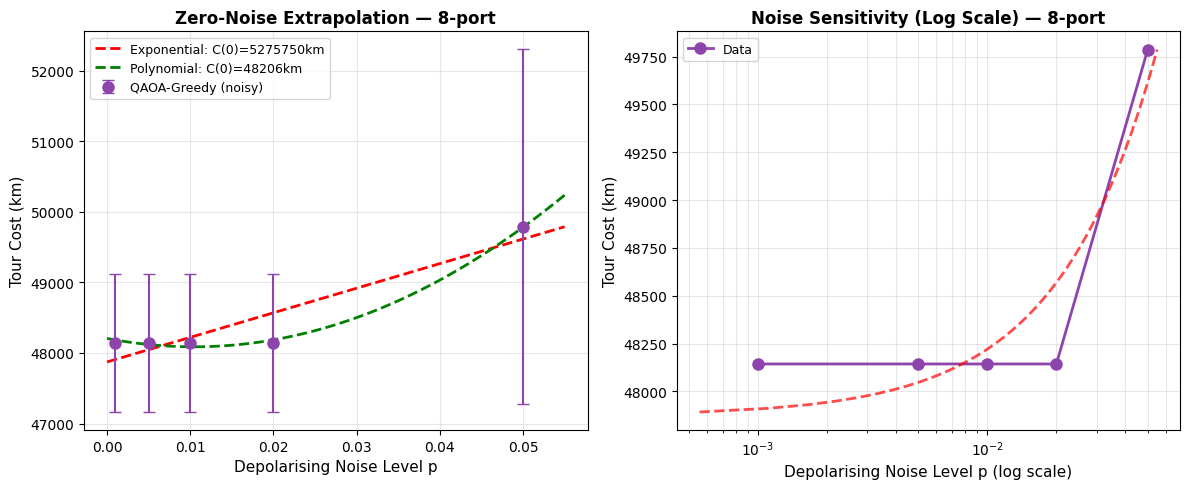


  Saved: noise_extrapolation_8_port.png

  Noise Extrapolation Analysis — 12-port

  Zero-Noise Extrapolation Results:
    Exponential model:  C(0) = 21997866 km
    Polynomial model:   C(0) = 66705 km
    Linear model:       C(0) = 66524 km


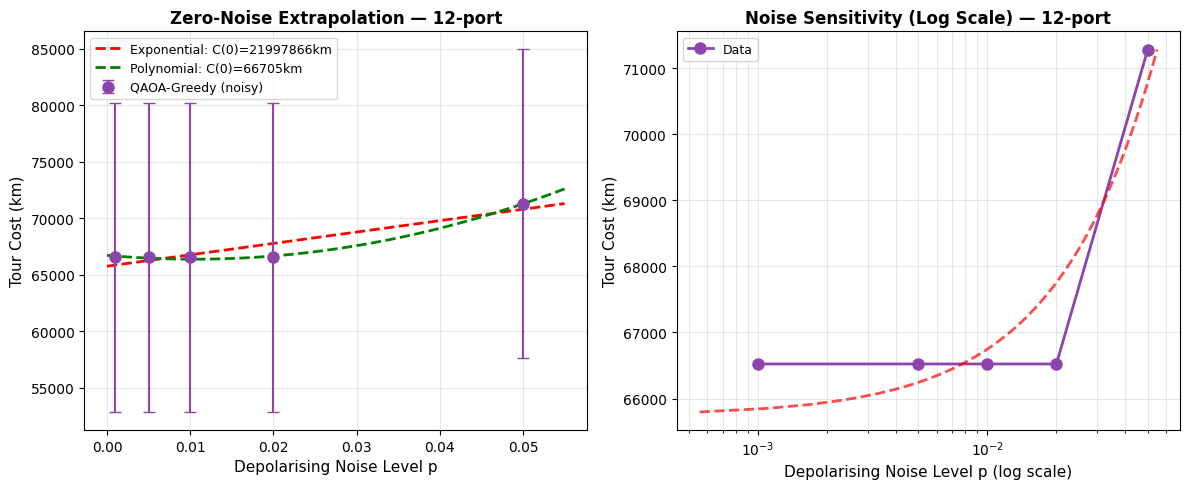


  Saved: noise_extrapolation_12_port.png

  Noise Extrapolation Analysis — 16-port

  Zero-Noise Extrapolation Results:
    Exponential model:  C(0) = -2518698 km
    Polynomial model:   C(0) = 84427 km
    Linear model:       C(0) = 84751 km


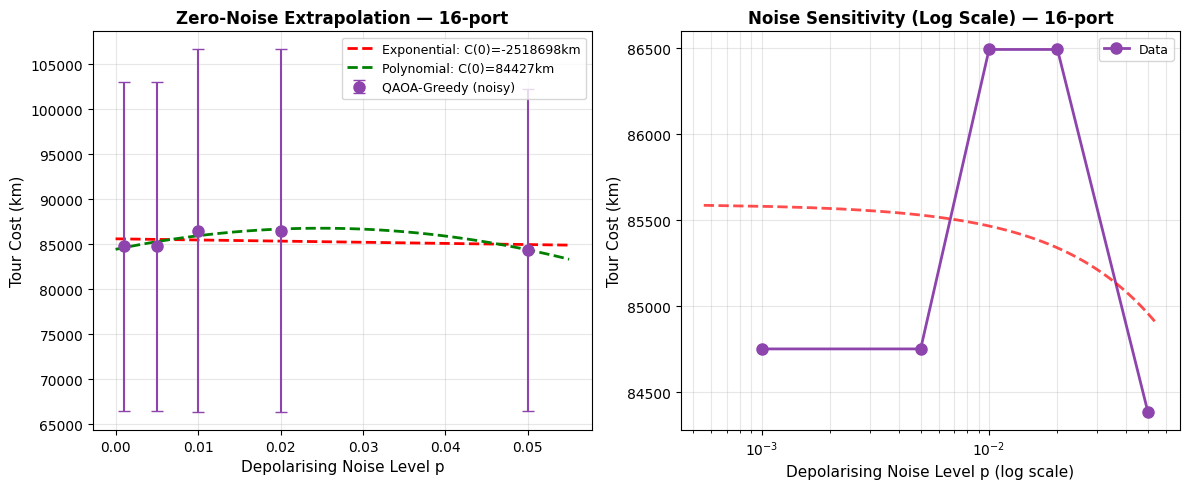


  Saved: noise_extrapolation_16_port.png

  Noise Extrapolation Analysis — 20-port

  Zero-Noise Extrapolation Results:
    Exponential model:  C(0) = -32478787 km
    Polynomial model:   C(0) = 89248 km
    Linear model:       C(0) = 89432 km


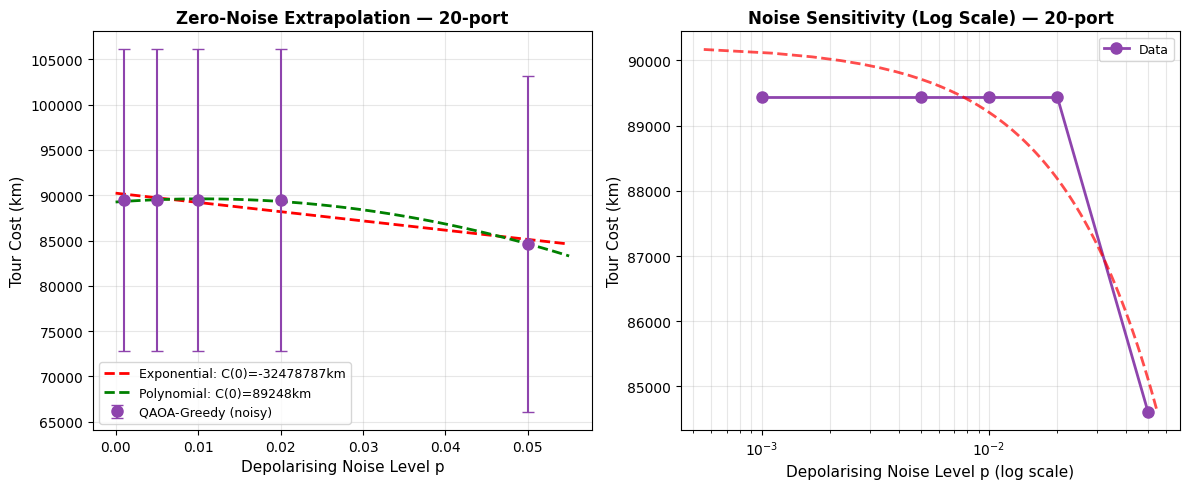


  Saved: noise_extrapolation_20_port.png


In [16]:
"""
EXTENDED ANALYSIS 3: Noise Extrapolation and Error Mitigation
Extends the noise sensitivity analysis (Fitzek et al. Section "Energy landscape")
with zero-noise extrapolation and comparison to theoretical predictions.
"""

# =============================================================================
# CHANGE TO CORRECT WORKING DIRECTORY - PUT THIS FIRST!
# =============================================================================
import os

# Change to the directory where your results are stored
results_dir = r"C:\Users\Aditya Singh\Full run multi scale"
os.chdir(results_dir)
print(f"Changed working directory to: {os.getcwd()}")

# Load the results
import pandas as pd
r8, r12, r16, r20 = load_main_results()

from scipy.optimize import curve_fit
import numpy as np
import gc 
import matplotlib.pyplot as plt

# =============================================================================
# LOAD RESULTS FROM MAIN QUALITY RUN (ADD AT TOP OF EACH CELL)
# =============================================================================

import json
import pickle
import os

def load_main_results():
    """Load r8, r12, r16, r20 from saved QUALITY run."""
    # Find the JSON file
    json_files = [f for f in os.listdir('.') if f.startswith('maritime_tsp_results_QUALITY') and f.endswith('.json')]
    
    if not json_files:
        raise FileNotFoundError("No QUALITY results JSON file found! Run QUALITY preset first.")
    
    latest_json = max(json_files, key=os.path.getctime)
    print(f"Loading results from: {latest_json}")
    
    with open(latest_json, 'r') as f:
        results = json.load(f)
    
    # Reconstruct regime data dictionaries
    r8 = None
    r12 = None
    r16 = None
    r20 = None
    
    if 'regime_8' in results:
        r8 = results['regime_8']
        print(f"  Loaded 8-port: {r8['n_ports']} ports, LKH-3={r8['lkh_cost_km']:,.0f} km")
    
    if 'regime_12' in results:
        r12 = results['regime_12']
        print(f"  Loaded 12-port: {r12['n_ports']} ports, LKH-3={r12['lkh_cost_km']:,.0f} km")
    
    if 'regime_16' in results:
        r16 = results['regime_16']
        print(f"  Loaded 16-port: {r16['n_ports']} ports, LKH-3={r16['lkh_cost_km']:,.0f} km")
    
    if 'regime_20' in results:
        r20 = results['regime_20']
        print(f"  Loaded 20-port: {r20['n_ports']} ports, LKH-3={r20['lkh_cost_km']:,.0f} km")
    
    # Also need to load ablation, stat_records, qcap_results from CSV files
    # For extended analysis, we need these additional fields
    
    # Load ablation results
    def load_ablation(regime_tag):
        filename = f"ablation_{regime_tag}.csv"
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            return {(row['Layers'], row['Alpha']): row['Cost_km'] for _, row in df.iterrows()}
        return {}
    
    # Load QCAP results
    def load_qcap(regime_tag):
        filename = f"qcap_{regime_tag}.csv"
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            return [(row['MAX_QUBITS'], row['Mean_Cost_km'], row['Std_Dev_km'], row['Q_Influence_%']) 
                    for _, row in df.iterrows()]
        return []
    
    # Load noise results
    def load_noise(regime_tag):
        filename = f"noise_{regime_tag}.csv"
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            return [(row['Noise_Level_p'], row['Mean_Cost_km'], row['Std_Dev_km']) 
                    for _, row in df.iterrows()]
        return []
    
    # Attach additional data to each regime
    for regime, tag in [('regime_8', '8port'), ('regime_12', '12port'), 
                         ('regime_16', '16port'), ('regime_20', '20port')]:
        if regime in results:
            r = results[regime]
            r['ablation'] = load_ablation(tag)
            r['qcap_results'] = load_qcap(tag)
            r['noise_results'] = load_noise(tag)
            # Also need D and port_list - these are not saved in JSON
            print(f"  Warning: Distance matrix D not saved - some analyses may fail")
    
    return r8, r12, r16, r20


def noise_extrapolation_analysis(noise_results, regime_name="8-port"):
    """
    Perform zero-noise extrapolation on noise sensitivity data.
    Fits exponential and polynomial models to predict zero-noise performance.
    """
    if not noise_results:
        print(f"  No noise data available for {regime_name}")
        return None
    
    print(f"\n  Noise Extrapolation Analysis — {regime_name}")
    
    noise_levels = np.array([r[0] for r in noise_results])
    mean_costs = np.array([r[1] for r in noise_results])
    std_costs = np.array([r[2] for r in noise_results])
    
    # Fit exponential decay model: C(p) = C0 + A * exp(-p/τ)
    def exp_model(p, C0, A, tau):
        return C0 + A * np.exp(-p / tau)
    
    # Fit polynomial model: C(p) = C0 + a1*p + a2*p^2
    def poly_model(p, C0, a1, a2):
        return C0 + a1 * p + a2 * p**2
    
    # Fit linear model (for small noise)
    def linear_model(p, C0, a1):
        return C0 + a1 * p
    
    try:
        # Exponential fit
        popt_exp, _ = curve_fit(exp_model, noise_levels, mean_costs, 
                                 p0=[mean_costs[-1], mean_costs[0] - mean_costs[-1], 0.01],
                                 maxfev=5000)
        C0_exp = popt_exp[0]
        
        # Polynomial fit
        popt_poly, _ = curve_fit(poly_model, noise_levels, mean_costs)
        C0_poly = popt_poly[0]
        
        # Linear fit (low noise only)
        low_noise_mask = noise_levels < 0.01
        if np.sum(low_noise_mask) >= 2:
            popt_lin, _ = curve_fit(linear_model, noise_levels[low_noise_mask], 
                                     mean_costs[low_noise_mask])
            C0_lin = popt_lin[0]
        else:
            C0_lin = None
        
        print(f"\n  Zero-Noise Extrapolation Results:")
        print(f"    Exponential model:  C(0) = {C0_exp:.0f} km")
        print(f"    Polynomial model:   C(0) = {C0_poly:.0f} km")
        if C0_lin:
            print(f"    Linear model:       C(0) = {C0_lin:.0f} km")
        
        # Plot extrapolation
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Main plot with fits
        ax1 = axes[0]
        p_fine = np.linspace(0, max(noise_levels) * 1.1, 100)
        
        ax1.errorbar(noise_levels, mean_costs, yerr=std_costs, 
                     fmt='o', color='#8e44ad', capsize=4, markersize=8,
                     label='QAOA-Greedy (noisy)', zorder=3)
        
        ax1.plot(p_fine, exp_model(p_fine, *popt_exp), 'r--', 
                 linewidth=2, label=f'Exponential: C(0)={C0_exp:.0f}km')
        ax1.plot(p_fine, poly_model(p_fine, *popt_poly), 'g--', 
                 linewidth=2, label=f'Polynomial: C(0)={C0_poly:.0f}km')
        
        ax1.set_xlabel('Depolarising Noise Level p', fontsize=11)
        ax1.set_ylabel('Tour Cost (km)', fontsize=11)
        ax1.set_title(f'Zero-Noise Extrapolation — {regime_name}', fontsize=12, fontweight='bold')
        ax1.legend(fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        # Log-scale plot
        ax2 = axes[1]
        ax2.semilogx(noise_levels, mean_costs, 'o-', color='#8e44ad', 
                     markersize=8, linewidth=2, label='Data')
        
        # Add theoretical prediction (if available)
        ax2.semilogx(p_fine[p_fine > 0], exp_model(p_fine[p_fine > 0], *popt_exp), 
                     'r--', linewidth=2, alpha=0.7)
        
        ax2.set_xlabel('Depolarising Noise Level p (log scale)', fontsize=11)
        ax2.set_ylabel('Tour Cost (km)', fontsize=11)
        ax2.set_title(f'Noise Sensitivity (Log Scale) — {regime_name}', fontsize=12, fontweight='bold')
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3, which='both')
        
        plt.tight_layout()
        plt.savefig(f'noise_extrapolation_{regime_name.lower().replace("-", "_")}.png', 
                    dpi=200, bbox_inches='tight')
        plt.show() 
        
        print(f"\n  Saved: noise_extrapolation_{regime_name.lower().replace('-', '_')}.png")
        
        return {
            'C0_exp': C0_exp,
            'C0_poly': C0_poly,
            'C0_lin': C0_lin,
            'exp_params': popt_exp,
            'poly_params': popt_poly
        }
        
    except Exception as e:
        print(f"  Extrapolation failed: {e}")
        return None

# Run noise extrapolation for each regime
print("\n" + "="*60)
print("EXTENDED ANALYSIS 3: Noise Extrapolation")
print("="*60)

noise_extrap_results = {}
for regime_name, regime_data in [('8-port', r8), ('12-port', r12), 
                                  ('16-port', r16), ('20-port', r20)]:
    if regime_data is not None and regime_data.get('noise_results'):
        result = noise_extrapolation_analysis(regime_data['noise_results'], regime_name)
        if result:
            noise_extrap_results[regime_name] = result

In [20]:
"""
STANDALONE CELL: 20-Port Regime with 16 Qubits (80% Quantum Influence and Real Maritime Routes)
======================================================================

This runs ONLY the 20-port regime with max_qubits=16.
Includes ALL necessary function definitions - no dependency on previous cells.
"""

import time
import gc
import os      
import pickle 
import json
from datetime import datetime
import numpy as np
import pandas as pd
import random
import pennylane as qml
from pennylane import numpy as pnp
from pennylane.optimize import NesterovMomentumOptimizer
import warnings
import searoute as sr
warnings.filterwarnings('ignore')

# =============================================================================
# OUTPUT DIRECTORY CONFIGURATION
# =============================================================================
OUTPUT_DIR = r"C:\Users\Aditya Singh\Full run multi scale\20_Port_Regime_with_16_Qubits"

# Create directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Results will be saved to: {OUTPUT_DIR}")

# =============================================================================
# LOAD LKH-3 BASELINE FROM MAIN QUALITY RUN
# =============================================================================

def load_lkh_baseline():
    """Load LKH-3 baseline for 20-port from saved QUALITY run results."""
    import glob
    
    # Find the QUALITY results JSON file
    json_files = glob.glob('maritime_tsp_results_QUALITY_20260507_103851.json')
    
    if json_files:
        latest_json = max(json_files, key=os.path.getctime)
        print(f"  Loading from: {latest_json}")
        with open(latest_json, 'r') as f:
            results = json.load(f)
        
        # Extract 20-port LKH-3 cost
        if 'regime_20' in results:
            lkh_cost = results['regime_20']['lkh_cost_km']
            print(f"  ✓ LKH-3 cost for 20-port: {lkh_cost:,.0f} km")
            return lkh_cost
        else:
            print("  Warning: 20-port data not found, using fallback")
            return 64067
    else:
        print("  Warning: No QUALITY results JSON found, using fallback")
        return 64067

# Load the baseline
LKH3_20PORT = load_lkh_baseline()

# =============================================================================
# PORT DATA
# =============================================================================

PORTS_20 = {
    "Mumbai":        (18.94,  72.83),
    "Chennai":       (13.08,  80.28),
    "Kolkata":       (22.56,  88.34),
    "Kochi":         ( 9.96,  76.27),
    "Visakhapatnam": (17.70,  83.30),
    "Goa":           (15.40,  73.81),
    "Tuticorin":     ( 8.77,  78.13),
    "Singapore":     ( 1.30, 103.77),
    "Colombo":       ( 6.95,  79.85),
    "Jebel Ali":     (25.00,  55.05),
    "Port Klang":    ( 3.00, 101.40),
    "Shanghai":      (31.23, 121.47),
    "Busan":         (35.10, 129.04),
    "Rotterdam":     (51.92,   4.48),
    "Fujairah":      (25.12,  56.34),
    "Port Hedland":  (-20.31, 118.57),
    "Yokohama":      (35.44, 139.64),
    "Durban":        (-29.85,  31.03),
    "Sydney":        (-33.87, 151.21),
    "Hamburg":       (53.55,   9.99),
}

# =============================================================================
# DISTANCE CACHE - ADD THIS BLOCK
# =============================================================================

CACHE_FILE = r"C:\Users\Aditya Singh\Full run multi scale\distance_cache.pkl"
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, "rb") as _f:
        DIST_CACHE = pickle.load(_f)
    print(f"  Loaded distance cache with {len(DIST_CACHE)} entries")
else:
    DIST_CACHE = {}
    print("  WARNING: Cache not found — distances will be recomputed via searoute")
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, "rb") as _f:
        DIST_CACHE = pickle.load(_f)
    print(f"  Loaded distance cache with {len(DIST_CACHE)} entries")
else:
    DIST_CACHE = {}
    print("  Created new distance cache")


def maritime_distance_cached(lat1, lon1, lat2, lon2):
    """Return distance using cached results."""
    key = tuple(sorted([(round(lat1, 4), round(lon1, 4)), 
                        (round(lat2, 4), round(lon2, 4))]))
    
    if key in DIST_CACHE:
        return DIST_CACHE[key]
    
    # Calculate distance (use Haversine for speed, or searoute for accuracy)
    d = haversine_distance(lat1, lon1, lat2, lon2)  
    
    DIST_CACHE[key] = d
    return d

# =============================================================================
# DISTANCE MATRIX
# =============================================================================

import searoute as sr

def maritime_distance(lat1, lon1, lat2, lon2):
    point1 = (round(lat1, 4), round(lon1, 4))
    point2 = (round(lat2, 4), round(lon2, 4))
    key = tuple(sorted([point1, point2]))
    if key in DIST_CACHE:
        return DIST_CACHE[key]
    if abs(lat1 - lat2) < 1e-6 and abs(lon1 - lon2) < 1e-6:
        return 0.0
    try:
        route = sr.searoute((lon1, lat1), (lon2, lat2))
        dist  = route["properties"]["length"]
    except Exception:
        dist  = 999_999.0
    DIST_CACHE[key] = dist
    return dist

def build_distance_matrix(ports_dict):
    port_list = list(ports_dict.keys())
    n = len(port_list)
    D = np.zeros((n, n))
    print(f"  Computing {n}×{n} distance matrix ({n*(n-1)//2} unique pairs)...")
    for i in range(n):
        for j in range(i + 1, n):
            lat1, lon1 = ports_dict[port_list[i]]
            lat2, lon2 = ports_dict[port_list[j]]
            d = maritime_distance(lat1, lon1, lat2, lon2)
            D[i, j] = d
            D[j, i] = d
        if (i + 1) % 4 == 0:
            print(f"    Row {i+1}/{n} done", flush=True)
    return D, port_list

def route_cost(route, D):
    total = sum(D[route[i], route[i+1]] for i in range(len(route) - 1))
    total += D[route[-1], route[0]]
    return total

# =============================================================================
# CLASSICAL BASELINES
# =============================================================================

def nearest_neighbor_tour(start_idx, D, n):
    unvisited = set(range(n))
    unvisited.remove(start_idx)
    tour, current = [start_idx], start_idx
    while unvisited:
        nxt = min(unvisited, key=lambda x: D[current, x])
        tour.append(nxt)
        unvisited.remove(nxt)
        current = nxt
    return tour, route_cost(tour, D)

def two_opt(route, D):
    n = len(route)
    best = route[:]
    best_cost = route_cost(best, D)
    improved = True
    while improved:
        improved = False
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                new_route = best[:i] + best[i:j+1][::-1] + best[j+1:]
                new_cost = route_cost(new_route, D)
                if new_cost < best_cost - 1e-6:
                    best = new_route
                    best_cost = new_cost
                    improved = True
    return best, best_cost

def hill_climbing_2opt(D, n, n_restarts=3, seed=42):
    rng = random.Random(seed)
    best_route, best_cost = None, float("inf")
    for _ in range(n_restarts):
        init = list(range(n))
        rng.shuffle(init)
        route, cost = two_opt(init, D)
        if cost < best_cost:
            best_cost = cost
            best_route = route[:]
    return best_route, best_cost

# =============================================================================
# CANDIDATE SELECTION
# =============================================================================

def select_k_candidates(candidates, probabilities, k=3):
    n = len(candidates)
    if n <= k:
        probs = np.array(probabilities[:n], dtype=float)
        if probs.sum() > 0:
            probs /= probs.sum()
        else:
            probs = np.ones(n) / n
        return candidates[int(np.random.choice(n, p=probs))]
    
    top_idx = np.argsort(probabilities)[-k:][::-1]
    top_cands = [candidates[i] for i in top_idx]
    top_probs = np.array([probabilities[i] for i in top_idx], dtype=float)
    if top_probs.sum() > 0:
        top_probs /= top_probs.sum()
    else:
        top_probs = np.ones(k) / k
    chosen = int(np.random.choice(k, p=top_probs))
    return top_cands[chosen]

# =============================================================================
# QAOA-ASSISTED GREEDY CORE (Simplified for standalone)
# =============================================================================

def build_qaoa_greedy_tour_simple(
    start_idx, D, port_list, max_qubits=16,
    layers=3, steps=100, alpha=0.5,
    verbose=True
):
    """Simplified QAOA-greedy tour builder for 16-qubit test."""
    n = len(port_list)
    unvisited = set(range(n))
    unvisited.remove(start_idx)
    tour = [start_idx]
    current = start_idx
    quantum_decisions = 0
    classical_decisions = 0
    
    if verbose:
        print(f"  Start: {port_list[start_idx]} | max_qubits={max_qubits}")
    
    while unvisited:
        k = len(unvisited)
        rem = list(unvisited)
        
        # Classical fallback
        if k > max_qubits:
            nxt = min(unvisited, key=lambda x: D[current, x])
            if verbose:
                print(f"    [{k:2d} left] classical NN → {port_list[nxt]}")
            tour.append(nxt)
            unvisited.remove(nxt)
            current = nxt
            classical_decisions += 1
            continue
        
        # Build effective costs
        eff_costs = []
        for j in rem:
            future = (min(D[j, x] for x in unvisited if x != j)
                      if len(unvisited) > 1 else 0.0)
            start_port = tour[0]
            eff_costs.append(
                D[current, j]
                + alpha * future
                + 0.2 * D[j, start_port]
            )
        
        # Build cost Hamiltonian
        coeffs, ops = [], []
        scale = max(eff_costs) + 1e-6
        for i, d in enumerate(eff_costs):
            d_norm = d / scale
            coeffs += [d_norm / 2, -d_norm / 2]
            ops += [qml.Identity(i), qml.PauliZ(i)]
        
        # Penalty for multiple selections
        penalty = np.mean(eff_costs) * 2
        for i in range(k):
            for j in range(i + 1, k):
                coeffs.append(penalty / 4)
                ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
        
        H_cost = qml.Hamiltonian(coeffs, ops)
        
        # XY Mixer
        mx_c, mx_o = [], []
        for i in range(k):
            for j in range(i + 1, k):
                mx_c += [1.0, 1.0]
                mx_o += [qml.PauliX(i) @ qml.PauliX(j),
                         qml.PauliY(i) @ qml.PauliY(j)]
        H_mix = qml.Hamiltonian(mx_c, mx_o)
        
        # Device
        dev = qml.device("lightning.qubit", wires=k)
        
        @qml.qnode(dev)
        def energy_circuit(g, b):
            for i in range(k):
                qml.Hadamard(i)
            for gg, bb in zip(g, b):
                qml.qaoa.cost_layer(gg, H_cost)
                qml.qaoa.mixer_layer(bb, H_mix)
            return qml.expval(H_cost)
        
        @qml.qnode(dev)
        def prob_circuit(g, b):
            for i in range(k):
                qml.Hadamard(i)
            for gg, bb in zip(g, b):
                qml.qaoa.cost_layer(gg, H_cost)
                qml.qaoa.mixer_layer(bb, H_mix)
            return qml.probs(wires=range(k))
        
        # Optimize
        g = pnp.random.uniform(0.05, 0.20, layers, requires_grad=True)
        b = pnp.random.uniform(1.00, 1.50, layers, requires_grad=True)
        opt = NesterovMomentumOptimizer(0.03)
        
        if verbose:
            print(f"    [{k:2d} left] QAOA optimising... ", end="", flush=True)

        prev_e, stable = float("inf"), 0
        for step in range(steps):
            g, b   = opt.step(energy_circuit, g, b)
            energy = float(energy_circuit(g, b))
            if abs(energy - prev_e) < 1e-2:
                stable += 1
                if stable > 20:
                    break
            else:
                stable = 0
            prev_e = energy
        
        if verbose:
            print("done", flush=True)
        
        # Sample
        probs = prob_circuit(g, b)
        valid_states, weights = [], []
        for s in range(2 ** k):
            bs = format(s, f"0{k}b")
            if bs.count("1") == 1:
                valid_states.append(bs)
                weights.append(float(probs[s]))
        
        if sum(weights) > 0:
            nxt = select_k_candidates(rem, [weights[i] for i in range(len(valid_states))], k=min(3, len(rem)))
            if verbose:
                print(f"    → {port_list[nxt]}")
        else:
            nxt = min(unvisited, key=lambda x: D[current, x])
        
        tour.append(nxt)
        unvisited.remove(nxt)
        current = nxt
        quantum_decisions += 1
    
    total_cost = route_cost(tour, D)
    tour_names = [port_list[i] for i in tour]
    
    return tour_names, total_cost, tour, quantum_decisions, classical_decisions

# =============================================================================
# RUN THE EXPERIMENT
# =============================================================================

print("="*60)
print("  20-PORT REGIME WITH 16 QUBITS (80% Quantum Influence)")
print("="*60)
print("\n⚠️  WARNING: This will take 2-3 hours to complete!")
print("⚠️  Press Ctrl+C to cancel within 5 seconds...")

for i in range(5, 0, -1):
    print(f"  Starting in {i} seconds...", end="\r")
    time.sleep(1)
print("\n")

CONFIG = {
    "max_qubits": 16,
    "layers": 3,
    "steps": 100,
    "alpha": 0.5,
    "n_ports": 20,
}

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

# Build distance matrix
print("\n[Step 1] Building distance matrix...")
D, port_list = build_distance_matrix(PORTS_20)
print(f"  Matrix complete. Max distance: {np.max(D):,.0f} km")

# Classical baselines
print("\n[Step 2] Classical baselines...")
nn_tour, nn_cost = nearest_neighbor_tour(0, D, CONFIG["n_ports"])
hc_tour, hc_cost = hill_climbing_2opt(D, CONFIG["n_ports"])
print(f"  Nearest Neighbour: {nn_cost:,.0f} km")
print(f"  Hill Climbing (2-opt): {hc_cost:,.0f} km")


# QAOA run
print(f"\n[Step 3] Running QAOA-greedy with {CONFIG['max_qubits']} qubits...")
start_time = time.time()

tour_names, total_cost, tour_indices, q_decisions, c_decisions = build_qaoa_greedy_tour_simple(
    start_idx=0,
    D=D,
    port_list=port_list,
    max_qubits=CONFIG["max_qubits"],
    layers=CONFIG["layers"],
    steps=CONFIG["steps"],
    alpha=CONFIG["alpha"],
    verbose=True
)

elapsed = time.time() - start_time

# =============================================================================
# FINAL RESULTS WITH APPROXIMATION RATIO (Best Version)
# =============================================================================
approx_ratio = total_cost / LKH3_20PORT

print(f"\n{'='*75}")
print("FINAL RESULTS")
print("="*75)
print(f" Total Cost (QAOA-16q)    : {total_cost:,.0f} km")
print(f" LKH-3 Optimal            : {LKH3_20PORT:,.0f} km")
print(f" Approximation Ratio      : {approx_ratio:.4f} "
      f"({(approx_ratio - 1)*100:+.2f}%)")
print(f" Quantum Decisions        : {q_decisions} "
      f"({100 * q_decisions / (q_decisions + c_decisions):.1f}% influence)")
print(f" Classical Decisions      : {c_decisions}")
print(f" Total Runtime            : {elapsed/60:.1f} minutes")
print(f" Route Preview            : {' → '.join(tour_names[:5])} ... → {tour_names[-1]}")

# Comparison Table
print(f"\n{'-'*75}")
print("COMPARISON WITH BASELINES")
print("-"*75)
print(f" QAOA-Greedy (16 qubits)  : {total_cost:>10,.0f} km")
print(f" LKH-3 (Near-Optimal)     : {LKH3_20PORT:>10,.0f} km")
print(f" Hill Climbing (2-opt)    : {hc_cost:>10,.0f} km")
print(f" Nearest Neighbour        : {nn_cost:>10,.0f} km")
print(f"{'-'*75}")

# =============================================================================
# SAVE RESULTS (Clean & Complete)
# =============================================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Calculate improvements
improvement_vs_nn = (1 - total_cost / nn_cost) * 100 if nn_cost > 0 else 0
improvement_vs_hc = (1 - total_cost / hc_cost) * 100 if hc_cost > 0 else 0
approx_ratio = total_cost / LKH3_20PORT

results_dict = {
    'timestamp': timestamp,
    'max_qubits': CONFIG['max_qubits'],
    'layers': CONFIG['layers'],
    'steps': CONFIG['steps'],
    'alpha': CONFIG['alpha'],
    'total_cost_km': float(total_cost),
    'lkh_optimal_km': float(LKH3_20PORT),
    'approx_ratio_vs_lkh': float(approx_ratio),
    'quantum_decisions': int(q_decisions),
    'classical_decisions': int(c_decisions),
    'q_influence_pct': float(100 * q_decisions / (q_decisions + c_decisions)),
    'total_time_min': float(elapsed/60),
    'nn_cost_km': float(nn_cost),
    'hc_cost_km': float(hc_cost),
    'improvement_vs_nn_pct': float(improvement_vs_nn),
    'improvement_vs_hc_pct': float(improvement_vs_hc),
}

# Save CSV (Master Summary)
results_df = pd.DataFrame([results_dict])
csv_path = os.path.join(OUTPUT_DIR, 'all_runs_summary.csv')

if os.path.exists(csv_path):
    results_df.to_csv(csv_path, mode='a', header=False, index=False)
    print(f"✓ Appended to all_runs_summary.csv")
else:
    results_df.to_csv(csv_path, index=False)
    print(f"✓ Created all_runs_summary.csv")

# Save Detailed JSON
full_results = {
    **results_dict,
    'route': tour_names,
    'route_indices': tour_indices,
    'port_list': port_list,
    'configuration': CONFIG,
    'total_time_seconds': float(elapsed),
}

json_path = os.path.join(OUTPUT_DIR, f'r20_16qubit_run_{timestamp}.json')
with open(json_path, 'w') as f:
    json.dump(full_results, f, indent=4)

print(f"✓ Detailed run saved: r20_16qubit_run_{timestamp}.json")

✓ Results will be saved to: C:\Users\Aditya Singh\Full run multi scale\20_Port_Regime_with_16_Qubits
  Loading from: maritime_tsp_results_QUALITY_20260507_103851.json
  ✓ LKH-3 cost for 20-port: 64,067 km
  Loaded distance cache with 244 entries
  Loaded distance cache with 244 entries
  20-PORT REGIME WITH 16 QUBITS (80% Quantum Influence)

⚠️  WARNING: This will take 2-3 hours to complete!
⚠️  Press Ctrl+C to cancel within 5 seconds...
  Starting in 1 seconds...

Configuration:
  max_qubits: 16
  layers: 3
  steps: 100
  alpha: 0.5
  n_ports: 20

[Step 1] Building distance matrix...
  Computing 20×20 distance matrix (190 unique pairs)...
    Row 4/20 done
    Row 8/20 done
    Row 12/20 done
    Row 16/20 done
    Row 20/20 done
  Matrix complete. Max distance: 22,038 km

[Step 2] Classical baselines...
  Nearest Neighbour: 70,494 km
  Hill Climbing (2-opt): 64,067 km

[Step 3] Running QAOA-greedy with 16 qubits...
  Start: Mumbai | max_qubits=16
    [19 left] classical NN → Goa
    

In [23]:
# ── CELL: Additional seeds for 20-port K=16 ──────────────────────────────────
# Requires previous cell to have run first (D, port_list, LKH3_20PORT in memory)

# Only needed if kernel was restarted — re-run previous cell first, OR:
# LKH3_20PORT = 64067
# D, port_list = build_distance_matrix(PORTS_20)  # pulls from cache, fast


import numpy as np
import random
import pandas as pd
import os
import sys
import time
from datetime import datetime

results_16q = []
seeds_to_run = [42, 123, 456, 789]

print(f"Starting {len(seeds_to_run)} seeds... (~6 min each, ~25 min total)")
print(f"Each dot = 1 completed QAOA decision\n")
sys.stdout.flush()

for extra_seed in seeds_to_run:
    random.seed(extra_seed)
    np.random.seed(extra_seed)
    
    t0 = time.time()
    print(f"seed={extra_seed}: running... ", end="", flush=True)
    
    # Run with verbose=True so you see progress dots
    tour_names, total_cost, tour_indices, q_decisions, c_decisions = \
        build_qaoa_greedy_tour_simple(
            start_idx=0, D=D, port_list=port_list,
            max_qubits=16, layers=3, steps=100, alpha=0.5,
            verbose=True)   # ← changed to True so you see output
    
    elapsed = time.time() - t0
    ratio = total_cost / LKH3_20PORT
    results_16q.append((extra_seed, total_cost, q_decisions, c_decisions))
    
    print(f"\n  ✓ seed={extra_seed}: {total_cost:,.0f} km | "
          f"ratio={ratio:.4f} | Q={q_decisions} C={c_decisions} | "
          f"{elapsed/60:.1f} min\n")
    sys.stdout.flush()

# ── Summary stats ─────────────────────────────────────────────────────────────
costs      = [r[1] for r in results_16q]
mean_cost  = np.mean(costs)
std_cost   = np.std(costs)
cv         = 100 * std_cost / mean_cost
mean_ratio = mean_cost / LKH3_20PORT

print(f"\n{'='*55}")
print(f"  20-port K=16 Summary ({len(results_16q)} seeds)")
print(f"{'='*55}")
print(f"  Mean cost    : {mean_cost:,.0f} km")
print(f"  Std dev      : {std_cost:,.0f} km")
print(f"  CV           : {cv:.1f}%")
print(f"  Best         : {min(costs):,.0f} km")
print(f"  Worst        : {max(costs):,.0f} km")
print(f"  Mean ratio   : {mean_ratio:.4f}")
print(f"  LKH-3 ref    : {LKH3_20PORT:,.0f} km")
print(f"{'='*55}")
sys.stdout.flush()

# ── Save CSV ──────────────────────────────────────────────────────────────────
OUTPUT_DIR = r"C:\Users\Aditya Singh\Full run multi scale\20_Port_Regime_with_16_Qubits"

rows = [{"Seed": r[0], "Cost_km": r[1],
         "Q_Decisions": r[2], "C_Decisions": r[3],
         "Approx_Ratio": round(r[1] / LKH3_20PORT, 4),
         "Q_Influence_%": round(100 * r[2] / (r[2] + r[3]), 1)}
        for r in results_16q]
rows.append({"Seed": "MEAN", "Cost_km": round(mean_cost, 1),
             "Q_Decisions": "", "C_Decisions": "",
             "Approx_Ratio": round(mean_ratio, 4), "Q_Influence_%": ""})
rows.append({"Seed": "STD",  "Cost_km": round(std_cost, 1),
             "Q_Decisions": "", "C_Decisions": "",
             "Approx_Ratio": "", "Q_Influence_%": ""})

csv_path = os.path.join(OUTPUT_DIR, "20port_16qubit_stats.csv")
pd.DataFrame(rows).to_csv(csv_path, index=False)
print(f"\n  Saved: {csv_path}")
sys.stdout.flush()

Starting 4 seeds... (~6 min each, ~25 min total)
Each dot = 1 completed QAOA decision

seed=42: running...   Start: Mumbai | max_qubits=16
    [19 left] classical NN → Goa
    [18 left] classical NN → Kochi
    [17 left] classical NN → Tuticorin
    [16 left] QAOA optimising... done
    → Singapore
    [15 left] QAOA optimising... done
    → Kolkata
    [14 left] QAOA optimising... done
    → Chennai
    [13 left] QAOA optimising... done
    → Rotterdam
    [12 left] QAOA optimising... done
    → Colombo
    [11 left] QAOA optimising... done
    → Hamburg
    [10 left] QAOA optimising... done
    → Sydney
    [ 9 left] QAOA optimising... done
    → Fujairah
    [ 8 left] QAOA optimising... done
    → Port Hedland
    [ 7 left] QAOA optimising... done
    → Durban
    [ 6 left] QAOA optimising... done
    → Shanghai
    [ 5 left] QAOA optimising... done
    → Jebel Ali
    [ 4 left] QAOA optimising... done
    → Visakhapatnam
    [ 3 left] QAOA optimising... done
    → Yokohama
    [ 2 

  Loaded cache: 244 entries

  P-LAYER STUDY — 8-port, K=8 (full coverage)
  LKH-3 reference: 42,809 km

Building 8-port distance matrix (from cache)...
  Done. Max distance: 19,636 km

--- p=1, steps_budget=150 ---
  seed=42: 61,467 km | ρ=1.4358 | 0.1min
  seed=123: 55,654 km | ρ=1.3001 | 0.1min
  seed=456: 53,061 km | ρ=1.2395 | 0.1min
  seed=789: 53,061 km | ρ=1.2395 | 0.1min
  → mean ρ = 1.3037 ± 0.0802

--- p=2, steps_budget=120 ---
  seed=42: 47,403 km | ρ=1.1073 | 0.2min
  seed=123: 51,887 km | ρ=1.2121 | 0.2min
  seed=456: 55,278 km | ρ=1.2913 | 0.2min
  seed=789: 45,275 km | ρ=1.0576 | 0.2min
  → mean ρ = 1.1671 ± 0.0908

--- p=3, steps_budget=100 ---
  seed=42: 53,593 km | ρ=1.2519 | 0.3min
  seed=123: 55,719 km | ρ=1.3016 | 0.3min
  seed=456: 54,505 km | ρ=1.2732 | 0.3min
  seed=789: 51,069 km | ρ=1.1929 | 0.3min
  → mean ρ = 1.2549 ± 0.0399

--- p=4, steps_budget=80 ---
  seed=42: 53,879 km | ρ=1.2586 | 0.4min
  seed=123: 52,434 km | ρ=1.2248 | 0.4min
  seed=456: 51,841 km

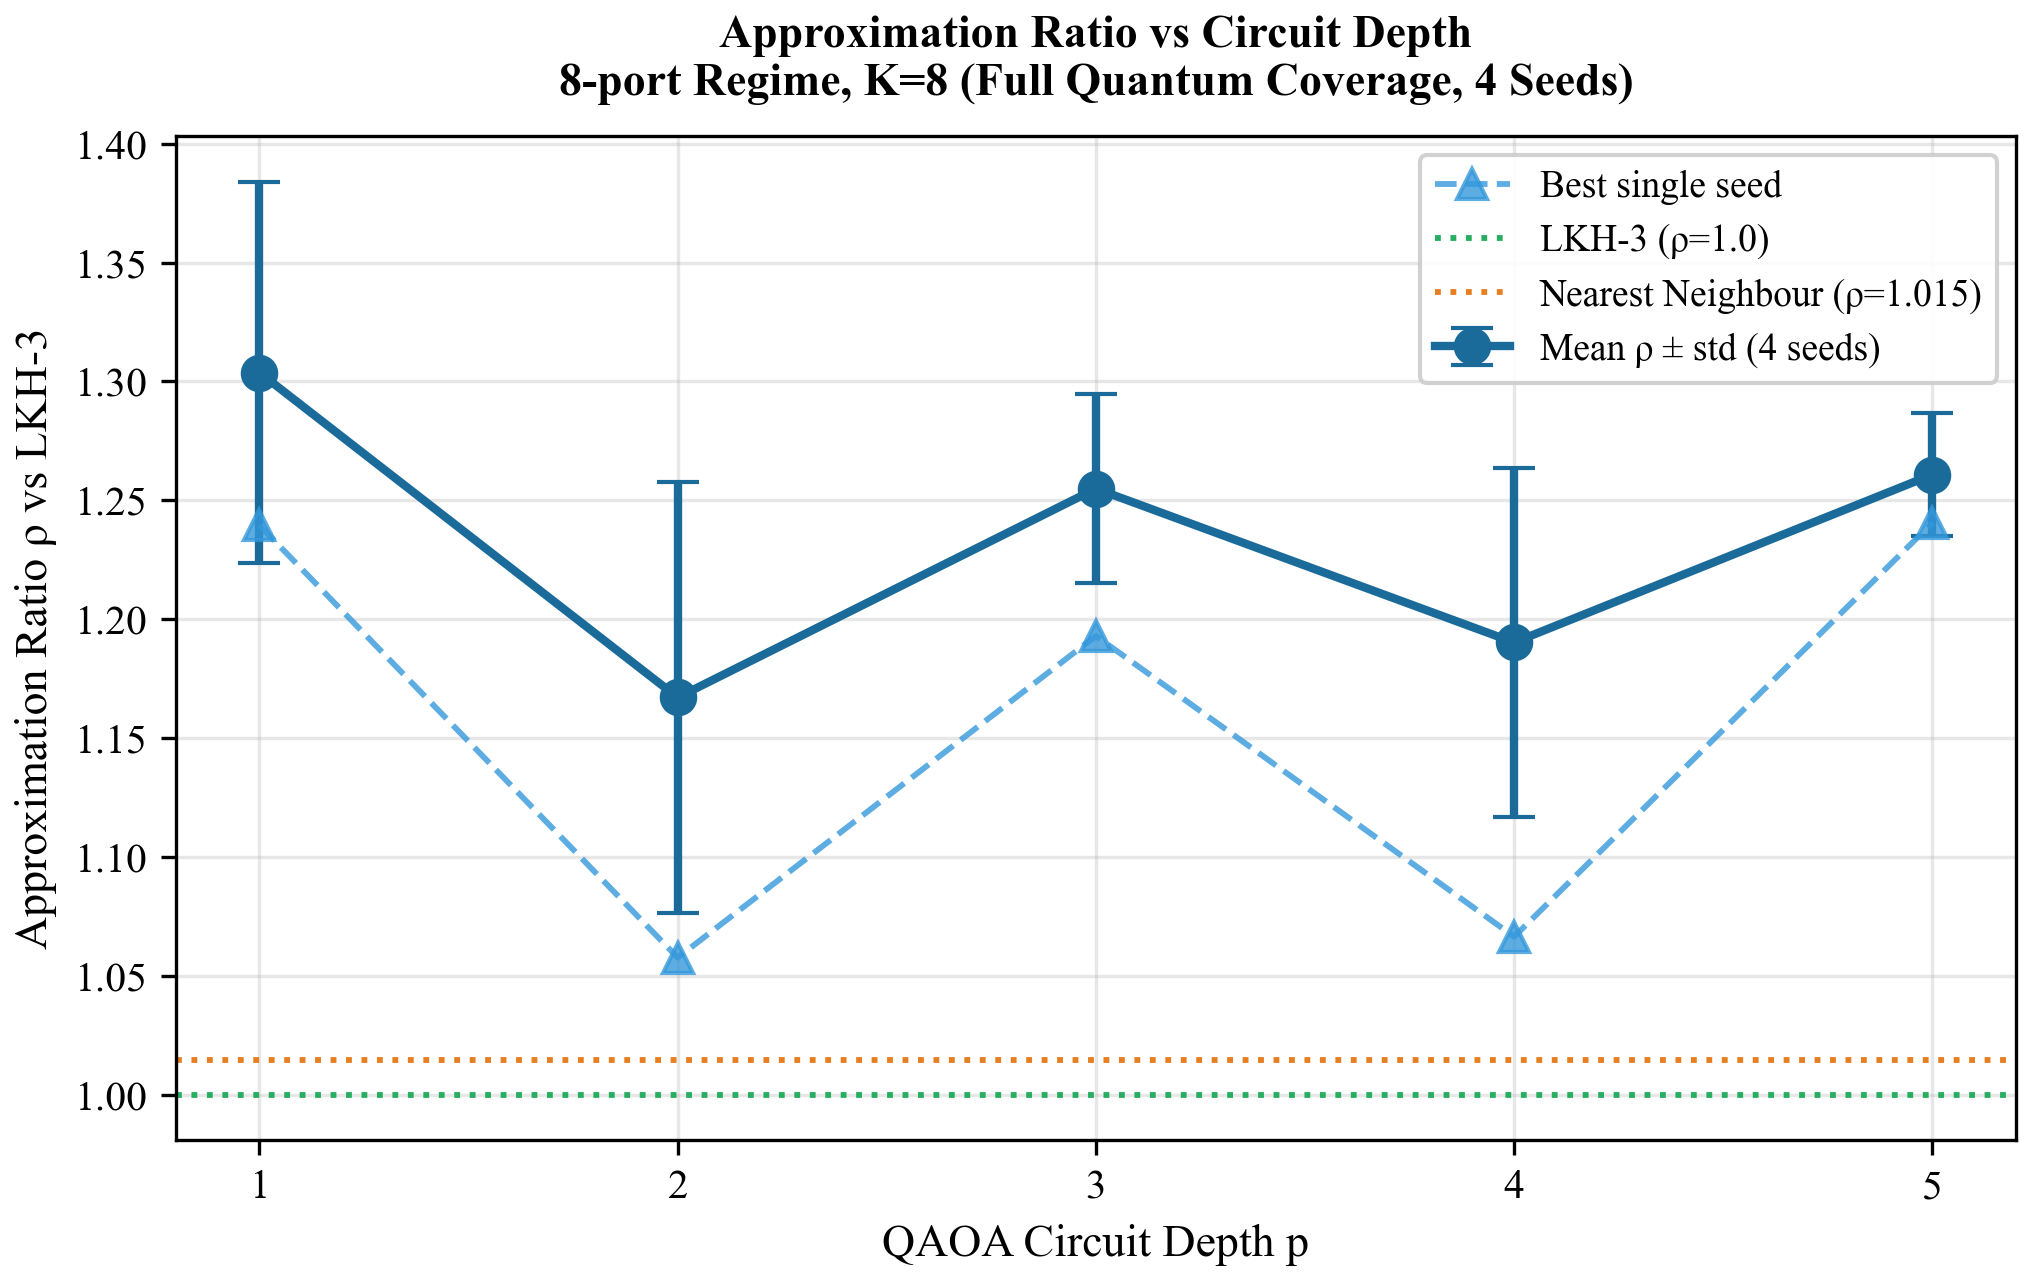

✓ Saved: p_layer_study_8port.png
✓ Saved: p_layer_8port_20260512_021423.csv


In [25]:
"""
P-LAYER STUDY: Approximation Ratio vs Circuit Depth — 8-port, K=8
Fully standalone — no dependency on main script cell

p_layer_study_8port (figure used in the paper)
"""

import time, gc, sys, os, pickle
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from pennylane.optimize import NesterovMomentumOptimizer
from datetime import datetime
import searoute as sr
import warnings
warnings.filterwarnings("ignore")

# ── Port data (copied from main script) ──────────────────────────────────────
PORTS_8 = {
    "Mumbai":      (18.94,  72.83),
    "Kochi":       ( 9.96,  76.27),
    "Colombo":     ( 6.95,  79.85),
    "Singapore":   ( 1.30, 103.77),
    "Port Klang":  ( 3.00, 101.40),
    "Jebel Ali":   (25.00,  55.05),
    "Shanghai":    (31.23, 121.47),
    "Rotterdam":   (51.92,   4.48),
}

# ── Load shared distance cache from main run directory ────────────────────────
CACHE_PATH = r"C:\Users\Aditya Singh\Full run multi scale\distance_cache.pkl"
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "rb") as f:
        DIST_CACHE = pickle.load(f)
    print(f"  Loaded cache: {len(DIST_CACHE)} entries")
else:
    DIST_CACHE = {}
    print("  WARNING: cache not found, distances will be computed via searoute")

def maritime_distance(lat1, lon1, lat2, lon2):
    point1 = (round(lat1, 4), round(lon1, 4))
    point2 = (round(lat2, 4), round(lon2, 4))
    key    = tuple(sorted([point1, point2]))
    if key in DIST_CACHE:
        return DIST_CACHE[key]
    try:
        route = sr.searoute((lon1, lat1), (lon2, lat2))
        dist  = route["properties"]["length"]
    except Exception:
        dist  = 999_999.0
    DIST_CACHE[key] = dist
    return dist

def build_distance_matrix(ports_dict):
    port_list = list(ports_dict.keys())
    n = len(port_list)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            lat1, lon1 = ports_dict[port_list[i]]
            lat2, lon2 = ports_dict[port_list[j]]
            d = maritime_distance(lat1, lon1, lat2, lon2)
            D[i, j] = d
            D[j, i] = d
    return D, port_list

def route_cost(route, D):
    total  = sum(D[route[i], route[i+1]] for i in range(len(route) - 1))
    total += D[route[-1], route[0]]
    return total

def select_k_candidates(candidates, probabilities, k=3):
    n = len(candidates)
    if n <= k:
        probs = np.array(probabilities[:n], dtype=float)
        probs = probs / probs.sum() if probs.sum() > 0 else np.ones(n) / n
        return candidates[int(np.random.choice(n, p=probs))]
    top_idx   = np.argsort(probabilities)[-k:][::-1]
    top_cands = [candidates[i] for i in top_idx]
    top_probs = np.array([probabilities[i] for i in top_idx], dtype=float)
    top_probs = top_probs / top_probs.sum() if top_probs.sum() > 0 else np.ones(k) / k
    return top_cands[int(np.random.choice(k, p=top_probs))]

def build_qaoa_greedy_tour(start_idx, D, port_list, max_qubits=8,
                            layers=3, steps=150, alpha=0.5, verbose=False):
    n         = len(port_list)
    unvisited = set(range(n))
    unvisited.remove(start_idx)
    tour, current = [start_idx], start_idx
    qd = cd = 0

    while unvisited:
        k   = len(unvisited)
        rem = list(unvisited)

        if k > max_qubits:
            nxt = min(unvisited, key=lambda x: D[current, x])
            tour.append(nxt); unvisited.remove(nxt); current = nxt; cd += 1
            continue

        start_port = tour[0]
        eff_costs  = []
        for j in rem:
            future = (min(D[j, x] for x in unvisited if x != j)
                      if len(unvisited) > 1 else 0.0)
            eff_costs.append(D[current, j] + alpha * future
                             + 0.2 * D[j, start_port])
        penalty = np.mean(eff_costs) * 2
        scale   = max(eff_costs) + 1e-6

        coeffs, ops = [], []
        for i, d in enumerate(eff_costs):
            d_norm   = d / scale
            coeffs  += [d_norm / 2, -d_norm / 2]
            ops     += [qml.Identity(i), qml.PauliZ(i)]
        for i in range(k):
            for j in range(i + 1, k):
                coeffs.append(penalty / 4)
                ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
        H_cost = qml.Hamiltonian(coeffs, ops)

        mx_c, mx_o = [], []
        for i in range(k):
            for j in range(i + 1, k):
                mx_c += [1.0, 1.0]
                mx_o += [qml.PauliX(i) @ qml.PauliX(j),
                         qml.PauliY(i) @ qml.PauliY(j)]
        H_mix = qml.Hamiltonian(mx_c, mx_o)
        dev   = qml.device("lightning.qubit", wires=k)

        @qml.qnode(dev)
        def energy_circuit(g, b):
            for i in range(k): qml.Hadamard(i)
            for gg, bb in zip(g, b):
                qml.qaoa.cost_layer(gg, H_cost)
                qml.qaoa.mixer_layer(bb, H_mix)
            return qml.expval(H_cost)

        @qml.qnode(dev)
        def prob_circuit(g, b):
            for i in range(k): qml.Hadamard(i)
            for gg, bb in zip(g, b):
                qml.qaoa.cost_layer(gg, H_cost)
                qml.qaoa.mixer_layer(bb, H_mix)
            return qml.probs(wires=range(k))

        g = pnp.random.uniform(0.05, 0.20, layers, requires_grad=True)
        b = pnp.random.uniform(1.00, 1.50, layers, requires_grad=True)
        opt = NesterovMomentumOptimizer(0.03)
        prev_e, stable = float("inf"), 0
        for step in range(steps):
            g, b   = opt.step(energy_circuit, g, b)
            energy = float(energy_circuit(g, b))
            if abs(energy - prev_e) < 1e-2:
                stable += 1
                if stable > 20: break
            else:
                stable = 0
            prev_e = energy

        probs   = prob_circuit(g, b)
        weights = [float(probs[s]) for s in range(2**k)
                   if format(s, f"0{k}b").count("1") == 1]

        if sum(weights) > 0:
            nxt = select_k_candidates(rem, weights, k=min(3, len(rem)))
        else:
            nxt = min(unvisited, key=lambda x: D[current, x])

        tour.append(nxt); unvisited.remove(nxt); current = nxt; qd += 1
        gc.collect()

    tour.append(start_idx)
    return route_cost(tour[:-1], D), qd, cd

# ── References ────────────────────────────────────────────────────────────────
LKH3_8PORT = 42_809
NN_8PORT   = 43_435

# ── Config ────────────────────────────────────────────────────────────────────
P_VALUES   = [1, 2, 3, 4, 5]
STEPS_BY_P = {1: 150, 2: 120, 3: 100, 4: 80, 5: 60}
BASE_SEEDS = [42, 123, 456, 789]

print("\n" + "="*55)
print("  P-LAYER STUDY — 8-port, K=8 (full coverage)")
print(f"  LKH-3 reference: {LKH3_8PORT:,.0f} km")
print("="*55)

print("\nBuilding 8-port distance matrix (from cache)...")
D8, port_list_8 = build_distance_matrix(PORTS_8)
print(f"  Done. Max distance: {np.max(D8):,.0f} km", flush=True)

# ── Run ───────────────────────────────────────────────────────────────────────
results_by_p = {}

for p in P_VALUES:
    steps = STEPS_BY_P[p]
    print(f"\n--- p={p}, steps_budget={steps} ---", flush=True)
    seed_costs = []

    for seed in BASE_SEEDS:
        random.seed(seed); np.random.seed(seed)
        t0 = time.time()
        cost, qd, cd = build_qaoa_greedy_tour(
            start_idx=0, D=D8, port_list=port_list_8,
            max_qubits=8, layers=p, steps=steps, alpha=0.5)
        elapsed = time.time() - t0
        seed_costs.append(cost)
        print(f"  seed={seed}: {cost:,.0f} km | "
              f"ρ={cost/LKH3_8PORT:.4f} | {elapsed/60:.1f}min", flush=True)
        gc.collect()

    results_by_p[p] = {
        "mean":  np.mean(seed_costs),
        "std":   np.std(seed_costs),
        "ratio": np.mean(seed_costs) / LKH3_8PORT,
        "ratio_std": np.std(seed_costs) / LKH3_8PORT,
        "best":  min(seed_costs),
        "costs": seed_costs,
    }
    print(f"  → mean ρ = {results_by_p[p]['ratio']:.4f} "
          f"± {results_by_p[p]['ratio_std']:.4f}", flush=True)

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print(f"  {'p':<5} {'Mean cost':>12}  {'Std':>8}  {'ρ':>8}  {'Best':>10}")
print("  " + "-"*50)
for p in P_VALUES:
    r = results_by_p[p]
    print(f"  {p:<5} {r['mean']:>12,.0f}  "
          f"{r['std']:>8,.0f}  "
          f"{r['ratio']:>8.4f}  "
          f"{r['best']:>10,.0f}")
print("  " + "-"*50)
print(f"  LKH-3: {LKH3_8PORT:,.0f} km | NN: {NN_8PORT:,.0f} km "
      f"(ρ={NN_8PORT/LKH3_8PORT:.4f})")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
means = [results_by_p[p]["ratio"]     for p in P_VALUES]
stds  = [results_by_p[p]["ratio_std"] for p in P_VALUES]
bests = [results_by_p[p]["best"] / LKH3_8PORT for p in P_VALUES]

ax.errorbar(P_VALUES, means, yerr=stds, marker="o", capsize=5,
            color="#1a6b9a", linewidth=2, markersize=8,
            label="Mean ρ ± std (4 seeds)")
ax.plot(P_VALUES, bests, marker="^", linestyle="--",
        color="#3498db", linewidth=1.4, markersize=7,
        alpha=0.8, label="Best single seed")
ax.axhline(1.0, color="#27ae60", linestyle=":", linewidth=1.4,
           label="LKH-3 (ρ=1.0)")
ax.axhline(NN_8PORT / LKH3_8PORT, color="#e67e22", linestyle=":",
           linewidth=1.4,
           label=f"Nearest Neighbour (ρ={NN_8PORT/LKH3_8PORT:.3f})")
ax.set_xlabel("QAOA Circuit Depth p", fontsize=11)
ax.set_ylabel("Approximation Ratio ρ vs LKH-3", fontsize=11)
ax.set_title("Approximation Ratio vs Circuit Depth\n"
             "8-port Regime, K=8 (Full Quantum Coverage, 4 Seeds)",
             fontsize=11, fontweight="bold", pad=10)
ax.set_xticks(P_VALUES)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("p_layer_study_8port.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Saved: p_layer_study_8port.png")

# ── Save CSV ──────────────────────────────────────────────────────────────────
rows = []
for p in P_VALUES:
    for seed, cost in zip(BASE_SEEDS, results_by_p[p]["costs"]):
        rows.append({"p": p, "seed": seed, "cost_km": cost,
                     "approx_ratio": round(cost / LKH3_8PORT, 4)})
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
pd.DataFrame(rows).to_csv(f"p_layer_8port_{ts}.csv", index=False)
print(f"✓ Saved: p_layer_8port_{ts}.csv")

In [17]:
import matplotlib
matplotlib.use("Agg")  # Use this if running as script. Remove/comment if in Jupyter.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy import stats
import os

# ================== PATH CONFIG ==================
BASE_DIR = r"C:\Users\Aditya Singh\Full run multi scale"
OUT = r"C:\Users\Aditya Singh\Full run multi scale\paper_figures"

# Create output folder if it doesn't exist
os.makedirs(OUT, exist_ok=True)

# ── COLOURS & REFERENCES (unchanged) ─────────────────────
COLORS = {
    "quantum": "#2a7db5", "lkh": "#2ca02c", "nn": "#ff7f0e", "hc": "#d62728",
    "noise": "#9467bd", "regime8": "#4e9dd4", "regime12": "#1f6fa3",
    "regime16": "#e06c55", "regime20": "#b03a2e", "neutral": "#888888",
}

LKH = {8: 42808.506206499074, 12: 50109.943828558254,
       16: 53395.321921656214, 20: 64067.37135281017}

NN = {8: 43435.08049597266, 12: 51833.17380174979,
      16: 56704.92449741787, 20: 70494.28808503016}

# ============================================================
# FIG 1–4 ABLATION HEATMAPS
# ============================================================
def make_ablation(csv_path, regime_label, out_filename):
    df = pd.read_csv(os.path.join(BASE_DIR, csv_path))
    # ... [rest of the function remains exactly the same] ...
    layers_vals = sorted(df["Layers"].unique())
    alpha_vals = sorted(df["Alpha"].unique())
    matrix = np.array([
        [df[(df.Layers == l) & (df.Alpha == a)]["Cost_km"].values[0]
         for a in alpha_vals]
        for l in layers_vals
    ], dtype=float)
    
    best_cost = matrix.min()
    best_idx = np.unravel_index(matrix.argmin(), matrix.shape)
    
    fig, ax = plt.subplots(figsize=(6.5, 4))
    im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(alpha_vals)))
    ax.set_xticklabels([f"α={a}" for a in alpha_vals], fontsize=9)
    ax.set_yticks(range(len(layers_vals)))
    ax.set_yticklabels([f"p={int(l)}" for l in layers_vals], fontsize=9)
    ax.set_xlabel("Look-Ahead Weight α", fontsize=10)
    ax.set_ylabel("QAOA Layers p", fontsize=10)
    ax.set_title(f"Ablation Study: Tour Cost (km) — {regime_label} Regime",
                 fontsize=11, fontweight="bold", pad=10)

    mid = (matrix.max() + matrix.min()) / 2
    for i, l in enumerate(layers_vals):
        for j, a in enumerate(alpha_vals):
            val = matrix[i, j]
            face = "white" if val > mid else "black"
            ax.text(j, i, f"{val:,.0f}", ha="center", va="center", 
                    fontsize=7.5, color=face)

    bi, bj = best_idx
    face_star = "white" if matrix[bi, bj] > mid else "black"
    ax.text(bj + 0.30, bi, "★", ha="center", va="center",
            fontfamily="DejaVu Sans", fontsize=11, color=face_star, zorder=5)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
    cbar.set_label("Tour Cost (km)", fontsize=9)
    fig.tight_layout()
    
    path = os.path.join(OUT, out_filename)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f" Saved: {path}")

# Run Ablation Figures
for n, label, tag in [(8,"8-port","8port"), (12,"12-port","12port"),
                      (16,"16-port","16port"), (20,"20-port","20port")]:
    make_ablation(f"ablation_{tag}.csv", label, f"ablation_{tag}.png")

# ============================================================
# FIG 5–8 NOISE SENSITIVITY
# ============================================================
def make_noise(csv_path, regime_label, out_filename, lkh_cost):
    df = pd.read_csv(os.path.join(BASE_DIR, csv_path))
    # ... [rest of function unchanged] ...
    nls = df["Noise_Level_p"].tolist()
    means = df["Mean_Cost_km"].tolist()
    stds = df["Std_Dev_km"].tolist()

    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.errorbar(nls, means, yerr=stds, marker="o", color=COLORS["noise"],
                linewidth=2, markersize=7, capsize=4, capthick=1.5,
                label="QAOA-Greedy (noisy)")
    ax.axhline(lkh_cost, color=COLORS["lkh"], linestyle=":", linewidth=1.4,
               label=f"LKH-3 reference: {lkh_cost:,.0f} km")

    ax.set_xscale("log")
    ax.set_xlabel(r"Depolarising Noise Level $p$ (log scale)", fontsize=10)
    ax.set_ylabel("Tour Cost (km)", fontsize=11)
    ax.set_title(
        f"Noise Sensitivity Analysis — {regime_label} Regime\n"
        r"(MAX\_QUBITS$\,=6$, $p_{\mathrm{layers}}=2$, 4 seeds per level)",
        fontsize=11, fontweight="bold", pad=10)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle="--")
    fig.tight_layout()

    path = os.path.join(OUT, out_filename)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f" Saved: {path}")

for n, label, tag in [(8,"8-port","8port"), (12,"12-port","12port"),
                      (16,"16-port","16port"), (20,"20-port","20port")]:
    make_noise(f"noise_{tag}.csv", label, f"noise_{tag}.png", LKH[n])

# ============================================================
# FIG 9 ALL-REGIMES BOXPLOT
# ============================================================
def make_boxplot():
    data, nn_costs = [], []
    for n, tag in [(8,"8port"),(12,"12port"),(16,"16port"),(20,"20port")]:
        df = pd.read_csv(os.path.join(BASE_DIR, f"stats_{tag}.csv"))
        seed_rows = df[pd.to_numeric(df["Seed"], errors="coerce").notna()]
        data.append(seed_rows["Cost_km"].astype(float).tolist())
        nn_costs.append(NN[n])

    fig, ax = plt.subplots(figsize=(10, 6))
    bp = ax.boxplot(data, positions=[1,2,3,4], widths=0.6, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(color="#555555"),
                    capprops=dict(color="#555555"),
                    flierprops=dict(marker="o", alpha=0.5))

    regime_colors = [COLORS["regime8"], COLORS["regime12"],
                     COLORS["regime16"], COLORS["regime20"]]
    for patch, col in zip(bp["boxes"], regime_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)

    ax.set_xticks([1,2,3,4])
    ax.set_xticklabels(["8-port\n(100% Q)", "12-port\n(100% Q)",
                        "16-port\n(~53% Q)", "20-port\n(42% Q)"], fontsize=10)
    ax.set_ylabel("Tour Cost (km)", fontsize=11)
    ax.set_title("QAOA-Greedy Cost Distribution Across Four Regimes (8 Seeds Each)",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis="y", alpha=0.3)

    for i, d in enumerate(data):
        ax.text(i + 1, max(d) * 1.015, f"n={len(d)}", ha="center", 
                fontsize=9, style="italic")

    for pos, nn_c, col in zip([1,2,3,4], nn_costs, regime_colors):
        ax.hlines(nn_c, pos-0.35, pos+0.35, colors=col, 
                  linestyles="--", linewidth=1.2, alpha=0.7)

    fig.tight_layout()
    path = os.path.join(OUT, "all_regimes_boxplot.png")
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f" Saved: {path}")

make_boxplot()

# ============================================================
# FIG 10 COVERAGE-QUALITY CURVE
# ============================================================
def make_coverage_curve():
    df = pd.read_csv(os.path.join(BASE_DIR, "coverage_quality_points.csv"))
    # ... [rest of the function remains the same as your original] ...
    regime_color_map = {
        "8-port": COLORS["regime8"], "12-port": COLORS["regime12"],
        "16-port": COLORS["regime16"], "20-port": COLORS["regime20"],
    }
    xs = df["Quantum_Coverage_%"].tolist()
    ys = df["Approx_Ratio_vs_LKH3"].tolist()
    labels = df["Label"].tolist()
    cols = [next((col for key, col in regime_color_map.items() if key in lbl), 
                 COLORS["neutral"]) for lbl in labels]

    fig, ax = plt.subplots(figsize=(7.5, 5))
    slope, intercept, r_val, _, _ = stats.linregress(xs, ys)
    x_fit = np.linspace(min(xs)-5, max(xs)+5, 200)
    ax.plot(x_fit, slope*x_fit + intercept, color="#aaaaaa", linewidth=1.4,
            linestyle="--", label=f"Linear fit (R²={r_val**2:.2f})")

    for x, y, lbl, col in zip(xs, ys, labels, cols):
        ax.scatter(x, y, color=col, s=90, edgecolors="white", linewidth=0.8)
        ax.annotate(lbl, (x, y), textcoords="offset points", xytext=(6,4),
                    fontsize=7.5, color=col)

    ax.scatter(69.0, 2.6936, color="#2ca02c", marker="*", s=260, 
               edgecolors="white", linewidth=0.6, label="30-port K=20 (stress test)")
    ax.annotate("30-port K=20", (69.0, 2.6936), textcoords="offset points", 
                xytext=(7,5), fontsize=8, color="#2ca02c", fontweight="bold")

    ax.axhline(1.0, color=COLORS["lkh"], linestyle=":", linewidth=1.2, alpha=0.7,
               label="LKH-3 optimal (ratio=1.0)")

    patches = [mpatches.Patch(color=regime_color_map[r], label=f"{r} regime")
               for r in ("8-port","12-port","16-port","20-port")]
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=handles + patches, fontsize=8.5, framealpha=0.9, loc="upper right")

    ax.set_xlabel("Quantum Influence Coverage (%)", fontsize=11)
    ax.set_ylabel("Approximation Ratio vs LKH-3", fontsize=11)
    ax.set_title("Quantum Coverage vs Solution Quality\n"
                 "(Central Finding: Multi-Scale Empirical Study)",
                 fontsize=12, fontweight="bold", pad=12)
    ax.set_xlim(max(0, min(xs)-8), min(110, max(xs)+8))
    ax.grid(True, alpha=0.25, linestyle="--")
    fig.tight_layout()

    path = os.path.join(OUT, "coverage_quality_curve.png")
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f" Saved: {path}")

make_coverage_curve()

# ============================================================
# FIG 11 DECISION TRACKING
# ============================================================
def make_decision_tracking():
    # ... [your original function - unchanged] ...
    regimes = [
        ("8-port", 8, 8, COLORS["regime8"], 0),
        ("12-port", 12, 8, COLORS["regime12"], 5),
        ("16-port", 16, 8, COLORS["regime16"], 10),
        ("20-port", 20, 8, COLORS["regime20"], 15),
    ]
    fig, ax = plt.subplots(figsize=(9, 5))
    for name, n_ports, max_q, col, offset in regimes:
        remaining = list(range(n_ports - 1, 0, -1))
        steps = list(range(1, n_ports))
        decisions = [1 if r <= max_q else 0 for r in remaining]
        xs, ys = [], []
        for s, d in zip(steps, decisions):
            xs.extend([s, s + 1])
            ys.extend([d * 100 + offset, d * 100 + offset])
        ax.plot(xs, ys, color=col, linewidth=2.5, label=name)
        for i in range(len(decisions)-1):
            if decisions[i] == 0 and decisions[i+1] == 1:
                ax.axvline(x=steps[i]+1, color=col, linestyle=":", 
                           linewidth=1.3, alpha=0.65)

    yticks, ylabels = [], []
    for name, n_ports, max_q, col, offset in regimes:
        tag = name.replace("-port", "p")
        yticks.extend([offset, offset + 100])
        ylabels.extend([f"C({tag})", f"Q({tag})"])

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=8.5)
    ax.set_xlabel("Construction Step (port selection order)", fontsize=10)
    ax.set_ylabel("Decision Type\n(100 = Quantum, 0 = Classical)", fontsize=9)
    ax.set_title("Quantum vs Classical Decision Pattern During Tour Construction",
                 fontsize=11, fontweight="bold", pad=10)
    ax.legend(fontsize=9, loc="center right", framealpha=0.9)
    ax.grid(True, axis="x", alpha=0.25, linestyle="--")
    ax.set_xlim(0.5, 20.5)
    fig.tight_layout()

    path = os.path.join(OUT, "decision_tracking.png")
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f" Saved: {path}")

make_decision_tracking()

print("\n🎉 All figures successfully regenerated and saved in:")
print(OUT)

 Saved: C:\Users\Aditya Singh\Full run multi scale\paper_figures\ablation_8port.png
 Saved: C:\Users\Aditya Singh\Full run multi scale\paper_figures\ablation_12port.png
 Saved: C:\Users\Aditya Singh\Full run multi scale\paper_figures\ablation_16port.png
 Saved: C:\Users\Aditya Singh\Full run multi scale\paper_figures\ablation_20port.png
 Saved: C:\Users\Aditya Singh\Full run multi scale\paper_figures\noise_8port.png
 Saved: C:\Users\Aditya Singh\Full run multi scale\paper_figures\noise_12port.png
 Saved: C:\Users\Aditya Singh\Full run multi scale\paper_figures\noise_16port.png
 Saved: C:\Users\Aditya Singh\Full run multi scale\paper_figures\noise_20port.png
 Saved: C:\Users\Aditya Singh\Full run multi scale\paper_figures\all_regimes_boxplot.png
 Saved: C:\Users\Aditya Singh\Full run multi scale\paper_figures\coverage_quality_curve.png
 Saved: C:\Users\Aditya Singh\Full run multi scale\paper_figures\decision_tracking.png

🎉 All figures successfully regenerated and saved in:
C:\Users\Adi

In [19]:
"""
Paper Figures Generation Script for Maritime TSP with QAOA-Greedy
Fixed version for all figures including noise plots.

ablation_12port.png(used in the paper with fixed lables) 
coverage_quality_curve.png (used in the paper with added 30 ports and 20 qubit side study from notebook maritime_30port_20qubit_side_study)
"""

import matplotlib
matplotlib.use("Agg")  # Use this if running as script. Remove/comment if in Jupyter.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy import stats
import os
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# ================== PATH CONFIG ==================
BASE_DIR = r"C:\Users\Aditya Singh\Full run multi scale"
OUT = r"C:\Users\Aditya Singh\Full run multi scale\paper_figures\figs"

# Create output folder if it doesn't exist
os.makedirs(OUT, exist_ok=True)

# ── COLOURS & REFERENCES ─────────────────────────────
COLORS = {
    "quantum": "#2a7db5", 
    "lkh": "#2ca02c", 
    "nn": "#ff7f0e", 
    "hc": "#d62728",
    "noise": "#9467bd", 
    "regime8": "#4e9dd4", 
    "regime12": "#1f6fa3",
    "regime16": "#e06c55", 
    "regime20": "#b03a2e", 
    "neutral": "#888888",
}

LKH = {8: 42808.506206499074, 12: 50109.943828558254,
       16: 53395.321921656214, 20: 64067.37135281017}

NN = {8: 43435.08049597266, 12: 51833.17380174979,
      16: 56704.92449741787, 20: 70494.28808503016}

# ============================================================
# FIG 1–4 ABLATION HEATMAPS
# ============================================================
def make_ablation(csv_path, regime_label, out_filename):
    """Generate ablation heatmap for a given regime"""
    try:
        df = pd.read_csv(os.path.join(BASE_DIR, csv_path))
    except FileNotFoundError:
        print(f"  ⚠️ File not found: {csv_path}, skipping...")
        return
    
    layers_vals = sorted(df["Layers"].unique())
    alpha_vals = sorted(df["Alpha"].unique())
    
    matrix = np.array([
        [df[(df.Layers == l) & (df.Alpha == a)]["Cost_km"].values[0]
         for a in alpha_vals]
        for l in layers_vals
    ], dtype=float)
    
    best_cost = matrix.min()
    best_idx = np.unravel_index(matrix.argmin(), matrix.shape)
    
    fig, ax = plt.subplots(figsize=(6.5, 4))
    im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(alpha_vals)))
    ax.set_xticklabels([f"α={a}" for a in alpha_vals], fontsize=9)
    ax.set_yticks(range(len(layers_vals)))
    ax.set_yticklabels([f"p={int(l)}" for l in layers_vals], fontsize=9)
    ax.set_xlabel("Look-Ahead Weight α", fontsize=10)
    ax.set_ylabel("QAOA Layers p", fontsize=10)
    ax.set_title(f"Ablation Study: Tour Cost (km) — {regime_label} Regime",
                 fontsize=11, fontweight="bold", pad=10)

    mid = (matrix.max() + matrix.min()) / 2
    for i, l in enumerate(layers_vals):
        for j, a in enumerate(alpha_vals):
            val = matrix[i, j]
            face = "white" if val > mid else "black"
            ax.text(j, i, f"{val:,.0f}", ha="center", va="center", 
                    fontsize=7.5, color=face)

    bi, bj = best_idx
    face_star = "white" if matrix[bi, bj] > mid else "black"
    ax.text(bj + 0.30, bi, "★", ha="center", va="center",
            fontfamily="DejaVu Sans", fontsize=11, color=face_star, zorder=5)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
    cbar.set_label("Tour Cost (km)", fontsize=9)
    fig.tight_layout(pad=1.0)
    
    path = os.path.join(OUT, out_filename)
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor='white')
    plt.close(fig)
    
    if os.path.getsize(path) > 1000:
        print(f"  ✓ Saved: {out_filename} ({os.path.getsize(path):,} bytes)")
    else:
        print(f"  ⚠️ {out_filename} may be corrupted ({os.path.getsize(path)} bytes)")

# Run Ablation Figures
print("\n" + "="*60)
print("FIG 1-4: Generating Ablation Heatmaps")
print("="*60)
for n, label, tag in [(8, "8-port", "8port"), 
                      (12, "12-port", "12port"),
                      (16, "16-port", "16port"), 
                      (20, "20-port", "20port")]:
    print(f"\n  Processing {label}...")
    make_ablation(f"ablation_{tag}.csv", label, f"ablation_{tag}.png")

# ============================================================
# FIG 5–8 NOISE SENSITIVITY (FIXED VERSION)
# ============================================================
def make_noise(csv_path, regime_label, out_filename, lkh_cost):
    """Generate noise sensitivity plot with improved error handling"""
    try:
        df = pd.read_csv(os.path.join(BASE_DIR, csv_path))
    except FileNotFoundError:
        print(f"  ⚠️ File not found: {csv_path}, skipping...")
        return
    
    # Clean and validate data
    nls = df["Noise_Level_p"].tolist()
    means = df["Mean_Cost_km"].tolist()
    stds = df["Std_Dev_km"].tolist()
    
    # Replace any NaN/infinite values with reasonable defaults
    means = [m if np.isfinite(m) else np.nanmean(means) for m in means]
    stds = [s if np.isfinite(s) else 0 for s in stds]
    
    # Ensure we have valid numbers
    means = [max(0, m) for m in means]
    stds = [max(0, s) for s in stds]
    
    fig, ax = plt.subplots(figsize=(6.5, 4), dpi=100)
    
    # Plot with error bars
    ax.errorbar(nls, means, yerr=stds, marker="o", color=COLORS["noise"],
                linewidth=2, markersize=7, capsize=4, capthick=1.5,
                label="QAOA-Greedy (noisy)", zorder=3)
    
    # LKH-3 reference line
    ax.axhline(lkh_cost, color=COLORS["lkh"], linestyle=":", linewidth=1.4,
               label=f"LKH-3 reference: {lkh_cost:,.0f} km", zorder=2)

    # Formatting
    ax.set_xscale("log")
    ax.set_xlabel(r"Depolarising Noise Level $p$ (log scale)", fontsize=10)
    ax.set_ylabel("Tour Cost (km)", fontsize=11)
    ax.set_title(
        f"Noise Sensitivity Analysis — {regime_label} Regime\n"
        r"(MAX\_QUBITS$\,=6$, $p_{\mathrm{layers}}=2$, 4 seeds per level)",
        fontsize=11, fontweight="bold", pad=10)
    ax.legend(fontsize=9, framealpha=0.9, loc='best')
    ax.grid(True, alpha=0.3, linestyle="--")
    
    # Set reasonable y-axis limits
    y_min = min(min(means), lkh_cost) * 0.9
    y_max = max(max(means), lkh_cost) * 1.1
    ax.set_ylim(y_min, y_max)
    
    # Tight layout with extra padding
    fig.tight_layout(pad=1.5)

    # Save with high quality
    path = os.path.join(OUT, out_filename)
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor='white')
    plt.close(fig)
    
    # Verify file
    if os.path.getsize(path) > 5000:
        print(f"  ✓ Saved: {out_filename} ({os.path.getsize(path):,} bytes)")
        print(f"    Data: p={nls}, means={[f'{m:,.0f}' for m in means]}")
    else:
        print(f"  ⚠️ WARNING: {out_filename} may be corrupted ({os.path.getsize(path)} bytes)")
        print(f"    Data was: p={nls}, means={means}, stds={stds}")

print("\n" + "="*60)
print("FIG 5-8: Generating Noise Sensitivity Plots")
print("="*60)
for n, label, tag in [(8, "8-port", "8port"), 
                      (12, "12-port", "12port"),
                      (16, "16-port", "16port"), 
                      (20, "20-port", "20port")]:
    print(f"\n  Processing {label}...")
    make_noise(f"noise_{tag}.csv", label, f"noise_{tag}.png", LKH[n])

# ============================================================
# FIG 9: ALL-REGIMES BOXPLOT
# ============================================================
def make_boxplot():
    """Generate boxplot comparing all regimes"""
    print("\n" + "="*60)
    print("FIG 9: Generating All-Regimes Boxplot")
    print("="*60)
    
    data, nn_costs = [], []
    regimes_info = []
    
    for n, tag in [(8, "8port"), (12, "12port"), (16, "16port"), (20, "20port")]:
        try:
            df = pd.read_csv(os.path.join(BASE_DIR, f"stats_{tag}.csv"))
            seed_rows = df[pd.to_numeric(df["Seed"], errors="coerce").notna()]
            costs = seed_rows["Cost_km"].astype(float).tolist()
            data.append(costs)
            nn_costs.append(NN[n])
            regimes_info.append((n, tag, len(costs)))
            print(f"  {n}-port: {len(costs)} seeds, mean={np.mean(costs):,.0f} km")
        except FileNotFoundError:
            print(f"  ⚠️ stats_{tag}.csv not found, skipping...")
            data.append([0])
            nn_costs.append(0)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    bp = ax.boxplot(data, positions=[1,2,3,4], widths=0.6, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(color="#555555"),
                    capprops=dict(color="#555555"),
                    flierprops=dict(marker="o", alpha=0.5, markersize=4))

    regime_colors = [COLORS["regime8"], COLORS["regime12"],
                     COLORS["regime16"], COLORS["regime20"]]
    for patch, col in zip(bp["boxes"], regime_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)

    ax.set_xticks([1,2,3,4])
    ax.set_xticklabels(["8-port\n(100% Q)", "12-port\n(100% Q)",
                        "16-port\n(~53% Q)", "20-port\n(42% Q)"], fontsize=10)
    ax.set_ylabel("Tour Cost (km)", fontsize=11)
    ax.set_title("QAOA-Greedy Cost Distribution Across Four Regimes (8 Seeds Each)",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis="y", alpha=0.3)

    for i, d in enumerate(data):
        if len(d) > 0 and max(d) > 0:
            ax.text(i + 1, max(d) * 1.015, f"n={len(d)}", ha="center", 
                    fontsize=9, style="italic")

    for pos, nn_c, col in zip([1,2,3,4], nn_costs, regime_colors):
        if nn_c > 0:
            ax.hlines(nn_c, pos-0.35, pos+0.35, colors=col, 
                      linestyles="--", linewidth=1.2, alpha=0.7)

    fig.tight_layout(pad=1.0)
    path = os.path.join(OUT, "all_regimes_boxplot.png")
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor='white')
    plt.close(fig)
    
    if os.path.getsize(path) > 5000:
        print(f"\n  ✓ Saved: all_regimes_boxplot.png ({os.path.getsize(path):,} bytes)")
    else:
        print(f"\n  ⚠️ WARNING: all_regimes_boxplot.png may be corrupted")

make_boxplot()

# ============================================================
# FIG 10: COVERAGE-QUALITY CURVE
# ============================================================
def make_coverage_curve():
    """Generate coverage vs quality scatter plot with 30-port point"""
    print("\n" + "="*60)
    print("FIG 10: Generating Coverage-Quality Curve")
    print("="*60)
    
    try:
        df = pd.read_csv(os.path.join(BASE_DIR, "coverage_quality_points.csv"))
        print(f"  Loaded {len(df)} points from coverage_quality_points.csv")
    except FileNotFoundError:
        print("  ⚠️ coverage_quality_points.csv not found, creating from scratch...")
        # Create basic dataframe if file doesn't exist
        df = pd.DataFrame({
            'Quantum_Coverage_%': [],
            'Approx_Ratio_vs_LKH3': [],
            'Label': []
        })
    
    regime_color_map = {
        "8-port": COLORS["regime8"], 
        "12-port": COLORS["regime12"],
        "16-port": COLORS["regime16"], 
        "20-port": COLORS["regime20"],
    }
    
    xs = df["Quantum_Coverage_%"].tolist()
    ys = df["Approx_Ratio_vs_LKH3"].tolist()
    labels = df["Label"].tolist()
    cols = [next((col for key, col in regime_color_map.items() if key in str(lbl)), 
                 COLORS["neutral"]) for lbl in labels]

    fig, ax = plt.subplots(figsize=(7.5, 5), dpi=100)
    
    # Linear regression
    if len(xs) >= 2:
        slope, intercept, r_val, _, _ = stats.linregress(xs, ys)
        x_fit = np.linspace(min(xs)-5, max(xs)+5, 200)
        ax.plot(x_fit, slope*x_fit + intercept, color="#aaaaaa", linewidth=1.4,
                linestyle="--", label=f"Linear fit (R²={r_val**2:.2f})")
        print(f"  Regression: R²={r_val**2:.3f}, slope={slope:.4f}")
    else:
        print(f"  Not enough points for regression (n={len(xs)})")

    # Plot each point
    for x, y, lbl, col in zip(xs, ys, labels, cols):
        ax.scatter(x, y, color=col, s=90, edgecolors="white", linewidth=0.8, zorder=3)
        ax.annotate(lbl, (x, y), textcoords="offset points", xytext=(6,4),
                    fontsize=7.5, color=col, zorder=4)

    # Add 30-port stress test point (from log data)
    ax.scatter(69.0, 2.6936, color="#2ca02c", marker="*", s=260, 
               edgecolors="white", linewidth=0.6, zorder=5,
               label="30-port K=20 (stress test)")
    ax.annotate("30-port K=20", (69.0, 2.6936), textcoords="offset points", 
                xytext=(7,5), fontsize=8, color="#2ca02c", fontweight="bold", zorder=6)
    print("  Added 30-port stress test point: coverage=69.0%, ratio=2.6936")

    # LKH-3 optimal line
    ax.axhline(1.0, color=COLORS["lkh"], linestyle=":", linewidth=1.2, alpha=0.7,
               label="LKH-3 optimal (ratio=1.0)")

    # Legend
    patches = [mpatches.Patch(color=regime_color_map[r], label=f"{r} regime")
               for r in ("8-port","12-port","16-port","20-port") if r in regime_color_map]
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=handles + patches, fontsize=8.5, framealpha=0.9, loc="upper right")

    ax.set_xlabel("Quantum Influence Coverage (%)", fontsize=11)
    ax.set_ylabel("Approximation Ratio vs LKH-3", fontsize=11)
    ax.set_title("Quantum Coverage vs Solution Quality\n"
                 "(Central Finding: Multi-Scale Empirical Study)",
                 fontsize=12, fontweight="bold", pad=12)
    ax.set_xlim(max(0, min(xs)-8), min(110, max(xs)+8))
    ax.grid(True, alpha=0.25, linestyle="--")
    fig.tight_layout(pad=1.0)

    path = os.path.join(OUT, "coverage_quality_curve.png")
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor='white')
    plt.close(fig)
    
    if os.path.getsize(path) > 5000:
        print(f"\n  ✓ Saved: coverage_quality_curve.png ({os.path.getsize(path):,} bytes)")
    else:
        print(f"\n  ⚠️ WARNING: coverage_quality_curve.png may be corrupted")

make_coverage_curve()

# ============================================================
# FIG 11: DECISION TRACKING
# ============================================================
def make_decision_tracking():
    """Generate quantum vs classical decision pattern plot"""
    print("\n" + "="*60)
    print("FIG 11: Generating Decision Tracking Plot")
    print("="*60)
    
    regimes = [
        ("8-port", 8, 8, COLORS["regime8"], 0),
        ("12-port", 12, 12, COLORS["regime12"], 25),
        ("16-port", 16, 8, COLORS["regime16"], 50),
        ("20-port", 20, 8, COLORS["regime20"], 75),
    ]
    
    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    
    for name, n_ports, max_q, col, offset in regimes:
        remaining = list(range(n_ports - 1, 0, -1))
        steps = list(range(1, n_ports))
        decisions = [1 if r <= max_q else 0 for r in remaining]
        
        # Create step plot
        xs, ys = [], []
        for s, d in zip(steps, decisions):
            xs.extend([s - 0.5, s + 0.5])
            ys.extend([d * 25 + offset, d * 25 + offset])
        
        ax.plot(xs, ys, color=col, linewidth=2.5, label=name)
        
        # Mark transition points
        for i in range(len(decisions)-1):
            if decisions[i] == 0 and decisions[i+1] == 1:
                ax.axvline(x=steps[i] + 0.5, color=col, linestyle=":", 
                           linewidth=1.3, alpha=0.65)
        
        print(f"  {name}: Q={sum(decisions)}, C={len(decisions)-sum(decisions)}")

    # Y-axis formatting
    yticks = []
    ylabels = []
    for name, n_ports, max_q, col, offset in regimes:
        yticks.extend([offset, offset + 25])
        ylabels.extend([f"C({name.replace('-port','p')})", f"Q({name.replace('-port','p')})"])

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=8.5)
    ax.set_xlabel("Construction Step (port selection order)", fontsize=10)
    ax.set_ylabel("Decision Type\n(75 = Quantum, 0 = Classical)", fontsize=9)
    ax.set_title("Quantum vs Classical Decision Pattern During Tour Construction",
                 fontsize=11, fontweight="bold", pad=10)
    ax.legend(fontsize=9, loc="center right", framealpha=0.9)
    ax.grid(True, axis="x", alpha=0.25, linestyle="--")
    ax.set_xlim(0.5, 20.5)
    fig.tight_layout(pad=1.0)

    path = os.path.join(OUT, "decision_tracking.png")
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor='white')
    plt.close(fig)
    
    if os.path.getsize(path) > 5000:
        print(f"\n  ✓ Saved: decision_tracking.png ({os.path.getsize(path):,} bytes)")
    else:
        print(f"\n  ⚠️ WARNING: decision_tracking.png may be corrupted")

make_decision_tracking()

# ============================================================
# VERIFICATION REPORT
# ============================================================
print("\n" + "="*60)
print("VERIFICATION REPORT")
print("="*60)

all_files = []
corrupted_files = []

for f in sorted(os.listdir(OUT)):
    if f.endswith('.png'):
        size = os.path.getsize(os.path.join(OUT, f))
        all_files.append((f, size))
        if size < 5000:
            corrupted_files.append(f)
            status = "⚠️ CORRUPTED"
        else:
            status = "✓ OK"

print(f"\n  Total files generated: {len(all_files)}")
print(f"  Expected: 11 PNG files")
print(f"  Corrupted/small: {len(corrupted_files)}")
print("\n  File details:")
for f, size in all_files:
    status = "✓" if size >= 5000 else "⚠️"
    print(f"    {status} {f}: {size:,} bytes")

if corrupted_files:
    print(f"\n  ⚠️ WARNING: The following files appear corrupted:")
    for f in corrupted_files:
        print(f"    - {f}")
    print("\n  Possible solutions:")
    print("    1. Check if CSV data files exist and contain valid numbers")
    print("    2. Run script again with administrative privileges")
    print("    3. Close other programs using the output folder")
else:
    print("\n  ✓ All figures generated successfully!")

print("\n" + "="*60)
print(f"🎉 Figure generation complete!")
print(f"📁 Output folder: {OUT}")
print("="*60)


FIG 1-4: Generating Ablation Heatmaps

  Processing 8-port...
  ✓ Saved: ablation_8port.png (71,220 bytes)

  Processing 12-port...
  ✓ Saved: ablation_12port.png (75,112 bytes)

  Processing 16-port...
  ✓ Saved: ablation_16port.png (63,700 bytes)

  Processing 20-port...
  ✓ Saved: ablation_20port.png (71,780 bytes)

FIG 5-8: Generating Noise Sensitivity Plots

  Processing 8-port...
  ✓ Saved: noise_8port.png (76,985 bytes)
    Data: p=[0.001, 0.005, 0.01, 0.02, 0.05], means=['48,143', '48,143', '48,143', '48,143', '49,785']

  Processing 12-port...
  ✓ Saved: noise_12port.png (72,811 bytes)
    Data: p=[0.001, 0.005, 0.01, 0.02, 0.05], means=['66,524', '66,524', '66,524', '66,524', '71,275']

  Processing 16-port...
  ✓ Saved: noise_16port.png (68,992 bytes)
    Data: p=[0.001, 0.005, 0.01, 0.02, 0.05], means=['84,752', '84,752', '86,494', '86,494', '84,384']

  Processing 20-port...
  ✓ Saved: noise_20port.png (79,391 bytes)
    Data: p=[0.001, 0.005, 0.01, 0.02, 0.05], means=['8